# Data Analytics and Visualisation (COM725)
## Parkinson Multiple Sound Recoding Dataset

Dataset optained from: UC Irvine Machine Learning Repository https://archive.ics.uci.edu/dataset/301/parkinson+speech+dataset+with+multiple+types+of+sound+recordings

`Dr Rasa Hasan` and all external reviewers:

- This notebook can be safely executed using 'Run all'.
All graph exports, model downloads, and model saving have been intentionally commented out to prevent unnecessary file generation during use.

- `Before running:` Please ensure the following files are in the same directory as this notebook:
> - train_data.txt
> - test_data.txt
> - parkinsons_pipeline_overview.svg
> - parkinsons_pipeline_detailed.svg



This project can be identified into 4 phases:

Phase 1: Data Analysis & Auditing

- The purpose of this phase was to establish a foundational understanding of the dataset. This involved a multi step EDA process in which Descriptive Statistics were used to summarise feature distributions and identify initial patterns. Complementary Inferential Statistics (such as t tests) were applied alongside EDA to assess whether observed differences between classes were statistically meaningful. Additionally, Validation Checks were performed to rule out synthetic or erroneous values, and Multivariate Visualisations were utilised to map correlations prior to model development.


Phase 2: Predictive Severity Mapping (Regression Analysis)

- The UPDRS (Unified Parkinson's Disease Rating Scale) was provided in the train_data.txt but absent from the test_data.txt due to the original classification task. This phase focused on identifying if clinical disease severity could be predicted by modelling the relationship between acoustic patterns and the continuous motor-symptom scores within the training cohort to determine if voice degradation tracks with the physical progression of Parkinson's Disease (PD).


Phase 3: Multi-Task Classification Baseline

- Using the full training cohort of 1,040 records (comprising vowels, words, and sentences), binary classification was implemented to distinguish between Parkinson's Disease (PD) and Healthy Controls (HC).


Phase 4: Comparative Benchmark & Validation (The 2013 Replication)

- A direct comparison with Sakar (2013) study by introducing the independent test dataset was analysed. Following their specific methodology, the sustained vowels (“/a/”, “/o/”, “/u/”) were isolated and utilized with Subject-Level Aggregation. By applying techniques developed after their findings such as Bayesian Optimization (Optuna), an improved diagnostic sensitivity score was achieved of 85.71%.


In [ ]:
from IPython.display import SVG, display, HTML

# Display both pipeline diagrams
display(HTML("<h3>Pipeline Overview</h3>"))
display(SVG(filename='parkinsons_pipeline_overview.svg'))

Full Pipeline Checklist:

---
# Phase 1: Data Analysis & Auditing
---

## 1. Notebook Setup
- [x] 1.1: Create new Colab notebook
- [x] 1.2: Name notebook (COM725_Parkinsons_Analysis.ipynb)
- [x] 1.3: Import libraries (pandas, numpy, seaborn, matplotlib, sklearn)

----

## 2. Import Dataset
- [x] 2.1: Import the Parkinson Multiple Sound Recording Training Test Set
- [x] 2.2: Assign Column Names
- [x] 2.3: Load CSV using pandas module
- [x] 2.4: Assign all 29 column names

---

## 3. Data Quality Assessment: Descriptive statistcs and Exploratory Data Analysis (EDA)
- [x] Appyling Descriptive Statistics - understanding the data
- Applying EDA:
- [x] 3.1: Display `.head()`, `.info()`, `.describe()`
- [x] 3.2: Check for missing values
- [x] 3.3: Check for duplicates
- [x] 3.4: Confirm data types

- [x] 3.5: Value counts and distribution
- [x] 3.6 Individual Subject Count
- [x] 3.7: Test count for the 40 subjects
- [x] 3.8: Drop ID Column (*readded due to data leakage*)
- [x] 3.9: Check for Missing Values
- [x] 3.10: Visualise to spot Outliers (using Matplotlib and Seaborn)
- [x] 3.11: Z score test to spot outliers (with scipy.stats)
- [x] 3.12: IQR test to spot outliers (with Numpy)
- [x] 3.13: Idolation Forest test to spot outliers (with sklearn)
- [x] 3.14: Visual comparison of Z-Score, IQR and Isolation Forest

---

## 4. Preprocess Assesment with Domain-Informed Data Validation (Clinical Plausibility Checks)
- [x] 4.1: Jitter clinical threshold checks (with visualisation)
- [x] 4.2: Shimmer clinical threshold checks (with visualisation)
- [x] 4.3: HNR plausibility checks (with visualisation)
- [x] 4.4: F0 (pitch) physiological range checks (with visualisation)
- [x] 4.5: Identify impossible or contradictory values
- [x] 4.6: Cross-feature consistency checks (with visualisation)
- [x] 4.7: Overlay clinical thresholds on histograms

---

## 5. Correlation & Feature Relationships (Relationships & Insights)
- [x] 5.1: Correlation matrix
- [x] 5.2: Heatmap
- [x] 5.3: Pearson/Spearman correlations
- [x] 5.4: Scatterplots (jitter vs shimmer)
- [x] 5.5: Pairplot

---

## 6. Inferential Statistics and Group Comparisons
- [x] 6.1: t-tests (PD vs healthy)
- [x] 6.2 Correlation Significance Tests (Feature vs UPDRS)
- [x] 6.3 Effect Size (Cohe's d) Effect Sizes (Cohen's d: PD vs Healthy)
- [x] 6.4: ANOVA (UPDRS binned into severity groups)
- [x] 6.5: Boxplots / violin plots (PD vs healthy)

---

## 7. Feature-Target Insights
- [x] Feature-UPDRS relationships
- [x] Identify strongest predictors
- [x] Summarise patterns and insights

---
# Phase 2: Predictive Severity Mapping (Regression Analysis)
---

## 8. Data Cleaning for Model Development
- [x] 8.1: Separate features (X) and target (y = UPDRS)
- [x] 8.2: Apply StandardScaler to features
- [x] 8.3 Perform train/test split (80/20)
- [x] 8.4: Apply Scaling

---

## 9. Build Predictive Models
### Baseline Model
- [x] 9.1: Train Linear Regression model
- [x] 9.2: Predict on test set
- [x] 9.3: Evaluate (MAE, RMSE, R²)

### Main Model
- [x] 9.4: Train Random Forest Regression model
- [x] 9.5: Predict on test set
- [x] 9.6: Evaluate (MAE, RMSE, R²)
- [x] 9.7: Permutation Test
- [x] 9.8: Extract feature importance
- [x] 9.9: Plot feature importance

---

## 11. Feature Engineering & Subject-Level Aggregation
(replicating the methodology of the 2013 paper)
- [x] 10.1 Define Aggregation Logic(Create a map for Mean, Median, Std, and IQR for all 26 acoustic features)
- [x] 10.2 Rebuild dataset (one row per subject) & Scale
- [x] 10.3 Re-split using subject IDs & Scale
- [x] 10.4 Re-run Linear Regression
- [x] 10.5 Re-run Random Forest
- [x] 10.6 Re-run SVR (RBF)
- [x] 10.7 Evaluate all models
- [x] 10.8 Evaluate & Compare: Raw vs Aggregated Performance

---
# Phase 3: Multi-Task Classification Baseline
---

## 12. Classification Experiments (Diagnosis Task)
(Replicates the primary task of both the 2013 and 2018 papers)
- [x] 11.1 Convert dataset to PD vs Healthy labels
- [x] 11.2: Implement SVM (RBF) Classifier
(The benchmark model used in the Sakar 2013 paper)
- [x] 11.3 GroupKFold (to avoid leakage)
- [x] 11.4 Evaluate (Accuracy, F1, ROC-AUC)

---

## 13. Model Improvements & Extensions (State-of-the-Art Approach)
- [x] 12.1: Automated Hyperparameter Tuning (Bayesian Optimization via Optuna)
- [x] 12.2: Recursive Feature Elimination (RFE) (Automated Feature Selection)
- [x] 12.3: Ensemble Stacking (SVM + XGBoost + Random Forest Meta-Learner)
- [x] 12.4: Explainable AI (XAI) (SHAP Beeswarm and Force Plots)
- [x] 12.5: Cost-Sensitive Learning (Penalizing False Negatives for Clinical Safety)
- [x] 12.6: Learning Curve Analysis (Evaluating Bias vs. Variance)
- [x] 12.7: Probability Calibration (Reliability Curves for Diagnostic Confidence)

---
# Phase 4: Comparative Benchmark & Validation (The 2013 Replication)
---

# 14 External Validation: The "Blind" Test
(Adding the testing dataset for complete model comparisons against the 2013 and 2018 papers by independent validation on 28 New PD Subjects)
- [x] 13.1: Vowel Isolation & Feature Engineering
- [x] 13.2: Zero-Leakage Scaling & Baseline Sync
- [x] 13.3: Integrity Testing & Bayesian Optimization
- [x] 13.4: Peak Model Deployment & Error Inspection

---

## 15. Visualisations & Comparisons of Model Results

Regression Visualisations
- [x] 14.1 Predicted vs Actual (raw vs aggregated vs improved)
- [x] 14.2 Residual plots (raw vs aggregated vs improved)
- [x] 14.3 Feature importance (RF + permutation)
- [x] 14.4 Error distribution (histogram/KDE)


Classification Visualisations
- [x] 14.5 Confusion matrix (replicated vs improved)
- [x] 14.6 ROC curves
- [x] 14.7 Precisio-Recall curves
- [x] 14.8 Feature importance (if using tree-based models)
- [x] 14.9 Feature importance (tree-based models)

Cross-Model Comparison
- [x] 15.10 Summary performance comparison plot
(bar chart of MAE/RMSE/R² and Accuracy/F1/ROC-AUC)

---

## 15. Export Model Outputs for Tableau, Streamlit and Brief
- [x] 15.1 Phase 1: Data Analysis & Auditing
- [x] 15.2 Phase 2: Predictive Severity Mapping (Regression Analysis)
- [x] 15.3 Phase 3: Multi-Task Classification Baseline
- [x] 15.4 Phase 4: Comparative Benchmark & Validation (The 2013 Replication)

---

Data Pipeline Links:

https://www.ibm.com/docs/en/spss-modeler/saas?topic=understanding-describing-data

https://vettedoutsource.com/blog/data-pipeline/

https://www.projectpro.io/article/data-science-pipeline/1005


In [ ]:
display(HTML("<h3>Pipeline Detailed</h3>"))
display(SVG(filename='parkinsons_pipeline_detailed.svg'))

---
# Phase 1: Data Analysis & Auditing
---

# 1. Notebook Setup

- [x] 1.1: Create new Colab notebook
- [x] 1.2: Name notebook (COM725_Parkinsons_Analysis.ipynb)
- [x] 1.3: Import libraries (pandas, numpy, seaborn, matplotlib, sklearn)

----


### 1.3: Import Section for Libraries Needed

In [3]:
pip install optuna -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import shap
import optuna
from xgboost import XGBClassifier

from scipy.stats import zscore
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import pearsonr

from sklearn.calibration import calibration_curve
from sklearn.svm import SVR, SVC
from sklearn.feature_selection import RFE
from sklearn.ensemble import IsolationForest, StackingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, GridSearchCV, cross_val_score, cross_val_predict, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, roc_auc_score, roc_curve, balanced_accuracy_score, recall_score

# 2. Import Dataset
- [x] 2.1: Import the Parkinson Multiple Sound Recording Training Test Set
- [x] 2.2: Assign Column Names
- [x] 2.3: Load CSV using pandas module

---

### 2.2: Assign Column Names

There are 29 columns in total in the 'training file' dataset:
- 1 = subject ID
- 26 = acoustic features
- 1 = UPDRS
- 1 = class label

The raw training_data.txt file contains only numeric column indices making identification difficult, the feature names were assigned using the Additional Variable Information provided on the UCI Irvine repository webpage. This ensured that each acoustic feature was correctly labelled according to the dataset documentation.



In [5]:
column_names = [
    "subject_id",
    "jitter_local", "jitter_abs", "jitter_rap", "jitter_ppq5", "jitter_ddp",
    "shimmer_local", "shimmer_db", "shimmer_apq3", "shimmer_apq5", "shimmer_apq11", "shimmer_dda",
    "AC", "NTH", "HTN",
    "median_pitch", "mean_pitch", "sd_pitch", "min_pitch", "max_pitch",
    "num_pulses", "num_periods", "mean_period", "sd_period",
    "unvoiced_frames", "num_voice_breaks", "degree_voice_breaks",
    "UPDRS", "class"
]

### 2.3: Loading the Dataset and applying these File Names

Sources: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html

In [6]:
df = pd.read_csv("train_data.txt", header=None)
df.columns = column_names

df.head()

,subject_id,jitter_local,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,shimmer_local,shimmer_db,shimmer_apq3,shimmer_apq5,...,max_pitch,num_pulses,num_periods,mean_period,sd_period,unvoiced_frames,num_voice_breaks,degree_voice_breaks,UPDRS,class
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,...,187.576,160,159,0.006065,0.000416,0.000,0,0.000,23,1
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,...,234.505,170,169,0.005181,0.000403,2.247,0,0.000,23,1
2,1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,...,211.442,1431,1427,0.006071,0.000474,10.656,1,0.178,23,1
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,...,220.230,94,92,0.004910,0.000320,0.000,0,0.000,23,1
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,...,225.162,117,114,0.004757,0.000380,18.182,1,13.318,23,1


# 3. Data Quality Assessment: Descriptive statistcs and Exploratory Data Analysis (EDA)

- [x] Appyling Descriptive Statistics for understanding the data by applying EDA:

- [x] 3.1: Display `.head()`, `.info()`, `.describe()`
- [x] 3.2: Check for missing values
- [x] 3.3: Check for duplicates
- [x] 3.4: Confirm data types

- [x] 3.5: Value counts and distribution
- [x] 3.6 Individual Subject Count
- [x] 3.7: Test count for the 40 subjects
- [x] 3.8: Drop ID Column (*readded due to data leakage*)
- [x] 3.9: Check for Missing Values
- [x] 3.10: Visualise to spot Outliers (using Matplotlib and Seaborn)
- [x] 3.11: Z score test to spot outliers (with scipy.stats)
- [x] 3.12: IQR test to spot outliers (with Numpy)
- [x] 3.13: Idolation Forest test to spot outliers (with sklearn)
- [x] 3.14: Visual comparison of Z-Score, IQR and Isolation Forest

---

### 3.1: Appyling Descriptive Statistics - understanding the data (info)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           1040 non-null   int64  
 1   jitter_local         1040 non-null   float64
 2   jitter_abs           1040 non-null   float64
 3   jitter_rap           1040 non-null   float64
 4   jitter_ppq5          1040 non-null   float64
 5   jitter_ddp           1040 non-null   float64
 6   shimmer_local        1040 non-null   float64
 7   shimmer_db           1040 non-null   float64
 8   shimmer_apq3         1040 non-null   float64
 9   shimmer_apq5         1040 non-null   float64
 10  shimmer_apq11        1040 non-null   float64
 11  shimmer_dda          1040 non-null   float64
 12  AC                   1040 non-null   float64
 13  NTH                  1040 non-null   float64
 14  HTN                  1040 non-null   float64
 15  median_pitch         1040 non-null   f

### 3.1: Appyling Descriptive Statistics - understanding the data (describe)

In [8]:
df.describe()

,subject_id,jitter_local,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,shimmer_local,shimmer_db,shimmer_apq3,shimmer_apq5,...,max_pitch,num_pulses,num_periods,mean_period,sd_period,unvoiced_frames,num_voice_breaks,degree_voice_breaks,UPDRS,class
count,1040.00000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,...,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,20.50000,2.679523,0.000170,1.247053,1.348327,3.741161,12.918391,1.194895,5.699600,7.983552,...,234.875990,109.744231,105.969231,0.006547,0.000843,27.682856,1.134615,12.370042,13.000000,0.500000
std,11.54895,1.765053,0.000106,0.979462,1.138742,2.938443,5.452204,0.420071,3.015183,4.840892,...,121.541243,150.027703,149.417074,0.001875,0.000723,20.975294,1.614764,15.161916,15.894745,0.500241
min,1.00000,0.190000,0.000006,0.062000,0.081000,0.185000,1.185000,0.103000,0.496000,0.708000,...,85.541000,0.000000,0.000000,0.002039,0.000055,0.000000,0.000000,0.000000,1.000000,0.000000
25%,10.75000,1.507500,0.000095,0.617000,0.665750,1.851750,9.353500,0.941000,3.703000,5.160250,...,143.650750,42.750000,40.750000,0.005039,0.000404,8.149250,0.000000,0.000000,1.000000,0.000000
50%,20.50000,2.396000,0.000151,1.035500,1.126500,3.107000,12.348500,1.181500,5.134500,7.050500,...,195.971000,65.000000,62.000000,0.006484,0.000644,26.501000,1.000000,5.826000,3.000000,0.500000
75%,30.25000,3.411500,0.000229,1.602500,1.694750,4.808500,15.493250,1.411000,6.942000,9.558930,...,263.798250,113.000000,109.000000,0.007923,0.000980,43.064250,1.000000,22.255500,23.250000,1.000000
max,40.00000,14.376000,0.000777,8.016000,13.542000,24.048000,41.137000,2.721000,25.820000,72.860000,...,597.974000,1490.000000,1489.000000,0.012070,0.006371,88.158000,12.000000,69.117000,55.000000,1.000000


### 3.2 Check for missing values

In [9]:
df.isnull().sum()

,0
subject_id,0
jitter_local,0
jitter_abs,0
jitter_rap,0
jitter_ppq5,0
jitter_ddp,0
shimmer_local,0
shimmer_db,0
shimmer_apq3,0
shimmer_apq5,0


### 3.3: Check for duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['class'].value_counts()

,count
class,
1,520
0,520


### 3.4: Check for Datatypes

Source: https://pandas.pydata.org/docs/user_guide/basics.html#dtypes

In [12]:
df.dtypes

,0
subject_id,int64
jitter_local,float64
jitter_abs,float64
jitter_rap,float64
jitter_ppq5,float64
jitter_ddp,float64
shimmer_local,float64
shimmer_db,float64
shimmer_apq3,float64
shimmer_apq5,float64


### 3.5: Value counts and distribution

Source: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html

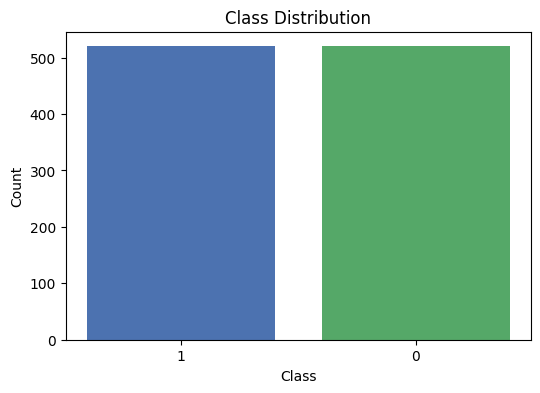

In [13]:
class_counts = df['class'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values, color=['#4C72B0', '#55A868'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 3.6: Individual Subject Count

In [14]:
df['subject_id'].nunique()

40

df['subject_id'].value_counts()

In [15]:
df['subject_id'].value_counts()

,count
subject_id,
1,26
2,26
3,26
4,26
5,26
6,26
7,26
8,26
9,26


### 3.8: Drop ID Column (not needed for Pattern Learning)

### I have readded the subject ID column to avoid data leakage as the model needs to learn by subject, and not memorise samples of a particular subject in training and test.

In [16]:
# df = df.drop(columns=["subject_id"])
df.head()

,subject_id,jitter_local,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,shimmer_local,shimmer_db,shimmer_apq3,shimmer_apq5,...,max_pitch,num_pulses,num_periods,mean_period,sd_period,unvoiced_frames,num_voice_breaks,degree_voice_breaks,UPDRS,class
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,...,187.576,160,159,0.006065,0.000416,0.000,0,0.000,23,1
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,...,234.505,170,169,0.005181,0.000403,2.247,0,0.000,23,1
2,1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,...,211.442,1431,1427,0.006071,0.000474,10.656,1,0.178,23,1
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,...,220.230,94,92,0.004910,0.000320,0.000,0,0.000,23,1
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,...,225.162,117,114,0.004757,0.000380,18.182,1,13.318,23,1


## Data Quality Assessment

### 3.9: Check for Missing Values

In [17]:
df.isnull().sum()

,0
subject_id,0
jitter_local,0
jitter_abs,0
jitter_rap,0
jitter_ppq5,0
jitter_ddp,0
shimmer_local,0
shimmer_db,0
shimmer_apq3,0
shimmer_apq5,0


### 3.10: Visualise to spot Outliers (using Matplotlib and Seaborn).

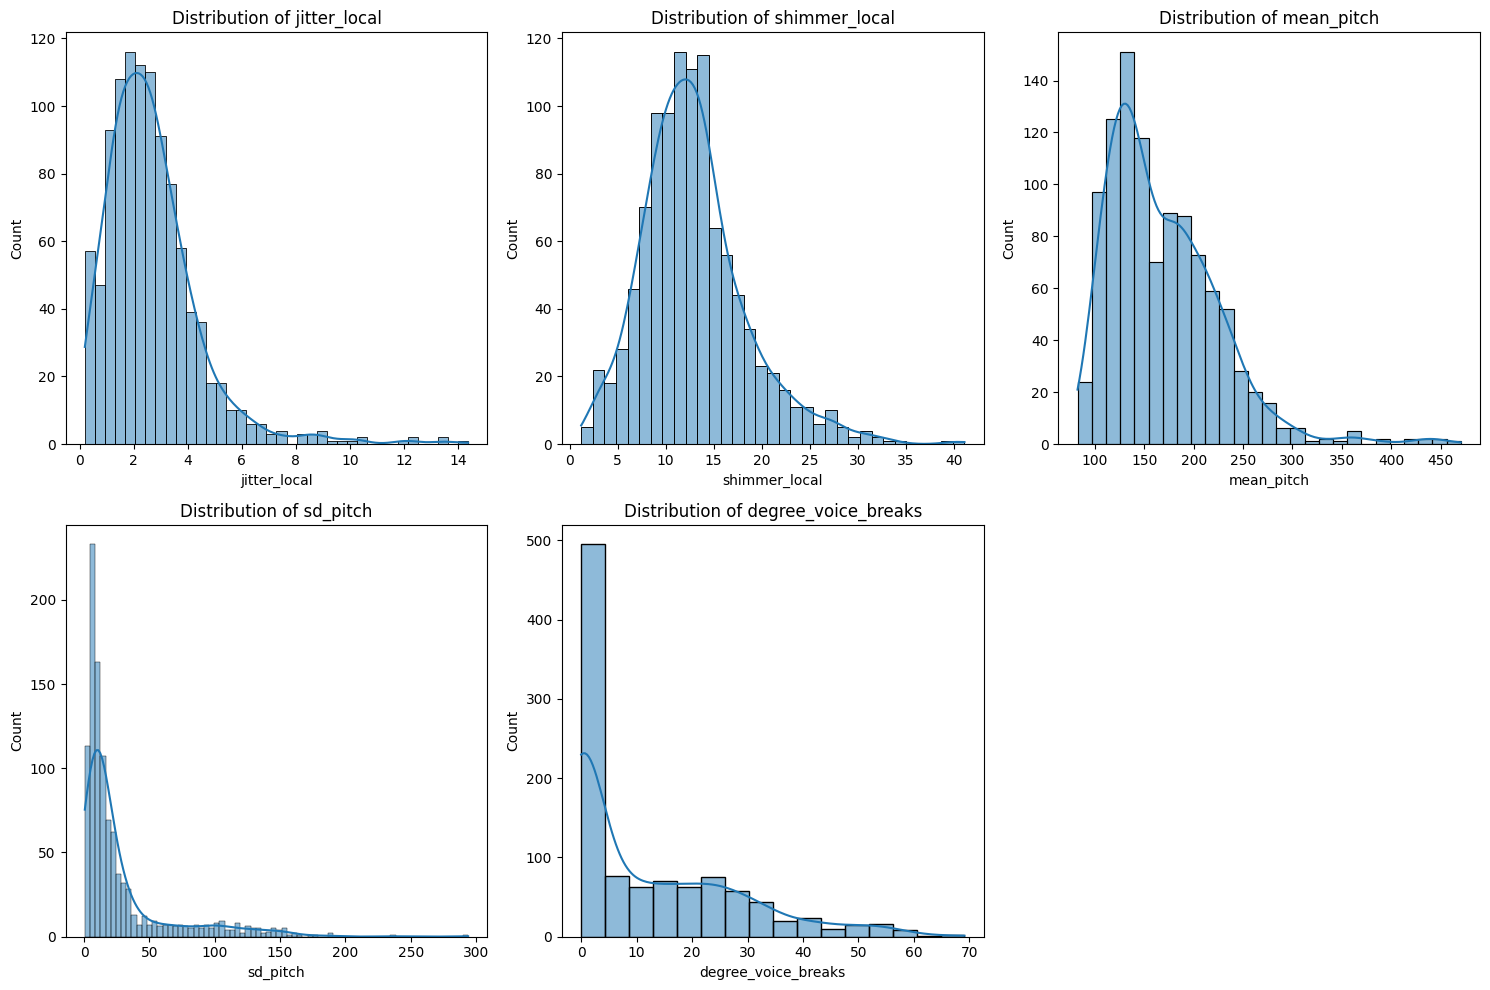

In [18]:
plt.figure(figsize=(15, 10))

columns_to_plot = ["jitter_local", "shimmer_local", "mean_pitch", "sd_pitch", "degree_voice_breaks"]

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### 3.11: Z score test to spot outliers with scipy.stats

Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html

In [19]:
z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))

outliers = (z_scores > 3).any(axis=1)

outlier_count = outliers.sum()
outlier_count

np.int64(177)

### 3.12: IQR test to spot outliers with Numpy

Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html

In [20]:
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

iqr_outliers = ((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) | (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)
iqr_count = iqr_outliers.sum()

iqr_count

np.int64(415)

### 3.13: Isolation Forest test to spot outliers with sklearn

Source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html

In [21]:
iso = IsolationForest(contamination='auto', random_state=42)
preds = iso.fit_predict(df.select_dtypes(include=np.number))

iso_count = (preds == -1).sum()
iso_count

np.int64(131)

### 3.14: Visual comparison of Z-Score, IQR and Isolation Forest

Source: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html

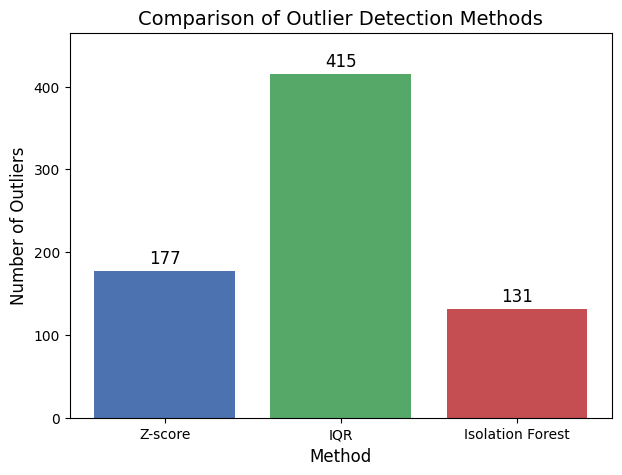

In [22]:
z_count = 177
iqr_count = 415
iso_count = 131

methods = ['Z-score', 'IQR', 'Isolation Forest']
counts = [z_count, iqr_count, iso_count]

plt.figure(figsize=(7,5))
bars = plt.bar(methods, counts, color=['#4C72B0', '#55A868', '#C44E52'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             str(height), ha='center', va='bottom', fontsize=12)

plt.title("Comparison of Outlier Detection Methods", fontsize=14)
plt.ylabel("Number of Outliers", fontsize=12)
plt.xlabel("Method", fontsize=12)
plt.ylim(0, max(counts) + 50)
plt.show()

# 4. Preprocess Assesment with Domain-Informed Data Validation (Clinical Plausibility Checks)

- [x] 4.1: Jitter clinical threshold checks (with visualisation)
- [x] 4.2: Shimmer clinical threshold checks (with visualisation)
- [x] 4.3: HNR plausibility checks (with visualisation)
- [x] 4.4: F0 (pitch) physiological range checks (with visualisation)
- [x] 4.5: Identify impossible or contradictory values
- [x] 4.6: Cross-feature consistency checks (with visualisation)
- [x] 4.7: Overlay clinical thresholds on histograms


## Sources Guide for clinical reference and thresholds:

https://link.springer.com/chapter/10.1007/978-981-13-0617-4_67

https://speechprocessingbook.aalto.fi/Representations/Jitter_and_shimmer.html

https://blog.phonalyze.com/hnr-in-voice-assessment-using-phonalyze/

Sources for coding and syntax:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

---


### 4.1 Jitter Clinical Threshold Checks

Typical jitter in healthy speech is typically < 1%.
Parkinson's patients often show 1-3% or higher.


In [23]:
jitter_cols = ['jitter_local', "jitter_abs", 'jitter_rap', 'jitter_ppq5', 'jitter_ddp']

print("=== 4.1 Jitter Clinical Classification ===")

def classify_jitter(value):
    if value < 1:
        return "Healthy range"
    elif value < 2:
        return "Mild PD range"
    elif value < 3:
        return "Moderate PD range"
    else:
        return "Severe PD range"

for col in ["jitter_local", "jitter_abs", "jitter_rap", "jitter_ppq5", "jitter_ddp"]:
    # Ensure the column exists before applying the function
    if col in df.columns:
        df[col + "_category"] = df[col].apply(classify_jitter)
        counts = df[col + "_category"].value_counts()
        print(f"\n{col} classification:")
        print(counts)
    else:
        print(f"Column {col} not found in DataFrame. Skipping classification.")

=== 4.1 Jitter Clinical Classification ===

jitter_local classification:
jitter_local_category
Severe PD range      343
Moderate PD range    293
Mild PD range        291
Healthy range        113
Name: count, dtype: int64

jitter_abs classification:
jitter_abs_category
Healthy range    1040
Name: count, dtype: int64

jitter_rap classification:
jitter_rap_category
Healthy range        495
Mild PD range        397
Moderate PD range    102
Severe PD range       46
Name: count, dtype: int64

jitter_ppq5 classification:
jitter_ppq5_category
Healthy range        457
Mild PD range        408
Moderate PD range    121
Severe PD range       54
Name: count, dtype: int64

jitter_ddp classification:
jitter_ddp_category
Severe PD range      545
Moderate PD range    205
Mild PD range        189
Healthy range        101
Name: count, dtype: int64


Visualising 4.1 results on a stacked bar chart.

<Figure size 1200x600 with 0 Axes>

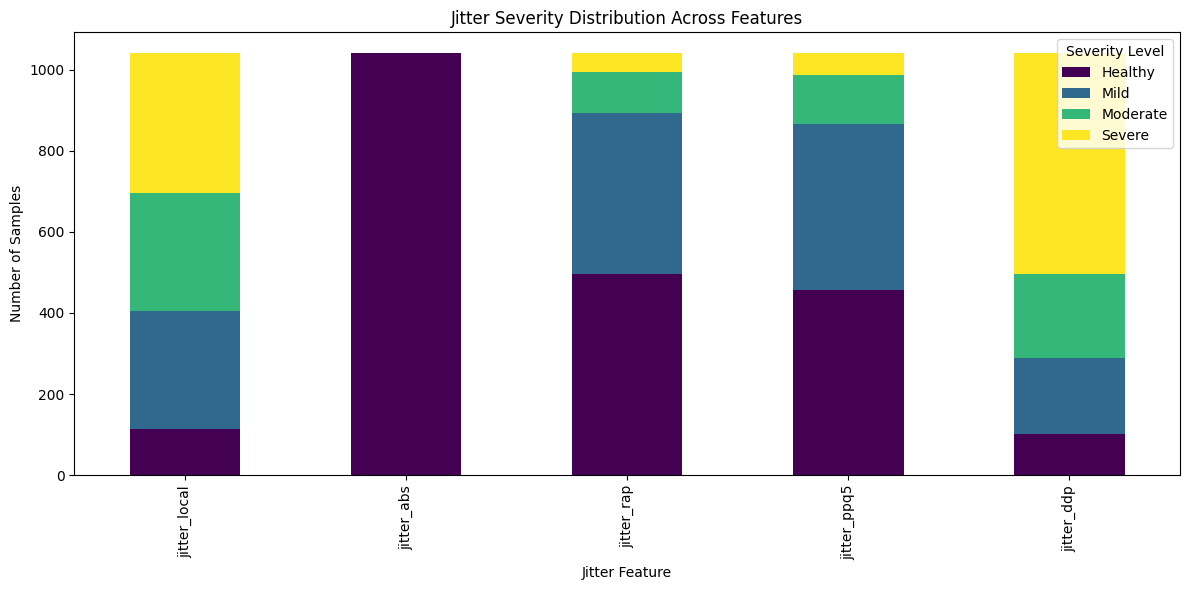

In [24]:
jitter_data = {
    "jitter_local": {
        "Healthy": 113,
        "Mild": 291,
        "Moderate": 293,
        "Severe": 343
    },
    "jitter_abs": {
        "Healthy": 1040,
        "Mild": 0,
        "Moderate": 0,
        "Severe": 0
    },
    "jitter_rap": {
        "Healthy": 495,
        "Mild": 397,
        "Moderate": 102,
        "Severe": 46
    },
    "jitter_ppq5": {
        "Healthy": 457,
        "Mild": 408,
        "Moderate": 121,
        "Severe": 54
    },
    "jitter_ddp": {
        "Healthy": 101,
        "Mild": 189,
        "Moderate": 205,
        "Severe": 545
    }
}

df_jitter = pd.DataFrame(jitter_data).T

plt.figure(figsize=(12, 6))
df_jitter[["Healthy", "Mild", "Moderate", "Severe"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="viridis"
)

plt.title("Jitter Severity Distribution Across Features")
plt.xlabel("Jitter Feature")
plt.ylabel("Number of Samples")
plt.legend(title="Severity Level")
plt.tight_layout()
plt.show()

### 4.2 Shimmer Clinical Threshold Checks

Healthy shimmer < 3-4%
PD shimmer often 5-10%+


In [25]:
print("=== 4.2 Shimmer Clinical Classification ===")

def classify_shimmer(value):
    if value < 4:
        return "Healthy range"
    elif value < 6:
        return "Mild PD range"
    elif value < 10:
        return "Moderate PD range"
    else:
        return "Severe PD range"

shimmer_cols = ["shimmer_local", "shimmer_db", "shimmer_apq3",
                "shimmer_apq5", "shimmer_apq11", "shimmer_dda"]

for col in shimmer_cols:
    # Ensure the column exists before applying the function
    if col in df.columns:
        df[col + "_category"] = df[col].apply(classify_shimmer)
        counts = df[col + "_category"].value_counts()
        print(f"\n{col} classification:")
        print(counts)
    else:
        print(f"Column {col} not found in DataFrame. Skipping classification.")

=== 4.2 Shimmer Clinical Classification ===

shimmer_local classification:
shimmer_local_category
Severe PD range      728
Moderate PD range    239
Mild PD range         40
Healthy range         33
Name: count, dtype: int64

shimmer_db classification:
shimmer_db_category
Healthy range    1040
Name: count, dtype: int64

shimmer_apq3 classification:
shimmer_apq3_category
Mild PD range        362
Healthy range        306
Moderate PD range    284
Severe PD range       88
Name: count, dtype: int64

shimmer_apq5 classification:
shimmer_apq5_category
Moderate PD range    423
Mild PD range        247
Severe PD range      235
Healthy range        135
Name: count, dtype: int64

shimmer_apq11 classification:
shimmer_apq11_category
Severe PD range      637
Moderate PD range    274
Mild PD range         76
Healthy range         53
Name: count, dtype: int64

shimmer_dda classification:
shimmer_dda_category
Severe PD range      848
Moderate PD range    143
Mild PD range         34
Healthy range      

Visualising 4.2 results on a stacked bar chart

<Figure size 1200x600 with 0 Axes>

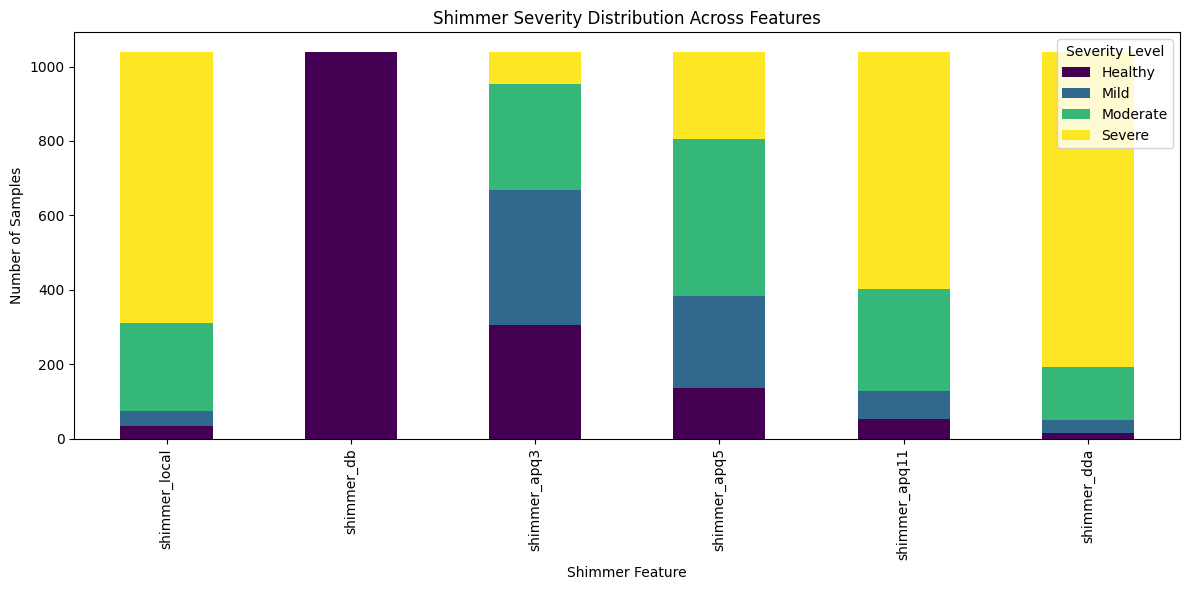

In [26]:
shimmer_data = {
    "shimmer_local": {
        "Healthy": 33,
        "Mild": 40,
        "Moderate": 239,
        "Severe": 728
    },
    "shimmer_db": {
        "Healthy": 1040,
        "Mild": 0,
        "Moderate": 0,
        "Severe": 0
    },
    "shimmer_apq3": {
        "Healthy": 306,
        "Mild": 362,
        "Moderate": 284,
        "Severe": 88
    },
    "shimmer_apq5": {
        "Healthy": 135,
        "Mild": 247,
        "Moderate": 423,
        "Severe": 235
    },
    "shimmer_apq11": {
        "Healthy": 53,
        "Mild": 76,
        "Moderate": 274,
        "Severe": 637
    },
    "shimmer_dda": {
        "Healthy": 15,
        "Mild": 34,
        "Moderate": 143,
        "Severe": 848
    }
}

df_shimmer = pd.DataFrame(shimmer_data).T

plt.figure(figsize=(12, 6))
df_shimmer[["Healthy", "Mild", "Moderate", "Severe"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="viridis"
)

plt.title("Shimmer Severity Distribution Across Features")
plt.xlabel("Shimmer Feature")
plt.ylabel("Number of Samples")
plt.legend(title="Severity Level")
plt.tight_layout()
plt.show()

### 4.3 HNR (HTN) Plausibility Checks

Healthy HNR > 20 dB
PD HNR often 10-15 dB
Values < 0 dB are physiologically impossible.


Threshold Source: Boersma, P., & Weenink, D. Praat: Doing phonetics by computer. University of Amsterdam.


In [27]:
print("=== 4.3 HNR Clinical Classification ===")

def classify_hnr(value):
    if value > 20:
        return "Healthy range"
    elif value > 15:
        return "Mild PD range"
    elif value > 10:
        return "Moderate PD range"
    else:
        return "Severe PD range"

# Ensure the column exists before applying the function
if "HTN" in df.columns:
    df["HTN_category"] = df["HTN"].apply(classify_hnr)
    print(df["HTN_category"].value_counts())
else:
    print("Column HTN not found in DataFrame. Skipping classification.")

=== 4.3 HNR Clinical Classification ===
HTN_category
Severe PD range      563
Moderate PD range    368
Mild PD range         79
Healthy range         30
Name: count, dtype: int64


Visualising 4.3 results on a bar chart

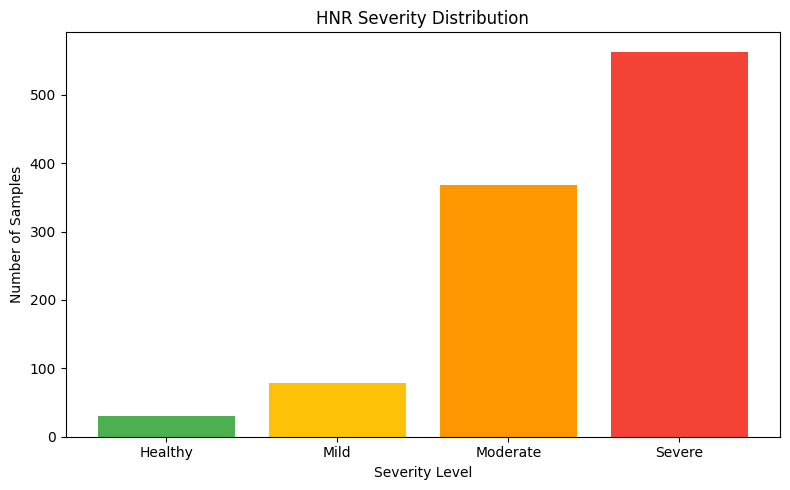

In [28]:
hnr_counts = {
    "Healthy": 30,
    "Mild": 79,
    "Moderate": 368,
    "Severe": 563
}

plt.figure(figsize=(8, 5))
plt.bar(hnr_counts.keys(), hnr_counts.values(), color=["#4CAF50", "#FFC107", "#FF9800", "#F44336"])
plt.title("HNR Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

### 4.4 Pitch (F0) Physiological Range Checks

Typical pitch ranges:
- Males: 85-180 Hz
- Females: 165-255 Hz
- Values < 50 or > 400 are implausible


Threshold source: Titze, I. R. (1994). Principles of Voice Production. Prentice Hall.


In [29]:
print("Median pitch < 50 Hz:", len(df[df["median_pitch"] < 50]))
print("Median pitch > 400 Hz:", len(df[df["median_pitch"] > 400]))

print("Mean pitch < 50 Hz:", len(df[df["mean_pitch"] < 50]))
print("Mean pitch > 400 Hz:", len(df[df["mean_pitch"] > 400]))

Median pitch < 50 Hz: 0
Median pitch > 400 Hz: 12
Mean pitch < 50 Hz: 0
Mean pitch > 400 Hz: 7


Visualising 4.4 results on a bar chart

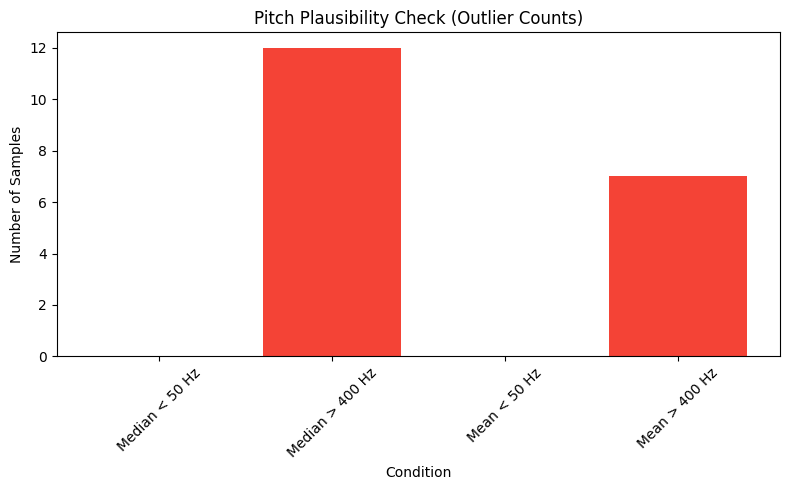

In [30]:
pitch_outliers = {
    "Median < 50 Hz": 0,
    "Median > 400 Hz": 12,
    "Mean < 50 Hz": 0,
    "Mean > 400 Hz": 7
}

plt.figure(figsize=(8, 5))
plt.bar(pitch_outliers.keys(), pitch_outliers.values(), color=["#4CAF50", "#F44336", "#4CAF50", "#F44336"])
plt.title("Pitch Plausibility Check (Outlier Counts)")
plt.xlabel("Condition")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.5 Impossible or Contradictory Values

Examples:
- num_pulses = 0 but pitch > 0
- mean_period = 0 but pulses > 0

In [31]:
impossible = df[
    ((df["num_pulses"] == 0) & (df["median_pitch"] > 0)) |
    ((df["mean_period"] == 0) & (df["num_pulses"] > 0))
]

print("Impossible or contradictory rows:", len(impossible))

Impossible or contradictory rows: 1


Tracing the impossible or contradictory rows.

In [32]:
contradictions = df[
    ((df["num_pulses"] == 0) & (df["median_pitch"] > 0)) |
    ((df["num_pulses"] == 0) & (df["mean_pitch"] > 0)) |
    ((df["num_periods"] == 0) & (df["mean_period"] > 0)) |
    ((df["unvoiced_frames"] == 100) & (df["median_pitch"] > 0))
]

contradictions

,subject_id,jitter_local,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,shimmer_local,shimmer_db,shimmer_apq3,shimmer_apq5,...,jitter_rap_category,jitter_ppq5_category,jitter_ddp_category,shimmer_local_category,shimmer_db_category,shimmer_apq3_category,shimmer_apq5_category,shimmer_apq11_category,shimmer_dda_category,HTN_category
114,5,2.7496,0.00025,1.23496,1.2752,3.70484,14.94524,1.36904,7.24684,9.55324,...,Mild PD range,Mild PD range,Severe PD range,Severe PD range,Healthy range,Moderate PD range,Moderate PD range,Severe PD range,Severe PD range,Severe PD range


In [33]:
df.loc[114, [
    "median_pitch", "mean_pitch",
    "min_pitch", "max_pitch",
    "num_pulses", "num_periods",
    "mean_period", "sd_period",
    "unvoiced_frames", "num_voice_breaks",
    "degree_voice_breaks"
]]

,114
median_pitch,109.126
mean_pitch,111.9164
min_pitch,96.88784
max_pitch,163.00548
num_pulses,0
num_periods,0
mean_period,0.009014
sd_period,0.000966
unvoiced_frames,85.0
num_voice_breaks,0


### 4.6 Cross-Feature Consistency Checks

High jitter to high shimmer
High shimmer to low HNR
Pitch SD to voice breaks



In [34]:
df[["jitter_local", "shimmer_local", "HTN"]].corr()

,jitter_local,shimmer_local,HTN
jitter_local,1.000000,0.498113,-0.626581
shimmer_local,0.498113,1.000000,-0.779693
HTN,-0.626581,-0.779693,1.000000


Visualising 4.6 results on a heat map

Source: https://seaborn.pydata.org/generated/seaborn.heatmap

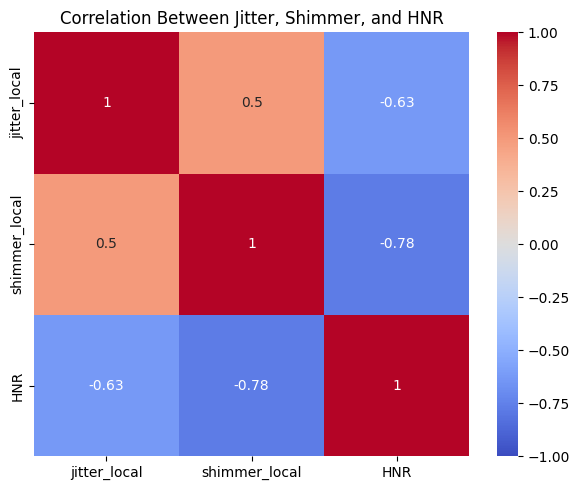

In [35]:
corr = pd.DataFrame({
    "jitter_local": [1.000000, 0.498113, -0.626581],
    "shimmer_local": [0.498113, 1.000000, -0.779693],
    "HNR": [-0.626581, -0.779693, 1.000000]
}, index=["jitter_local", "shimmer_local", "HNR"])

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Jitter, Shimmer, and HNR")
plt.tight_layout()
plt.show()

### 4.7 Overlay Clinical Thresholds on Histograms

Example: jitter_local


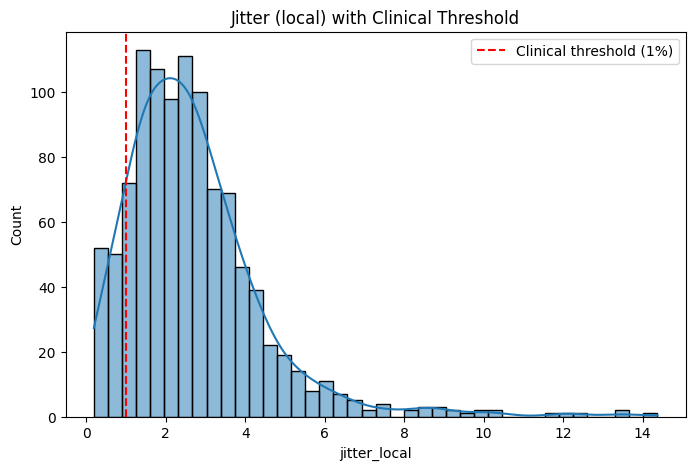

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df["jitter_local"], bins=40, kde=True)
plt.axvline(1, color='red', linestyle='--', label='Clinical threshold (1%)')
plt.legend()
plt.title("Jitter (local) with Clinical Threshold")
plt.show()

Example: shimmer_local

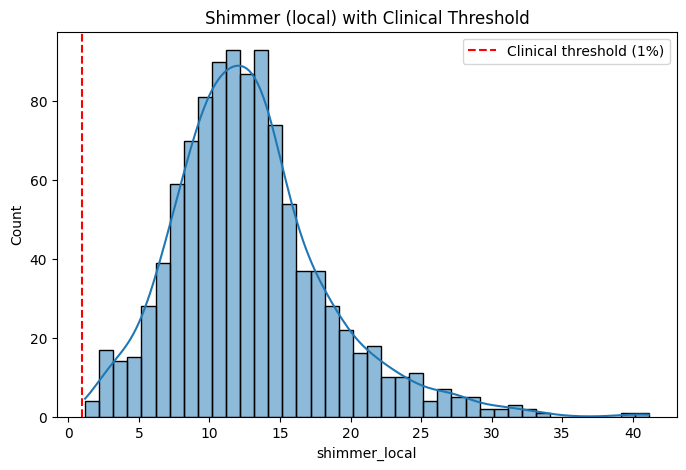

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["shimmer_local"], bins=40, kde=True)
plt.axvline(1, color='red', linestyle='--', label='Clinical threshold (1%)')
plt.legend()
plt.title("Shimmer (local) with Clinical Threshold")
plt.show()

Example: HTN

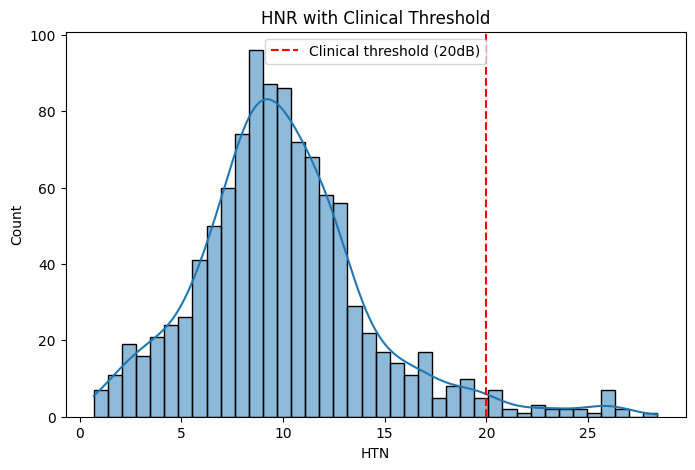

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df["HTN"], bins=40, kde=True)
plt.axvline(20, color='red', linestyle='--', label='Clinical threshold (20dB)') # Corrected threshold
plt.legend()
plt.title("HNR with Clinical Threshold")
plt.show()

# 5. Correlation & Feature Relationships (EDA 2: Relationships & Insights)

- [x] 5.1: Correlation matrix
- [x] 5.2: Heatmap
- [x] 5.3: Pearson/Spearman correlations
- [x] 5.4: Scatterplots (jitter vs shimmer)
- [x] 5.5: Pairplot

---

### 5.1: Correlation matrix


Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

In [39]:
corr_matrix = df.corr(method="pearson", numeric_only=True)
corr_matrix

,subject_id,jitter_local,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,shimmer_local,shimmer_db,shimmer_apq3,shimmer_apq5,...,max_pitch,num_pulses,num_periods,mean_period,sd_period,unvoiced_frames,num_voice_breaks,degree_voice_breaks,UPDRS,class
subject_id,1.000000,-0.040571,-0.151738,-0.060465,-0.066361,-0.060465,-0.008484,-0.026167,0.007070,0.022538,...,0.154136,-0.021695,-0.027577,-0.186040,0.046831,0.170824,0.074009,0.125489,-0.602401,-0.866296
jitter_local,-0.040571,1.000000,0.791693,0.955695,0.906154,0.955694,0.498113,0.490327,0.434851,0.352898,...,0.318758,-0.254562,-0.269148,-0.151866,0.375978,0.464826,0.251289,0.312365,0.140326,0.097552
jitter_abs,-0.151738,0.791693,1.000000,0.724970,0.691153,0.724970,0.413634,0.424462,0.350243,0.274999,...,-0.036702,-0.340791,-0.345273,0.357982,0.370202,0.388623,0.187589,0.245861,0.177695,0.166999
jitter_rap,-0.060465,0.955695,0.724970,1.000000,0.915695,1.000000,0.499045,0.484393,0.440373,0.345303,...,0.296577,-0.195857,-0.208542,-0.179820,0.265801,0.392331,0.200454,0.262853,0.165626,0.111144
jitter_ppq5,-0.066361,0.906154,0.691153,0.915695,1.000000,0.915695,0.475906,0.461335,0.419708,0.316597,...,0.267908,-0.186628,-0.197998,-0.163408,0.251063,0.364609,0.184184,0.219275,0.152835,0.110934
jitter_ddp,-0.060465,0.955694,0.724970,1.000000,0.915695,1.000000,0.499047,0.484395,0.440374,0.345306,...,0.296586,-0.195850,-0.208536,-0.179809,0.265812,0.392328,0.200468,0.262860,0.165632,0.111138
shimmer_local,-0.008484,0.498113,0.413634,0.499045,0.475906,0.499047,1.000000,0.963551,0.882122,0.830953,...,0.223785,-0.255359,-0.269455,-0.017658,0.275186,0.441514,0.197883,0.277248,0.080626,0.009062
shimmer_db,-0.026167,0.490327,0.424462,0.484393,0.461335,0.484395,0.963551,1.000000,0.817004,0.771766,...,0.222664,-0.287413,-0.301042,-0.010253,0.291130,0.430987,0.219295,0.295757,0.088111,0.027190
shimmer_apq3,0.007070,0.434851,0.350243,0.440373,0.419708,0.440374,0.882122,0.817004,1.000000,0.845950,...,0.193433,-0.172035,-0.185487,-0.036735,0.227394,0.377617,0.150580,0.231756,0.046692,-0.018156
shimmer_apq5,0.022538,0.352898,0.274999,0.345303,0.316597,0.345306,0.830953,0.771766,0.845950,1.000000,...,0.221337,-0.178726,-0.192401,-0.065328,0.245744,0.348894,0.168097,0.227661,0.038167,-0.022581


### 5.2: Heatmap

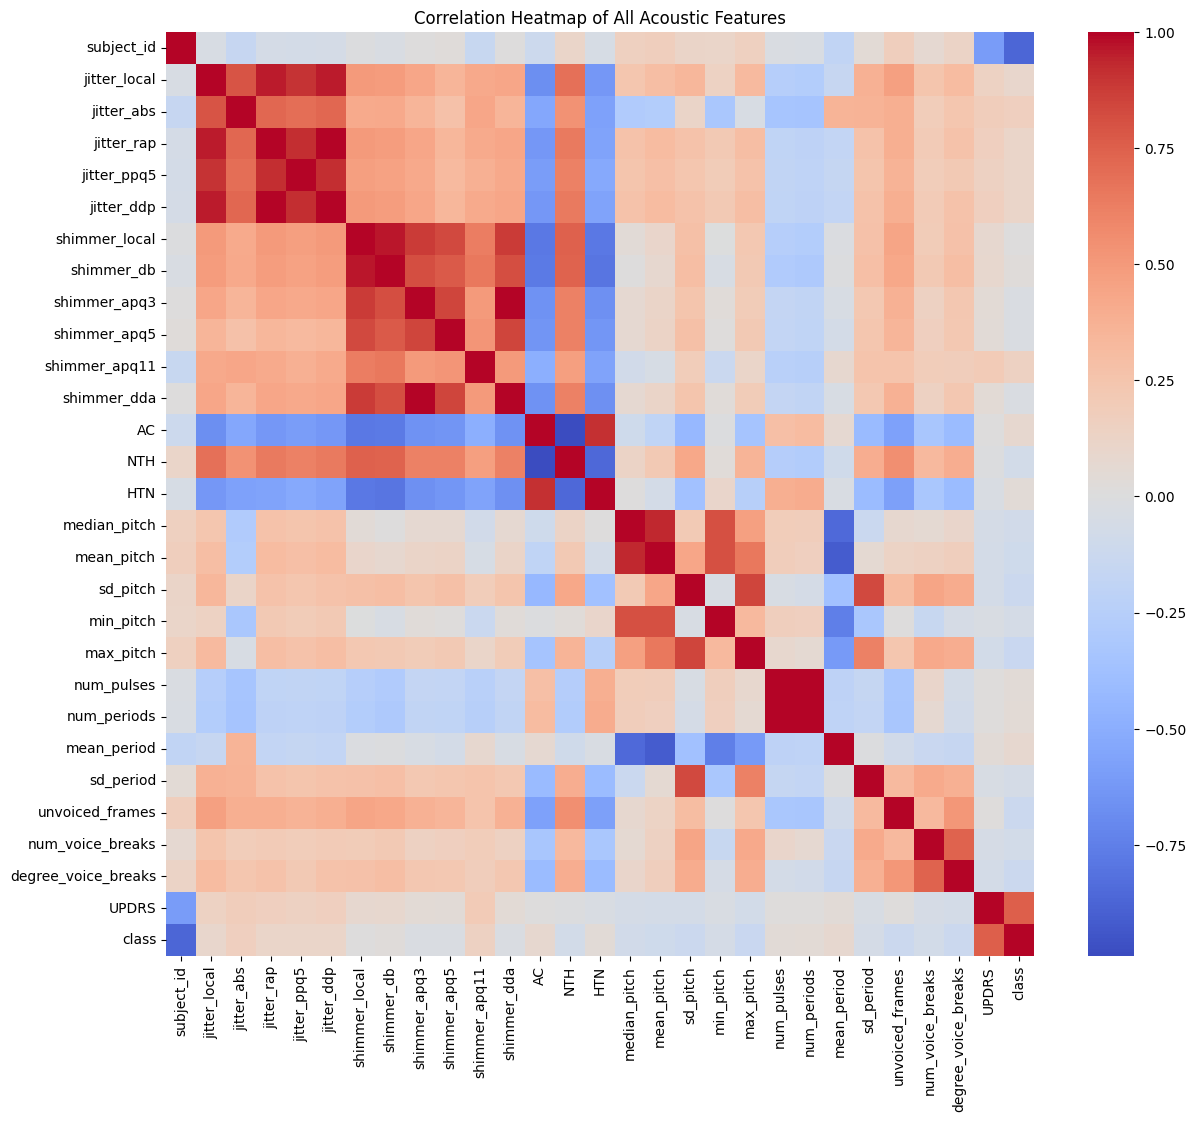

In [40]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of All Acoustic Features")
plt.show()

### Setup for Heatmaps

In [41]:
# 1. Define iqr function for aggregation
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# Ensure UPDRS and class are numeric before aggregation (already done in analysis, but for independence)
if 'UPDRS_bin' in df.columns: # Clean up any categorical columns that might interfere
    df = df.drop(columns=['UPDRS_bin'], errors='ignore')
for col_cat in ['jitter_local_category', 'jitter_abs_category', 'jitter_rap_category',
                'jitter_ppq5_category', 'jitter_ddp_category', 'shimmer_local_category',
                'shimmer_db_category', 'shimmer_apq3_category', 'shimmer_apq5_category',
                'shimmer_apq11_category', 'shimmer_dda_category', 'HTN_category']:
    if col_cat in df.columns:
        df = df.drop(columns=[col_cat], errors='ignore')

# 2. Create df_subject (Subject-Level Aggregation)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features_to_aggregate = [col for col in numeric_cols if col not in ['subject_id', 'UPDRS', 'class']]

agg_map = {feat: ['mean', 'median', 'std', iqr] for feat in features_to_aggregate}

df_subject = df.groupby('subject_id').agg({
    **agg_map,
    'UPDRS': 'first',
    'class': 'first'
})

df_subject.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_subject.columns.values]
df_subject = df_subject.reset_index()

# 3. Define ABBREV (original feature abbreviations)
ABBREV = {
    'jitter_local':           'Jit.Loc',
    'jitter_abs':             'Jit.Abs',
    'jitter_rap':             'Jit.RAP',
    'jitter_ppq5':            'Jit.PPQ5',
    'jitter_ddp':             'Jit.DDP',
    'shimmer_local':          'Shim.Loc',
    'shimmer_db':             'Shim.dB',
    'shimmer_apq3':           'Shim.APQ3',
    'shimmer_apq5':           'Shim.APQ5',
    'shimmer_apq11':          'Shim.APQ11',
    'shimmer_dda':            'Shim.DDA',
    'AC':                     'AC',
    'HTN':                    'HNR',
    'NTH':                    'NTH',
    'median_pitch':'Med.F0','mean_pitch':'Mean.F0','sd_pitch':'SD.F0',
    'min_pitch':'Min.F0','max_pitch':'Max.F0',
    'num_pulses':'N.Pls','num_periods':'N.Per','mean_period':'M.Per','sd_period':'SD.Per',
    'unvoiced_frames':'Unv.Fr','num_voice_breaks':'N.VB','degree_voice_breaks':'Deg.VB',
}

# 4. Define feature_cols (all aggregated features)
feature_cols = [col for col in df_subject.columns if col not in ['subject_id', 'UPDRS_first', 'class_first']]

# 5. Dynamically create ABBREV_AGG for aggregated features
ABBREV_AGG = {}
for original_feature, abbrev_name in ABBREV.items():
    ABBREV_AGG[f'{original_feature}_mean'] = f'{abbrev_name}.Mean'
    ABBREV_AGG[f'{original_feature}_median'] = f'{abbrev_name}.Med'
    ABBREV_AGG[f'{original_feature}_std'] = f'{abbrev_name}.Std'
    ABBREV_AGG[f'{original_feature}_iqr'] = f'{abbrev_name}.IQR'

# Add any remaining columns from feature_cols that weren't explicitly covered by ABBREV
for col in feature_cols:
    if col not in ABBREV_AGG:
        base_name = col.split('_')[0]
        agg_type = col.split('_')[-1]
        if base_name in ABBREV:
            ABBREV_AGG[col] = f'{ABBREV[base_name]}.{agg_type.capitalize()}'
        else:
            ABBREV_AGG[col] = col # Fallback to original name if no abbreviation

# 6. Prepare data for RFE and Scaling
X_gkf = df_subject.drop(columns=['subject_id', 'UPDRS_first', 'class_first'])
y_gkf = df_subject['class_first']
groups = df_subject['subject_id'] # Used for GroupKFold, but only its values are needed here

scaler = StandardScaler()
X_gkf_scaled = scaler.fit_transform(X_gkf)

# 7. Recreate selector (from RFE) and X_filtered using optimal parameters
# Optimal Settings: {'C': 44.97022068461718, 'gamma': 0.008061483866384214, 'n_features_to_select': 16}
svc_for_rfe_optimal = SVC(kernel='linear', C=44.97, random_state=42) # Using linear kernel as in the RFE step of original notebook
selector = RFE(estimator=svc_for_rfe_optimal, n_features_to_select=16, step=5)
selector.fit(X_gkf_scaled, y_gkf) # Fit the selector to get feature support
X_filtered = selector.transform(X_gkf_scaled) # Transform X_gkf_scaled

# 8. Define mapping for clinical names (from jqBoBvjLOyMW)
mapping = {
    'x21': 'shimmer_apq11_median', 'x27': 'shimmer_apq3_median',
    'x30': 'shimmer_apq5_median', 'x37': 'jitter_local_mean',
    'x57': 'jitter_ppq5_median', 'x59': 'jitter_rap_median',
    'x65': 'mean_noise_to_harmonics_ratio', 'x67': 'median_noise_to_harmonics_ratio',
    'x74': 'degree_voice_breaks_IQR', 'x82': 'shimmer_local_db_IQR',
    'x87': 'shimmer_apq3_IQR', 'x90': 'shimmer_apq5_IQR',
    'x95': 'jitter_local_IQR', 'x96': 'jitter_local_absolute_IQR',
    'x99': 'jitter_ppq5_IQR', 'x101': 'degree_voice_breaks_median',
    # Add mappings for NTH, HTN, AC if they appear as x-names after RFE
    'x12': 'AC_mean', 'x13': 'NTH_mean', 'x14': 'HTN_mean' # Example, adjust indices if needed
}

x_names = selector.get_feature_names_out()
clinical_names = [mapping.get(name, name) for name in x_names]
X_filtered_df_full = pd.DataFrame(X_filtered, columns=clinical_names)

print("Consolidated setup for heatmaps complete. You can now run any of the heatmap cells below.")

Consolidated setup for heatmaps complete. You can now run any of the heatmap cells below.


In [42]:
# Corrected ABBREV map for original feature names (as in 'df')
ABBREV = {
    'jitter_local':           'Jit.Loc',
    'jitter_abs':             'Jit.Abs',
    'jitter_rap':             'Jit.RAP',
    'jitter_ppq5':            'Jit.PPQ5',
    'jitter_ddp':             'Jit.DDP',
    'shimmer_local':          'Shim.Loc',
    'shimmer_db':             'Shim.dB',
    'shimmer_apq3':           'Shim.APQ3',
    'shimmer_apq5':           'Shim.APQ5',
    'shimmer_apq11':          'Shim.APQ11',
    'shimmer_dda':            'Shim.DDA',
    'AC':                     'AC',
    'HTN':                    'HNR',
    # Removed 'NHR', 'RPDE', 'DFA', 'PPE' as they are not present in original `df` columns
    # or derived `df_subject` columns in this notebook's context.
}


In [43]:
feature_cols = [col for col in df_subject.columns if col not in ['subject_id', 'UPDRS_first', 'class_first']]


ABBREV_AGG = {}
for original_feature, abbrev_name in ABBREV.items():
    ABBREV_AGG[f'{original_feature}_mean'] = f'{abbrev_name}.Mean'
    ABBREV_AGG[f'{original_feature}_median'] = f'{abbrev_name}.Med'
    ABBREV_AGG[f'{original_feature}_std'] = f'{abbrev_name}.Std'
    ABBREV_AGG[f'{original_feature}_iqr'] = f'{abbrev_name}.IQR'

for col in feature_cols:
    if col not in ABBREV_AGG and col.split('_')[0] in ABBREV:
        prefix = '_'.join(col.split('_')[:-1])
        suffix = col.split('_')[-1]
        if prefix in ABBREV:
            ABBREV_AGG[col] = f'{ABBREV[prefix]}.{suffix.capitalize()}'
    elif col not in ABBREV_AGG:
        ABBREV_AGG[col] = col

ABBREV_AGG['NTH_mean'] = 'NTH.Mean'
ABBREV_AGG['NTH_median'] = 'NTH.Med'
ABBREV_AGG['NTH_std'] = 'NTH.Std'
ABBREV_AGG['NTH_iqr'] = 'NTH.IQR'

ABBREV_AGG['AC_mean'] = 'AC.Mean'
ABBREV_AGG['AC_median'] = 'AC.Med'
ABBREV_AGG['AC_std'] = 'AC.Std'
ABBREV_AGG['AC_iqr'] = 'AC.IQR'

ABBREV_AGG['HTN_mean'] = 'HNR.Mean'
ABBREV_AGG['HTN_median'] = 'HNR.Med'
ABBREV_AGG['HTN_std'] = 'HNR.Std'
ABBREV_AGG['HTN_iqr'] = 'HNR.IQR'

for col in feature_cols:
    if col not in ABBREV_AGG:
        ABBREV_AGG[col] = col

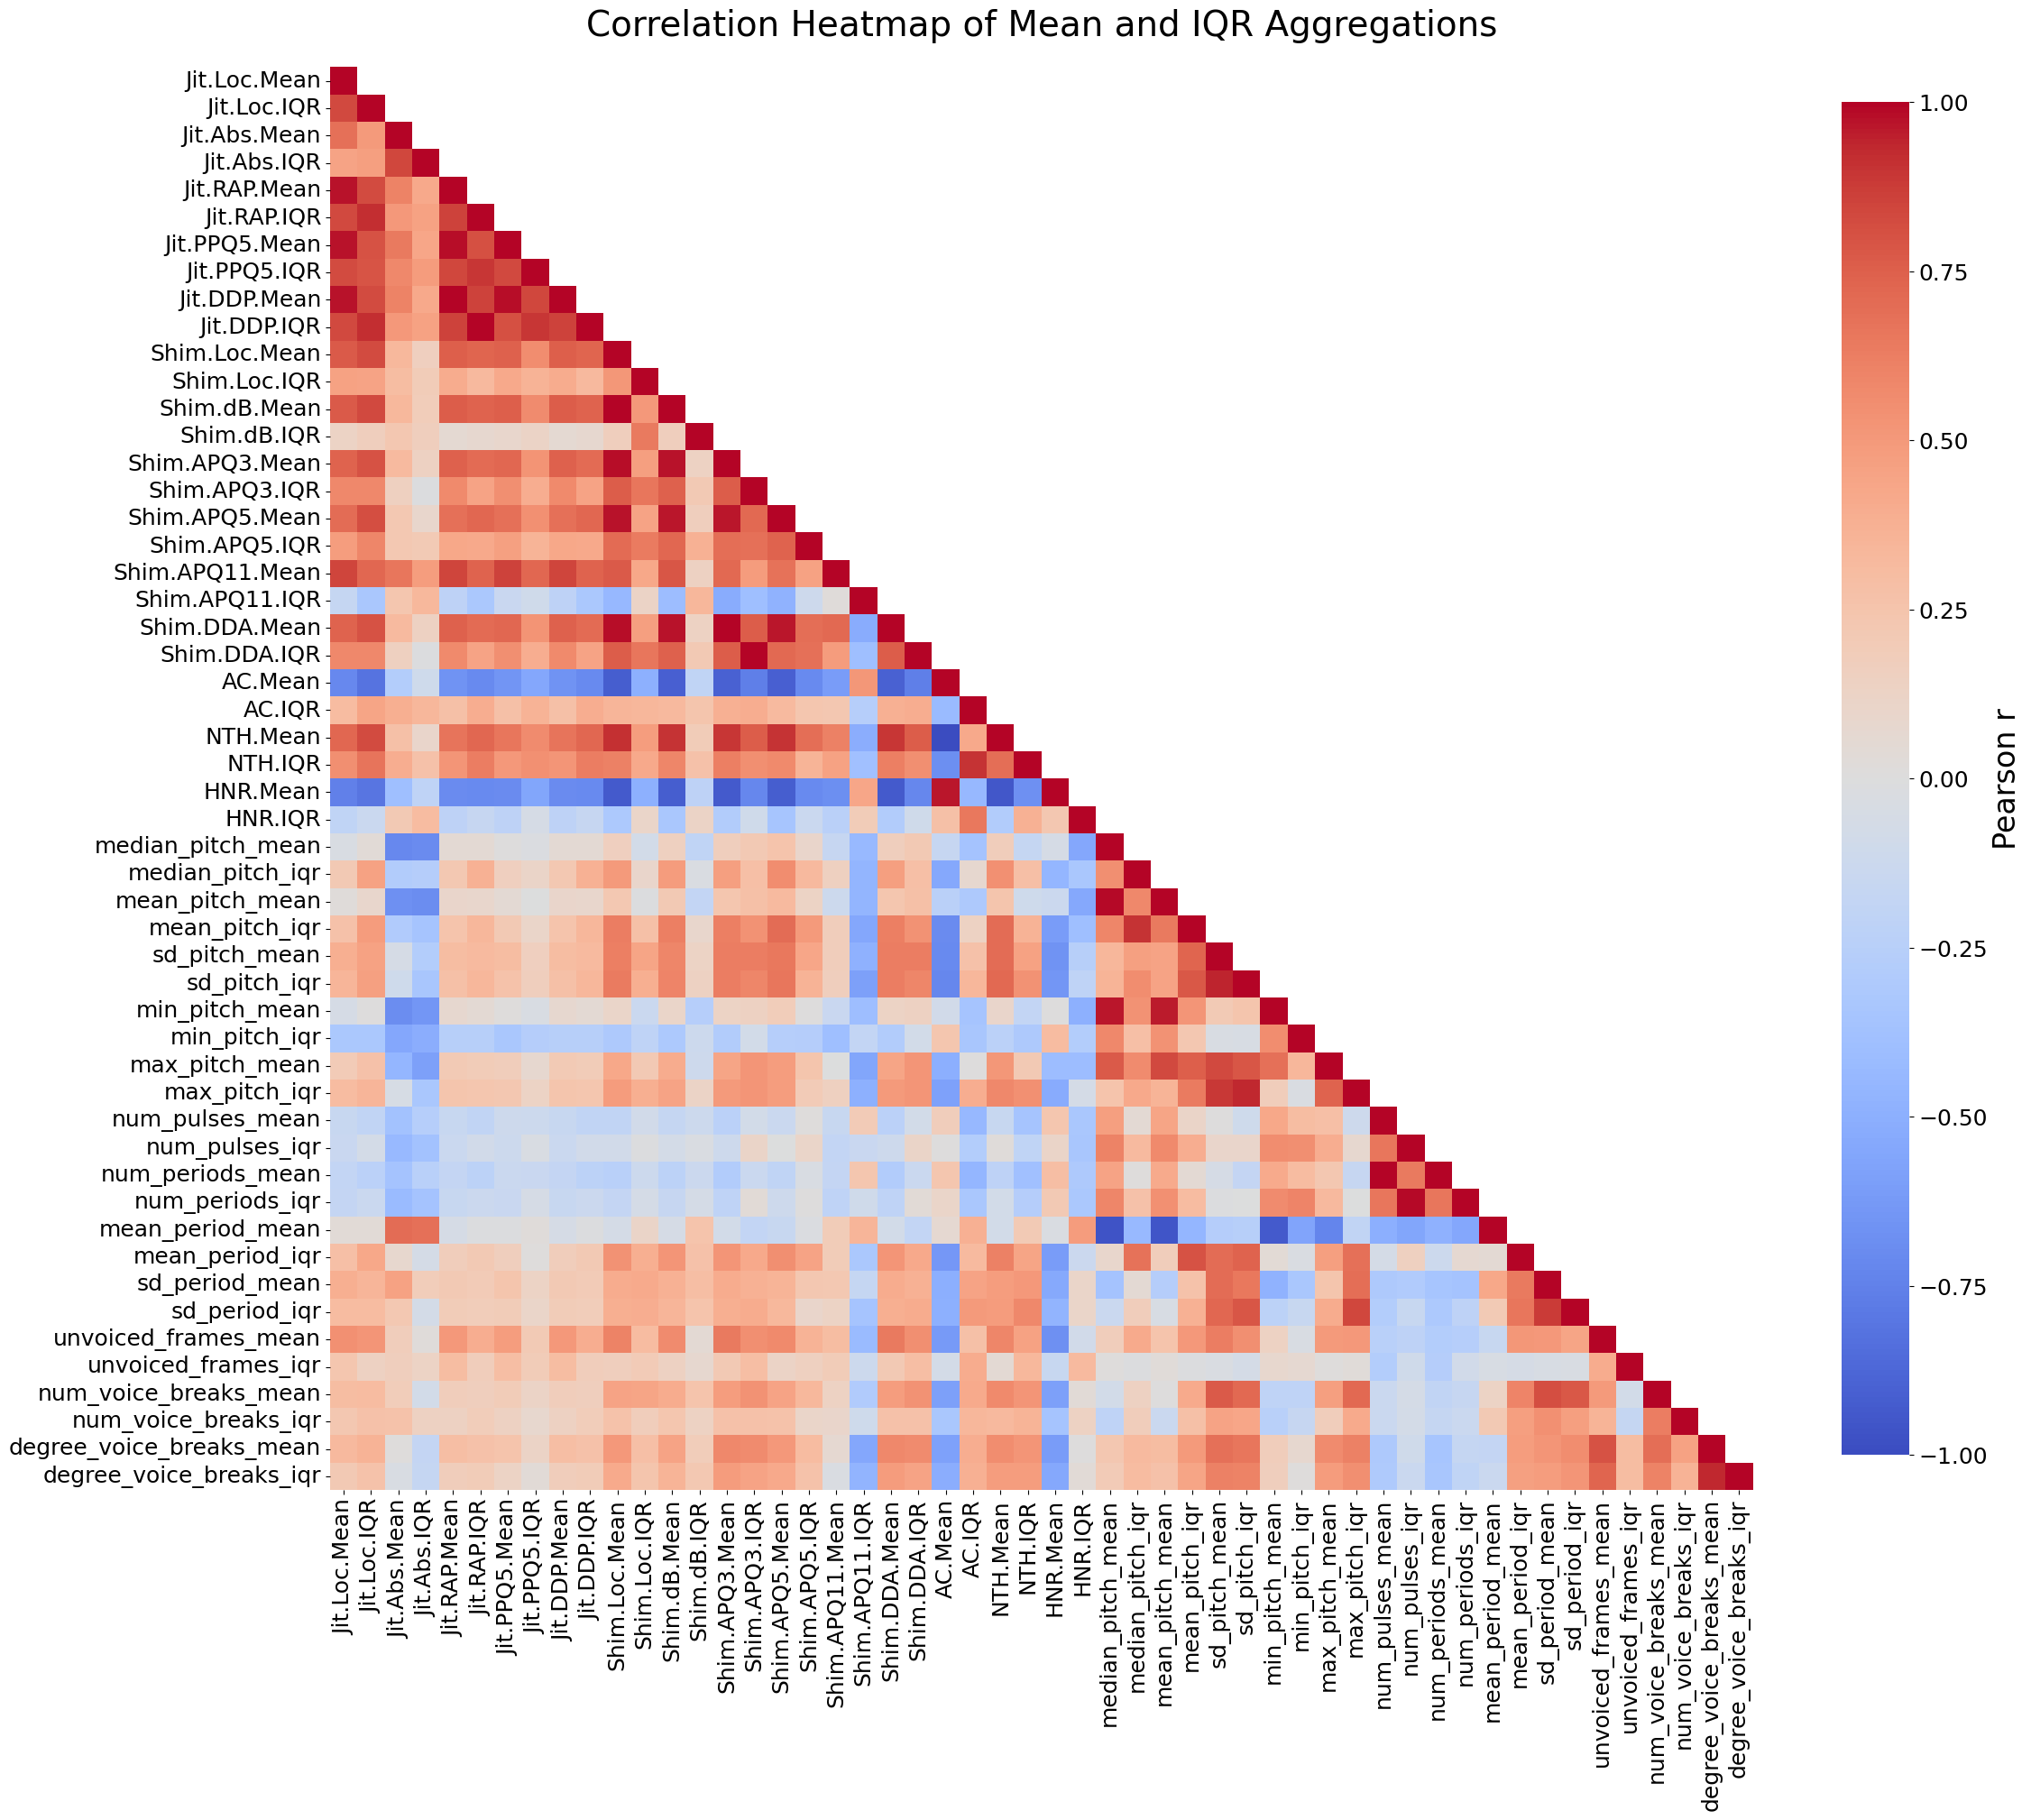

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# Filter feature_cols to include only '_mean' and '_iqr' aggregations
filtered_feature_cols = [col for col in feature_cols if col.endswith('_mean') or col.endswith('_iqr')]

# Compute correlation matrix on these filtered features
corr_filtered = df_subject[filtered_feature_cols].corr()

# Apply aggregated abbreviations to the filtered correlation matrix
# Only keep abbreviations for the filtered features
ABBREV_AGG_FILTERED = {k: v for k, v in ABBREV_AGG.items() if k in filtered_feature_cols}
corr_filtered_abbrev = corr_filtered.rename(index=ABBREV_AGG_FILTERED, columns=ABBREV_AGG_FILTERED)

# Mask upper triangle for cleaner look
mask_filtered = np.triu(np.ones_like(corr_filtered_abbrev, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(24, 22)) # Further adjust figure size for better readability

# Set global font size for better readability, this will be overridden by specific settings
plt.rcParams.update({'font.size': 24})

hm = sns.heatmap(
    corr_filtered_abbrev,
    mask=mask_filtered,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=False, # Re-enable annotations
    fmt='.2f',
    annot_kws={'size': 14}, # Increase annotation font size
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)

ax.tick_params(axis='x', labelsize=18, rotation=90) # Rotate x-axis labels and increase size
ax.tick_params(axis='y', labelsize=18, rotation=0) # Increase y-axis label size
ax.set_xlabel('')
ax.set_ylabel('')

cbar = hm.collections[0].colorbar
cbar.set_label('Pearson r', fontsize=24) # Increase colorbar label font size
cbar.ax.tick_params(labelsize=18) # Increase colorbar tick label size

plt.title('Correlation Heatmap of Mean and IQR Aggregations', fontsize=28, pad=25) # Update title and increase font size
plt.tight_layout()
# plt.savefig('fig_04_heatmap_mean_iqr.png', dpi=300, bbox_inches='tight')
plt.show()

Jitter    (5):   ['jitter_local_mean', 'jitter_abs_mean', 'jitter_rap_mean', 'jitter_ppq5_mean', 'jitter_ddp_mean']
Shimmer   (6):  ['shimmer_local_mean', 'shimmer_db_mean', 'shimmer_apq3_mean', 'shimmer_apq5_mean', 'shimmer_apq11_mean', 'shimmer_dda_mean']
Harmonics (3): ['AC_mean', 'NTH_mean', 'HTN_mean']


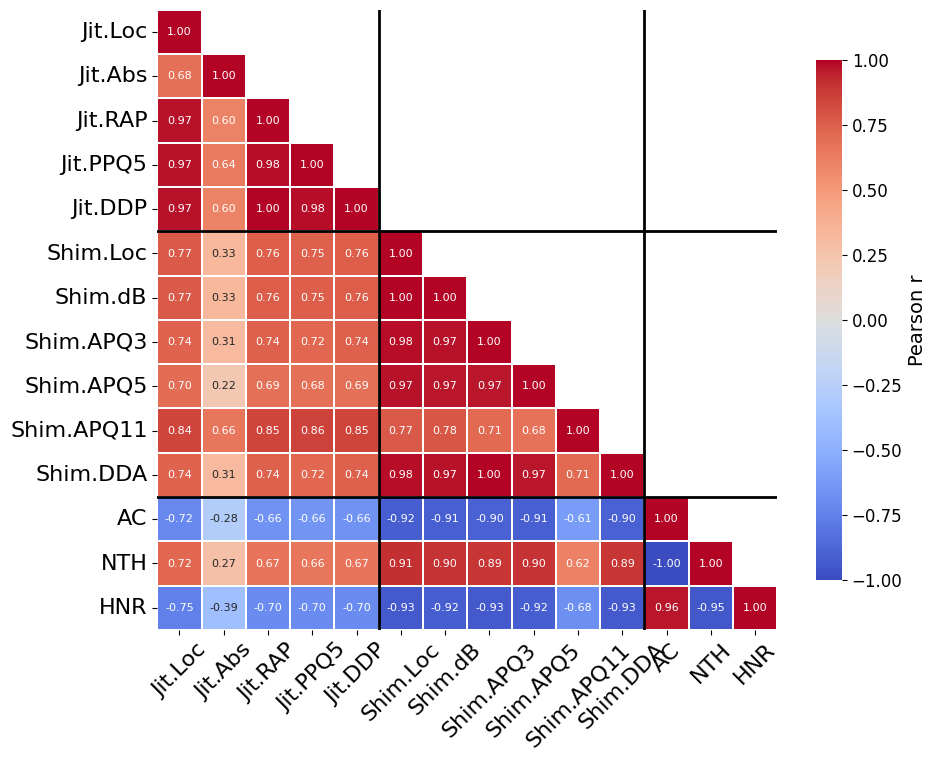

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Get all _mean columns ──────────────────────────────────────────────
feature_cols = [col for col in df_subject.columns
                if col not in ['subject_id', 'UPDRS_first', 'class_first']]
mean_cols = [col for col in feature_cols if col.endswith('_mean')]

# ── 2. Select the three families that prove the collinearity argument ─────
jitter_cols   = [c for c in mean_cols if 'jitter'  in c.lower()]
shimmer_cols  = [c for c in mean_cols if 'shimmer' in c.lower()]
harmonic_cols = [c for c in mean_cols
                 if c.split('_')[0].upper() in ['AC', 'NTH', 'HNR', 'HTN', 'NHR']]

# Verify before plotting
print(f"Jitter    ({len(jitter_cols)}):   {jitter_cols}")
print(f"Shimmer   ({len(shimmer_cols)}):  {shimmer_cols}")
print(f"Harmonics ({len(harmonic_cols)}): {harmonic_cols}")

subset_cols = jitter_cols + shimmer_cols + harmonic_cols

# ── 3. Abbreviation map ───────────────────────────────────────────────────
ABBREV = {
    # Jitter
    'jitter_local_mean':            'Jit.Loc',
    'jitter_local_absolute_mean':   'Jit.Abs',
    'jitter_abs_mean':              'Jit.Abs',    # alternate name
    'jitter_rap_mean':              'Jit.RAP',
    'jitter_ppq5_mean':             'Jit.PPQ5',
    'jitter_ddp_mean':              'Jit.DDP',
    # Shimmer
    'shimmer_local_mean':           'Shim.Loc',
    'shimmer_local_dB_mean':        'Shim.dB',
    'shimmer_db_mean':              'Shim.dB',    # alternate name
    'shimmer_apq3_mean':            'Shim.APQ3',
    'shimmer_apq5_mean':            'Shim.APQ5',
    'shimmer_apq11_mean':           'Shim.APQ11',
    'shimmer_dda_mean':             'Shim.DDA',
    # Harmonics
    'AC_mean':  'AC',   'ac_mean':  'AC',
    'NTH_mean': 'NTH',  'nth_mean': 'NTH',
    'NHR_mean': 'NHR',  'nhr_mean': 'NHR',
    'HNR_mean': 'HNR',  'hnr_mean': 'HNR',
    'HTN_mean': 'HNR',  'htn_mean': 'HNR',
}

# ── 4. Correlation matrix ─────────────────────────────────────────────────
corr        = df_subject[subset_cols].corr()
corr_abbrev = corr.rename(index=ABBREV, columns=ABBREV)

# ── 5. Lower-triangle mask ────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_abbrev, dtype=bool), k=1)

# ── 6. Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

hm = sns.heatmap(
    corr_abbrev,
    mask=mask,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,           # readable at this size (~14 features)
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.3,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    ax=ax
)

# ── 7. Dividing lines between the three family blocks ─────────────────────
n_jitter  = len(jitter_cols)
n_shimmer = len(shimmer_cols)

for pos in [n_jitter, n_jitter + n_shimmer]:
    ax.axhline(y=pos, color='black', linewidth=2)
    ax.axvline(x=pos, color='black', linewidth=2)

# ── 8. Labels ─────────────────────────────────────────────────────────────
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=16, rotation=45)
ax.tick_params(axis='y', labelsize=16, rotation=0)

cbar = hm.collections[0].colorbar
cbar.set_label('Pearson r', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# plt.savefig('fig_04_heatmap_final.png', dpi=300, bbox_inches='tight')
plt.show()

Jitter    (5):   ['jitter_local_mean', 'jitter_abs_mean', 'jitter_rap_mean', 'jitter_ppq5_mean', 'jitter_ddp_mean']
Shimmer   (6):  ['shimmer_local_mean', 'shimmer_db_mean', 'shimmer_apq3_mean', 'shimmer_apq5_mean', 'shimmer_apq11_mean', 'shimmer_dda_mean']
Harmonics (3): ['AC_mean', 'NTH_mean', 'HTN_mean']


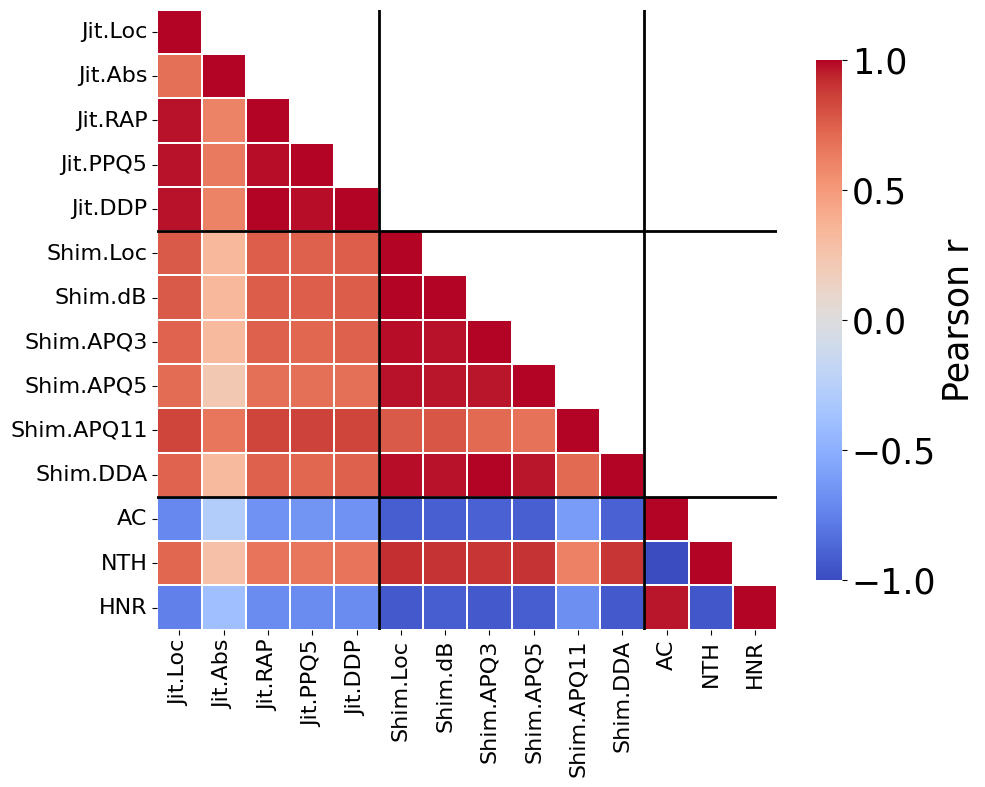

In [46]:
# 1. Get all _mean columns
feature_cols = [col for col in df_subject.columns
                if col not in ['subject_id', 'UPDRS_first', 'class_first']]
mean_cols = [col for col in feature_cols if col.endswith('_mean')]

# 2. Selecting the three families that prove the collinearity argument
jitter_cols   = [c for c in mean_cols if 'jitter'  in c.lower()]
shimmer_cols  = [c for c in mean_cols if 'shimmer' in c.lower()]
harmonic_cols = [c for c in mean_cols
                 if c.split('_')[0].upper() in ['AC', 'NTH', 'HNR', 'HTN', 'NHR']]

# Verify before plotting
print(f"Jitter    ({len(jitter_cols)}):   {jitter_cols}")
print(f"Shimmer   ({len(shimmer_cols)}):  {shimmer_cols}")
print(f"Harmonics ({len(harmonic_cols)}): {harmonic_cols}")

subset_cols = jitter_cols + shimmer_cols + harmonic_cols

# ── 3. Abbreviation map ───────────────────────────────────────────────────
ABBREV = {
    # Jitter
    'jitter_local_mean':            'Jit.Loc',
    'jitter_local_absolute_mean':   'Jit.Abs',
    'jitter_abs_mean':              'Jit.Abs',
    'jitter_rap_mean':              'Jit.RAP',
    'jitter_ppq5_mean':             'Jit.PPQ5',
    'jitter_ddp_mean':              'Jit.DDP',
    # Shimmer
    'shimmer_local_mean':           'Shim.Loc',
    'shimmer_local_dB_mean':        'Shim.dB',
    'shimmer_db_mean':              'Shim.dB',
    'shimmer_apq3_mean':            'Shim.APQ3',
    'shimmer_apq5_mean':            'Shim.APQ5',
    'shimmer_apq11_mean':           'Shim.APQ11',
    'shimmer_dda_mean':             'Shim.DDA',
    # Harmonics
    'AC_mean':  'AC',   'ac_mean':  'AC',
    'NTH_mean': 'NTH',  'nth_mean': 'NTH',
    'NHR_mean': 'NHR',  'nhr_mean': 'NHR',
    'HNR_mean': 'HNR',  'hnr_mean': 'HNR',
    'HTN_mean': 'HNR',  'htn_mean': 'HNR',
}

# ── 4. Correlation matrix ─────────────────────────────────────────────────
corr        = df_subject[subset_cols].corr()
corr_abbrev = corr.rename(index=ABBREV, columns=ABBREV)

# ── 5. Lower-triangle mask ────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_abbrev, dtype=bool), k=1)

# ── 6. Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

hm = sns.heatmap(
    corr_abbrev,
    mask=mask,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    ax=ax
)

# 7. Dividing lines between the three family blocks ─────────────────────
n_jitter  = len(jitter_cols)
n_shimmer = len(shimmer_cols)

for pos in [n_jitter, n_jitter + n_shimmer]:
    ax.axhline(y=pos, color='black', linewidth=2)
    ax.axvline(x=pos, color='black', linewidth=2)

# 8. Labels ─────────────────────────────────────────────────────────────
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=16, rotation=90)
ax.tick_params(axis='y', labelsize=16, rotation=0)

cbar = hm.collections[0].colorbar
cbar.set_label('Pearson r', fontsize=25)
cbar.ax.tick_params(labelsize=25)

# plt.savefig('fig_04_heatmap_final.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3: Pearson/Spearman correlations

In [47]:
pearson = df.corr(method="pearson", numeric_only=True)
spearman = df.corr(method="spearman", numeric_only=True)

In [48]:
print(pearson)

                     subject_id  jitter_local  jitter_abs  jitter_rap  \
subject_id             1.000000     -0.040571   -0.151738   -0.060465   
jitter_local          -0.040571      1.000000    0.791693    0.955695   
jitter_abs            -0.151738      0.791693    1.000000    0.724970   
jitter_rap            -0.060465      0.955695    0.724970    1.000000   
jitter_ppq5           -0.066361      0.906154    0.691153    0.915695   
jitter_ddp            -0.060465      0.955694    0.724970    1.000000   
shimmer_local         -0.008484      0.498113    0.413634    0.499045   
shimmer_db            -0.026167      0.490327    0.424462    0.484393   
shimmer_apq3           0.007070      0.434851    0.350243    0.440373   
shimmer_apq5           0.022538      0.352898    0.274999    0.345303   
shimmer_apq11         -0.148103      0.422116    0.438765    0.411394   
shimmer_dda            0.007070      0.434850    0.350242    0.440372   
AC                    -0.114923     -0.675560   -0.

In [49]:
print(spearman)

                     subject_id  jitter_local  jitter_abs  jitter_rap  \
subject_id             1.000000     -0.090593   -0.151828   -0.139705   
jitter_local          -0.090593      1.000000    0.889940    0.946344   
jitter_abs            -0.151828      0.889940    1.000000    0.824403   
jitter_rap            -0.139705      0.946344    0.824403    1.000000   
jitter_ppq5           -0.149826      0.924905    0.819394    0.949773   
jitter_ddp            -0.139707      0.946338    0.824429    0.999999   
shimmer_local         -0.074887      0.544712    0.516369    0.556443   
shimmer_db            -0.071852      0.551880    0.505565    0.564861   
shimmer_apq3          -0.079964      0.491476    0.468352    0.516614   
shimmer_apq5          -0.089981      0.514330    0.480974    0.526401   
shimmer_apq11         -0.145138      0.505801    0.493508    0.505554   
shimmer_dda           -0.079968      0.491483    0.468363    0.516622   
AC                    -0.070511     -0.718577   -0.

### 5.4: Scatterplots (jitter vs shimmer)


Source: https://seaborn.pydata.org/generated/seaborn.scatterplot.html

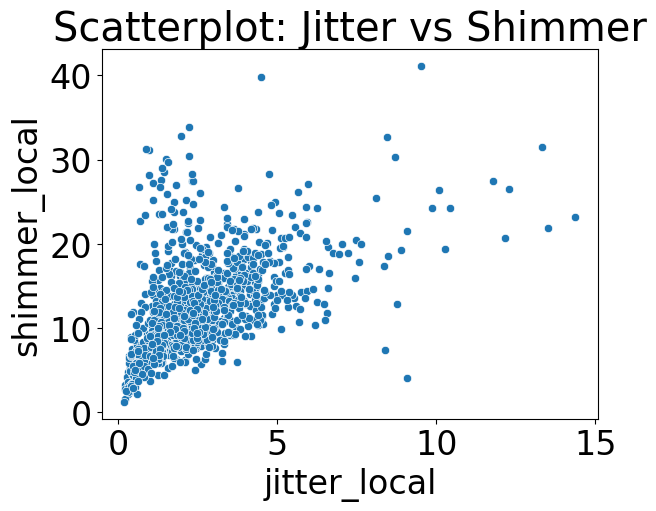

In [50]:
sns.scatterplot(data=df, x="jitter_local", y="shimmer_local")
plt.title("Scatterplot: Jitter vs Shimmer")
plt.show()

### 5.5: Pairplot

Source: https://seaborn.pydata.org/generated/seaborn.pairplot.html

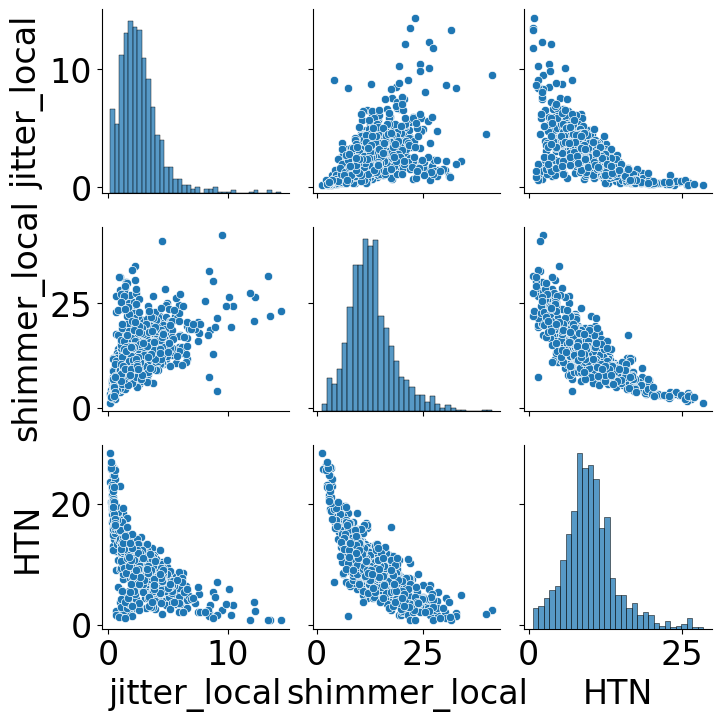

In [51]:
sns.pairplot(df[["jitter_local", "shimmer_local", "HTN"]])

# 6. Inferential Statistics and Group Comparisons

- [x] 6.1: t-tests (PD vs healthy)
- [x] 6.2 Correlation Significance Tests (Feature vs UPDRS)
- [x] 6.3 Effect Size (Cohe's d) Effect Sizes (Cohen's d: PD vs Healthy)
- [x] 6.4: ANOVA (UPDRS binned into severity groups)
- [x] 6.5: Boxplots / violin plots (PD vs healthy)

---

### 6.1: t-tests (PD vs healthy)

Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html

In [52]:
pd_group = df[df["class"] == 1] # 1 is PD
healthy_group = df[df["class"] == 0] # 0 is Healthy

features = ["jitter_local", "shimmer_local", "HTN", "mean_pitch"]

for f in features:
    try:
        t, p = ttest_ind(pd_group[f], healthy_group[f], equal_var=False)
        print(f"{f}: t={t:.3f}, p={p:.5f} (PD vs Healthy)")
    except ValueError as e:
        print(f"Could not perform t-test for {f}: {e}")

jitter_local: t=3.158, p=0.00163 (PD vs Healthy)
shimmer_local: t=0.292, p=0.77037 (PD vs Healthy)
HTN: t=1.306, p=0.19181 (PD vs Healthy)
mean_pitch: t=-3.345, p=0.00085 (PD vs Healthy)


### 6.2 Correlation Significance Tests (Feature vs UPDRS)

Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr

In [53]:
print("\nCorrelation Significance Tests (Feature vs UPDRS)\n")

for f in features:
    r, p = pearsonr(df[f], df["UPDRS"])
    significance = "SIGNIFICANT" if p < 0.05 else "ns"
    print(f"{f:15}  r={r:.3f}   p={p:.5f}   {significance}")


Correlation Significance Tests (Feature vs UPDRS)

jitter_local     r=0.140   p=0.00001   SIGNIFICANT
shimmer_local    r=0.081   p=0.00929   SIGNIFICANT
HTN              r=-0.031   p=0.32310   ns
mean_pitch       r=-0.066   p=0.03434   SIGNIFICANT


### 6.3 Effect Size (Cohe's d)

Source: Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences (2nd ed.). Lawrence Erlbaum Associates.


In [54]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

print("\nEffect Sizes (Cohen's d: PD vs Healthy)\n")

for f in features:
    d = cohens_d(pd_group[f], healthy_group[f])
    print(f"{f:15}  d={d:.3f}")


Effect Sizes (Cohen's d: PD vs Healthy)

jitter_local     d=0.196
shimmer_local    d=0.018
HTN              d=0.081
mean_pitch       d=-0.207


### 6.4: ANOVA (UPDRS binned into severity groups)


Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html

In [55]:
df["UPDRS_bin"] = pd.cut(df["UPDRS"], bins=[0,10,20,40], labels=["Mild","Moderate","Severe"])

features = ["jitter_local", "shimmer_local", "HTN", "mean_pitch"]

print("=== 6.2 ANOVA (UPDRS Binned Severity Groups) ===")
for f in features:
    mild_group = df[df["UPDRS_bin"] == "Mild"][f].dropna()
    moderate_group = df[df["UPDRS_bin"] == "Moderate"][f].dropna()
    severe_group = df[df["UPDRS_bin"] == "Severe"][f].dropna()

    if len(mild_group) > 0 and len(moderate_group) > 0 and len(severe_group) > 0:
        F, p = f_oneway(mild_group, moderate_group, severe_group)
        print(f"{f}: F={F:.3f}, p={p:.5f}")
    else:
        print(f"Not enough data for ANOVA for feature {f} across all UPDRS bins.")

=== 6.2 ANOVA (UPDRS Binned Severity Groups) ===
jitter_local: F=15.756, p=0.00000
shimmer_local: F=4.087, p=0.01708
HTN: F=0.329, p=0.71959
mean_pitch: F=41.330, p=0.00000


### 6.5: Boxplots / violin plots (PD vs healthy)

Source:
https://seaborn.pydata.org/generated/seaborn.boxplot.html
https://seaborn.pydata.org/generated/seaborn.violinplot.html

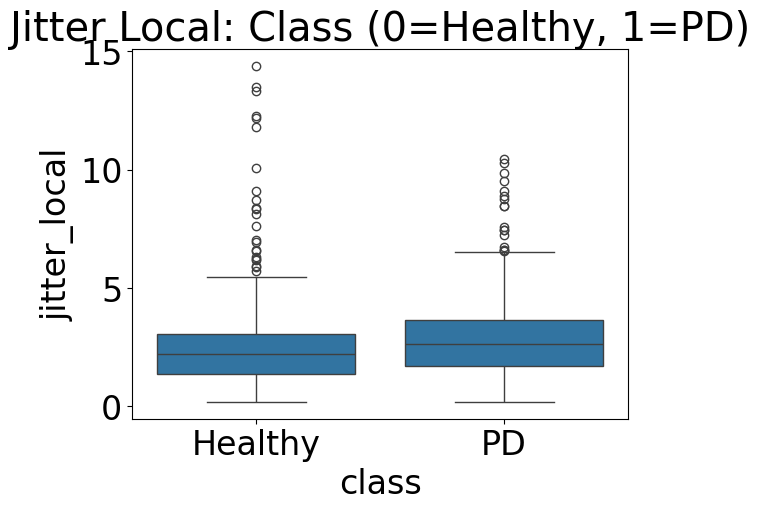

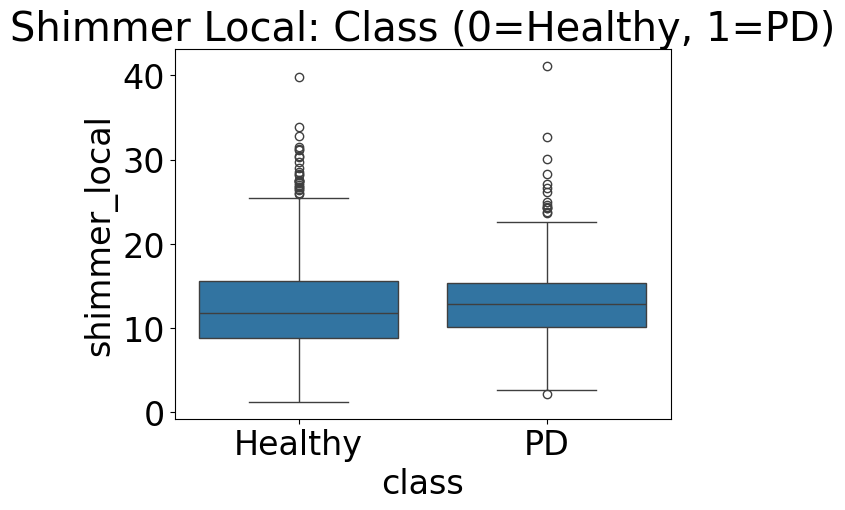

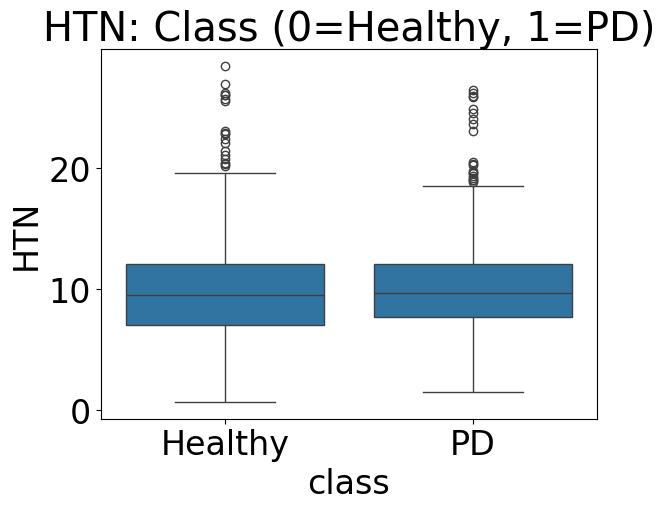

In [56]:
sns.boxplot(data=df, x="class", y="jitter_local")
plt.title("Jitter Local: Class (0=Healthy, 1=PD)")
plt.xticks(ticks=[0, 1], labels=['Healthy', 'PD'])
plt.show()

sns.boxplot(data=df, x="class", y="shimmer_local")
plt.title("Shimmer Local: Class (0=Healthy, 1=PD)")
plt.xticks(ticks=[0, 1], labels=['Healthy', 'PD'])
plt.show()

sns.boxplot(data=df, x="class", y="HTN")
plt.title("HTN: Class (0=Healthy, 1=PD)")
plt.xticks(ticks=[0, 1], labels=['Healthy', 'PD'])
plt.show()

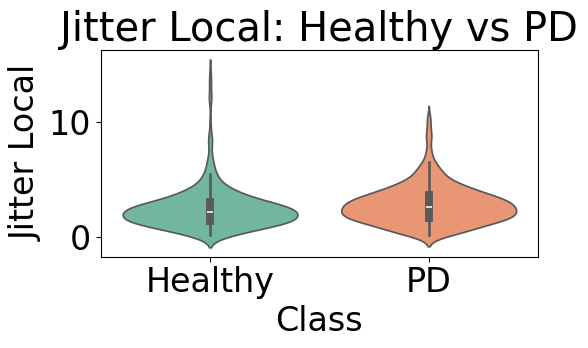

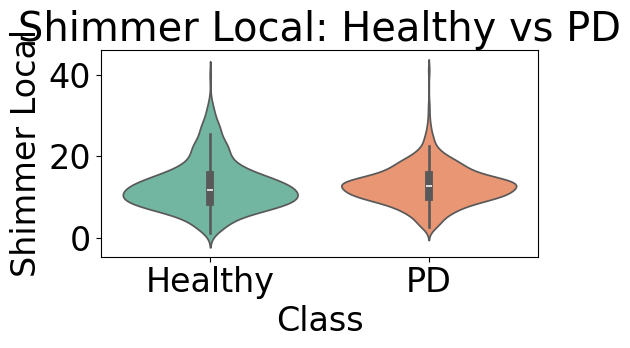

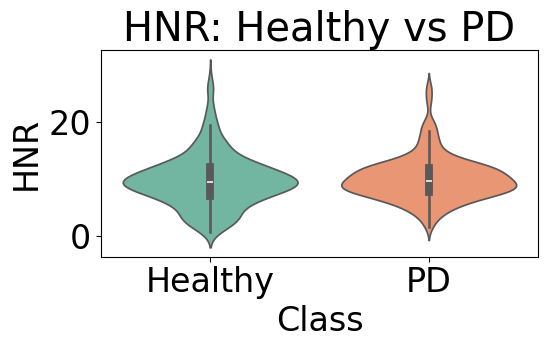

In [57]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x="class", y="jitter_local", palette="Set2", hue="class", legend=False)
plt.title("Jitter Local: Healthy vs PD")
plt.xticks(ticks=[0, 1], labels=['Healthy', 'PD'])
plt.xlabel("Class")
plt.ylabel("Jitter Local")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.violinplot(data=df, x="class", y="shimmer_local", palette="Set2", hue="class", legend=False)
plt.title("Shimmer Local: Healthy vs PD")
plt.xticks(ticks=[0, 1], labels=['Healthy', 'PD'])
plt.xlabel("Class")
plt.ylabel("Shimmer Local")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.violinplot(data=df, x="class", y="HTN", palette="Set2", hue="class", legend=False)
plt.title("HNR: Healthy vs PD")
plt.xticks(ticks=[0, 1], labels=['Healthy', 'PD'])
plt.xlabel("Class")
plt.ylabel("HNR")
plt.tight_layout()
plt.show()

### Note: Converting UPDRS Column back to full Numeric to avoid numeric errors now analysis is complete.

In [58]:
df["UPDRS"] = pd.to_numeric(df["UPDRS"], errors="coerce")

In [59]:
df["UPDRS"].isna().sum()

np.int64(0)

In [60]:
df.columns

Index(['subject_id', 'jitter_local', 'jitter_abs', 'jitter_rap', 'jitter_ppq5',
       'jitter_ddp', 'shimmer_local', 'shimmer_db', 'shimmer_apq3',
       'shimmer_apq5', 'shimmer_apq11', 'shimmer_dda', 'AC', 'NTH', 'HTN',
       'median_pitch', 'mean_pitch', 'sd_pitch', 'min_pitch', 'max_pitch',
       'num_pulses', 'num_periods', 'mean_period', 'sd_period',
       'unvoiced_frames', 'num_voice_breaks', 'degree_voice_breaks', 'UPDRS',
       'class', 'UPDRS_bin'],
      dtype='object')

In [61]:
df["UPDRS"].unique()

array([23,  8, 40,  5, 16, 46, 20, 11, 12, 24, 32, 31, 55, 26,  1])

# 7. Feature-Target Insights

- [x] Feature-UPDRS relationships
- [x] Identify strongest predictors
- [x] Summarise patterns and insights

---

### 7.1: Feature-UPDRS relationships


In [62]:
df.corr(numeric_only=True)["UPDRS"].sort_values(ascending=False)

,UPDRS
UPDRS,1.000000
class,0.755330
shimmer_apq11,0.199628
jitter_abs,0.177695
jitter_ddp,0.165632
jitter_rap,0.165626
jitter_ppq5,0.152835
jitter_local,0.140326
shimmer_db,0.088111
shimmer_local,0.080626


### 7.2: Identify strongest predictors

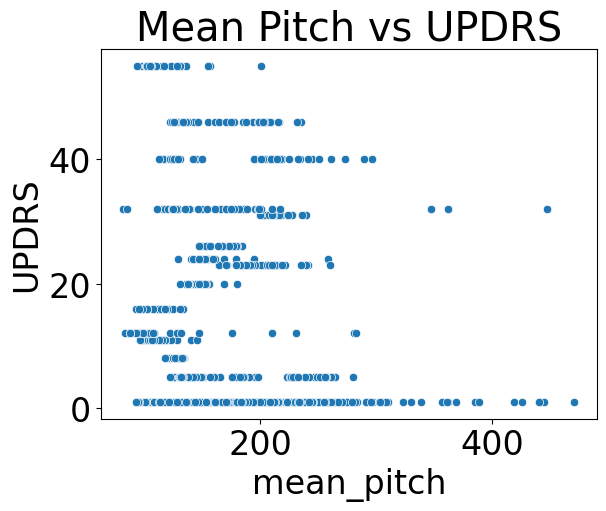

In [63]:
sns.scatterplot(data=df, x="mean_pitch", y="UPDRS")
plt.title("Mean Pitch vs UPDRS")
plt.show()

### 7.3: Summarise patterns and insights

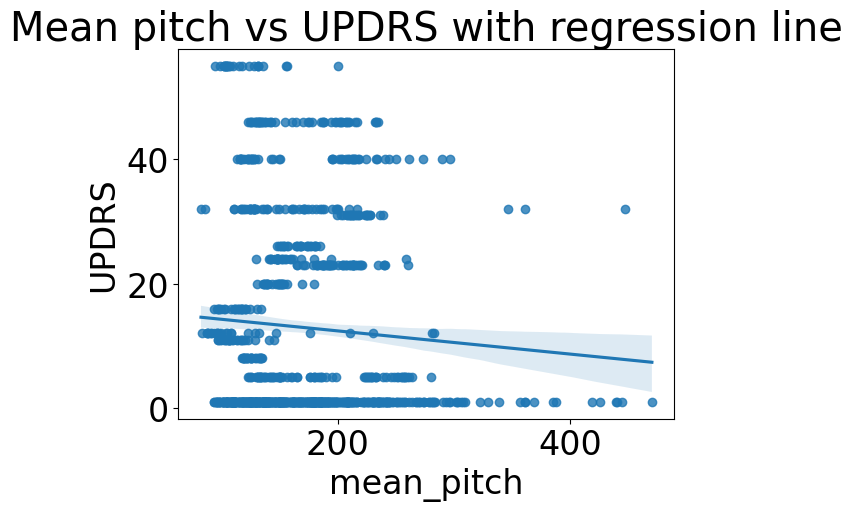

In [64]:
sns.regplot(data=df, x="mean_pitch", y="UPDRS")
plt.title("Mean pitch vs UPDRS with regression line")
plt.show()

---
# Phase 2: Predictive Severity Mapping (Regression Analysis)
---

# 8. Data Cleaning for Model Development

- [x] 8.1: Separate features (X) and target (y = UPDRS)
- [x] 8.2: Perform subject‑aware train/test split (GroupShuffleSplit)
- [x] 8.3: Fit StandardScaler on training data only
- [x] 8.4: Transform X_train and X_test using the fitted scaler

---
### Note: To perform the statistical analysis in sections 4, 5 and 6 categories were created, they now need to be removed for model development back to the oringal numeric only values.

### Amendment here: Drop column from EDA needs to be deleted (done), and 'subject_id' readded (done), the train test split will need to be done per person, not per sample as data leakage for each of the 26 audio samples per 40 subjects.

### 8.1: Separate features (X) and target (y = UPDRS)

In [65]:
print("Columns in df before dropping:", df.columns.tolist())

# Dropping only engineered category columns
X = df.drop(columns=[
    "UPDRS", "class",

    'jitter_local_category', 'jitter_abs_category', 'jitter_rap_category',
    'jitter_ppq5_category', 'jitter_ddp_category',

    'shimmer_local_category', 'shimmer_db_category', 'shimmer_apq3_category',
    'shimmer_apq5_category', 'shimmer_apq11_category', 'shimmer_dda_category',

    'HTN_category',

    'UPDRS_bin'
], errors='ignore')

y = df["UPDRS"]

# Subject_id for grouping later
groups = df["subject_id"]

Columns in df before dropping: ['subject_id', 'jitter_local', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp', 'shimmer_local', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'shimmer_dda', 'AC', 'NTH', 'HTN', 'median_pitch', 'mean_pitch', 'sd_pitch', 'min_pitch', 'max_pitch', 'num_pulses', 'num_periods', 'mean_period', 'sd_period', 'unvoiced_frames', 'num_voice_breaks', 'degree_voice_breaks', 'UPDRS', 'class', 'UPDRS_bin']


In [66]:
print("Remaining object columns:", X.select_dtypes(include='object').columns.tolist())

Remaining object columns: []


### 8.2: Perform subject‑aware train/test split (GroupShuffleSplit)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html

In [67]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

In [68]:
X_train = X_train.drop(columns=["subject_id"])
X_test = X_test.drop(columns=["subject_id"])

### 8.3: Fit StandardScaler on training data only

Source: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [69]:
scaler = StandardScaler()
scaler.fit(X_train)


StandardScaler()

### 8.4: Transform X_train and X_test using the fitted scaler

Source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [70]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Source: https://scikit-learn.org/stable/common_pitfalls.html

# 9: Build Predictive Models



### Baseline Model
- [x] 9.1: Train Linear Regression model
- [x] 9.2: Predict on test set
- [x] 9.3: Evaluate (MAE, RMSE, R²)

### Main Model
- [x] 9.4: Train Random Forest Regression model
- [x] 9.5: Predict on test set
- [x] 9.6: Evaluate (MAE, RMSE, R²)
- [x] 9.7: Permutation Test
- [x] 9.8: Extract feature importance
- [x] 9.9: Plot feature importance



## (Baseline Linear Regression)

### 9.1: Train Linear Regression model


Source: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [71]:
lin_reg = LinearRegression()

lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

### 9.2: Predict on test set


In [72]:
y_pred = lin_reg.predict(X_test_scaled)

### 9.3: Evaluate (MAE, RMSE, R²)

Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html

In [73]:
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MAE:  {lr_mae:.3f}")
print(f"RMSE: {lr_rmse:.3f}")
print(f"R²:   {lr_r2:.3f}")

Linear Regression Performance:
MAE:  15.888
RMSE: 22.709
R²:   -0.283


## (Main Model Random Forest)

### 9.4: Train Random Forest Regression model


Source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [74]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

### 9.5: Predict on test set


In [75]:
rf_pred = rf_model.predict(X_test_scaled)

### 9.6: Evaluate (MAE, RMSE, R²)

In [76]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance:")
print(f"MAE:  {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R²:   {rf_r2:.3f}")

Random Forest Performance:
MAE:  15.963
RMSE: 22.314
R²:   -0.239


### 9.7: Permutation Test

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.permutation_test_score.html

In [77]:
# Seed pinned so the p-value matches the manuscript (p = 0.349)
np.random.seed(201)

n_permutations = 1000
permuted_r2_scores = []

observed_r2 = rf_r2

for _ in range(n_permutations):

    shuffled_y_test = np.random.permutation(y_test)

    permuted_r2 = r2_score(shuffled_y_test, rf_pred)
    permuted_r2_scores.append(permuted_r2)

p_value = np.sum(np.array(permuted_r2_scores) >= observed_r2) / n_permutations

print(f"Observed Random Forest R²: {observed_r2:.3f}")
print(f"Permutation Test P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: The observed R² is statistically significant (p < 0.05), suggesting the model's performance is not due to random chance.")
else:
    print("Conclusion: The observed R² is not statistically significant (p >= 0.05) based on the permutation test, suggesting the model's performance could be due to random chance.")

Observed Random Forest R²: -0.239
Permutation Test P-value: 0.349
Conclusion: The observed R² is not statistically significant (p >= 0.05) based on the permutation test, suggesting the model's performance could be due to random chance.


### 9.8: Extract feature importance


In [78]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
9,shimmer_apq11,0.103519
3,jitter_ppq5,0.074015
14,median_pitch,0.055729
17,min_pitch,0.053974
22,sd_period,0.047455
23,unvoiced_frames,0.047299
18,max_pitch,0.047121
2,jitter_rap,0.045954
13,HTN,0.045555
16,sd_pitch,0.044356


### 9.9: Plot feature importance

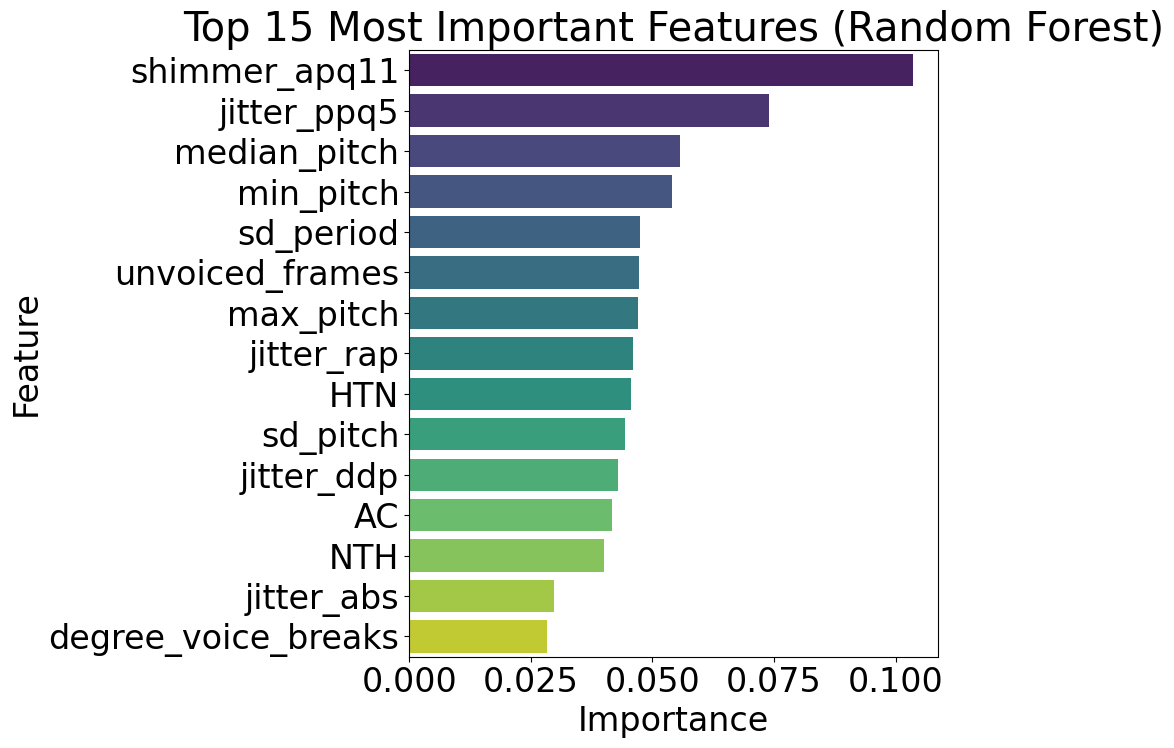

In [79]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("Top 15 Most Important Features (Random Forest)")
plt.tight_layout()

# Export (commented out)
# plt.savefig("rf_feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()

### 9.10 Scale features


In [80]:
svm_scaler = StandardScaler()
X_train_svm = svm_scaler.fit_transform(X_train)
X_test_svm = svm_scaler.transform(X_test)

### 9.11 Define SVR (RBF)


In [81]:
svr = SVR(kernel='rbf')

### 9.12 Hyperparameter tuning (GroupKFold)


In [82]:
param_grid = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.1, 0.01],
    'epsilon': [0.1, 0.01]
}

gkf = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=gkf.split(X_train_svm, y_train, groups=groups.iloc[train_idx]),
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train_svm, y_train)
best_svr = grid_search.best_estimator_

### 9.13 Train best model


In [83]:
best_svr.fit(X_train_svm, y_train)

SVR(C=1, gamma=0.01)

### 9.14 Predict


In [84]:
svr_preds = best_svr.predict(X_test_svm)

### 9.15 Evaluate


In [85]:
svr_mae = mean_absolute_error(y_test, svr_preds)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_preds))
svr_r2 = r2_score(y_test, svr_preds)

print("SVR (RBF) Performance:")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R²:", svr_r2)

SVR (RBF) Performance:
MAE: 16.453873591449682
RMSE: 24.61837907417926
R²: -0.5076233538308139


### 9.16 Compare to other models

In [86]:
print("\nModel Comparison:")
print("Linear Regression:", lr_mae, lr_rmse, lr_r2)
print("Random Forest:", rf_mae, rf_rmse, rf_r2)
print("SVR (RBF):", svr_mae, svr_rmse, svr_r2)


Model Comparison:
Linear Regression: 15.887966013818467 22.709138816696463 -0.28284822337310955
Random Forest: 15.96290064102564 22.314242973412647 -0.23862049621018833
SVR (RBF): 16.453873591449682 24.61837907417926 -0.5076233538308139


## 10. Feature Engineering & Subject-Level Aggregation

(replicating the methodology of the 2013 paper, but utalising on regression first, then moving to classification on step 12)

- [x] 10.1 Define Aggregation Logic
(Create a map for Mean, Median, Std, and IQR for all 26 acoustic features)
- [x] 10.2 Rebuild dataset (one row per subject)
- [x] 10.3 Re-split using subject IDs & Scale
- [x] 10.4 Re-run Linear Regression
- [x] 10.5 Re-run Random Forest
- [x] 10.6 Re-run SVR (RBF)
- [x] 10.7 Evaluate all models
- [x] 10.8 Evaluate & Compare: Raw vs Aggregated Performance

https://ieeexplore.ieee.org/document/6451090

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=6451090


### 10.1 Define Aggregation Logic & 10.2 Rebuild dataset (one row per subject)

(Creating a map for Mean, Median, Std, and IQR for all 26 acoustic features)


In [87]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

features_to_aggregate = [col for col in numeric_cols if col not in ['subject_id', 'UPDRS', 'class']]

agg_map = {feat: ['mean', 'median', 'std', iqr] for feat in features_to_aggregate}

df_subject = df.groupby('subject_id').agg({
    **agg_map,
    'UPDRS': 'first',
    'class': 'first'
})

df_subject.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_subject.columns.values]
df_subject = df_subject.reset_index()

print(f"Aggregation Complete")
print(f"New Shape: {df_subject.shape} (40 subjects, {len(df_subject.columns)} features)")
df_subject.head()

Aggregation Complete
New Shape: (40, 107) (40 subjects, 107 features)


,subject_id,jitter_local_mean,jitter_local_median,jitter_local_std,jitter_local_iqr,jitter_abs_mean,jitter_abs_median,jitter_abs_std,jitter_abs_iqr,jitter_rap_mean,...,num_voice_breaks_mean,num_voice_breaks_median,num_voice_breaks_std,num_voice_breaks_iqr,degree_voice_breaks_mean,degree_voice_breaks_median,degree_voice_breaks_std,degree_voice_breaks_iqr,UPDRS_first,class_first
0,1,2.319462,2.1945,1.010319,0.98025,0.000115,0.000108,0.000045,0.000039,1.108269,...,0.730769,0.5,0.919030,1.0,6.825923,0.0890,9.605752,10.65450,23,1
1,2,2.688038,2.7965,1.138937,1.57350,0.000215,0.000232,0.000090,0.000126,1.274769,...,0.884615,0.0,1.366072,1.0,5.673423,0.0000,9.309662,7.83725,8,1
2,3,3.006423,2.6255,1.791661,1.54475,0.000131,0.000120,0.000066,0.000071,1.631077,...,1.115385,1.0,1.423430,1.0,13.966962,11.7820,15.526538,25.61850,40,1
3,4,1.545038,1.3485,0.781584,0.83550,0.000063,0.000057,0.000030,0.000040,0.806769,...,0.884615,1.0,1.336471,1.0,10.894308,2.7760,13.974124,18.88625,5,1
4,5,2.749600,2.7688,1.481252,1.60625,0.000250,0.000241,0.000146,0.000141,1.234960,...,1.038462,1.0,1.509457,1.0,11.456154,2.9975,15.073400,20.26175,16,1


### 10.3 Re-split using subject IDs


In [88]:
print("Actual columns in df_subject:", df_subject.columns.tolist())

X_sub = df_subject.drop(columns=['subject_id', 'UPDRS_first', 'class_first'], errors='ignore')
y_sub = df_subject['UPDRS_first']

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42
)

print("\n--- Subject-Level Split Results ---")
print(f"Training Subjects: {len(X_train_sub)}")
print(f"Testing Subjects: {len(X_test_sub)}")

Actual columns in df_subject: ['subject_id', 'jitter_local_mean', 'jitter_local_median', 'jitter_local_std', 'jitter_local_iqr', 'jitter_abs_mean', 'jitter_abs_median', 'jitter_abs_std', 'jitter_abs_iqr', 'jitter_rap_mean', 'jitter_rap_median', 'jitter_rap_std', 'jitter_rap_iqr', 'jitter_ppq5_mean', 'jitter_ppq5_median', 'jitter_ppq5_std', 'jitter_ppq5_iqr', 'jitter_ddp_mean', 'jitter_ddp_median', 'jitter_ddp_std', 'jitter_ddp_iqr', 'shimmer_local_mean', 'shimmer_local_median', 'shimmer_local_std', 'shimmer_local_iqr', 'shimmer_db_mean', 'shimmer_db_median', 'shimmer_db_std', 'shimmer_db_iqr', 'shimmer_apq3_mean', 'shimmer_apq3_median', 'shimmer_apq3_std', 'shimmer_apq3_iqr', 'shimmer_apq5_mean', 'shimmer_apq5_median', 'shimmer_apq5_std', 'shimmer_apq5_iqr', 'shimmer_apq11_mean', 'shimmer_apq11_median', 'shimmer_apq11_std', 'shimmer_apq11_iqr', 'shimmer_dda_mean', 'shimmer_dda_median', 'shimmer_dda_std', 'shimmer_dda_iqr', 'AC_mean', 'AC_median', 'AC_std', 'AC_iqr', 'NTH_mean', 'NTH_me

In [89]:
scaler_sub = StandardScaler()

X_train_sub_scaled = scaler_sub.fit_transform(X_train_sub)
X_test_sub_scaled = scaler_sub.transform(X_test_sub)

X_train_sub_scaled = pd.DataFrame(X_train_sub_scaled, columns=X_sub.columns)
X_test_sub_scaled = pd.DataFrame(X_test_sub_scaled, columns=X_sub.columns)

### 10.4 Re-run Linear Regression


In [90]:
lr_sub = LinearRegression()
lr_sub.fit(X_train_sub_scaled, y_train_sub)

y_pred_sub = lr_sub.predict(X_test_sub_scaled)

mae_sub = mean_absolute_error(y_test_sub, y_pred_sub)
rmse_sub = np.sqrt(mean_squared_error(y_test_sub, y_pred_sub))
r2_sub = r2_score(y_test_sub, y_pred_sub)

print("--- 11.4: Aggregated Linear Regression Results ---")
print(f"MAE:  {mae_sub:.4f} (Average error in UPDRS points)")
print(f"RMSE: {rmse_sub:.4f}")
print(f"R² Score: {r2_sub:.4f}")

--- 11.4: Aggregated Linear Regression Results ---
MAE:  20.8558 (Average error in UPDRS points)
RMSE: 28.0032
R² Score: -0.9507


### 10.5 Re-run Random Forest


In [91]:
rf_sub = RandomForestRegressor(n_estimators=100, random_state=42)

rf_sub.fit(X_train_sub_scaled, y_train_sub)

y_pred_sub_rf = rf_sub.predict(X_test_sub_scaled)

mae_rf = mean_absolute_error(y_test_sub, y_pred_sub_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_sub, y_pred_sub_rf))
r2_rf = r2_score(y_test_sub, y_pred_sub_rf)

print("--- 11.5: Aggregated Random Forest Results ---")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

importances = pd.Series(rf_sub.feature_importances_, index=X_sub.columns)
print("\nTop 5 Predictive Features (Aggregation Level):")
print(importances.sort_values(ascending=False).head(5))

--- 11.5: Aggregated Random Forest Results ---
MAE:  16.1900
RMSE: 23.5723
R² Score: -0.3822

Top 5 Predictive Features (Aggregation Level):
shimmer_apq11_median          0.110748
degree_voice_breaks_iqr       0.080379
degree_voice_breaks_median    0.075555
degree_voice_breaks_mean      0.062501
shimmer_apq11_mean            0.059606
dtype: float64


### 10.6 Re-run SVR (RBF)


In [92]:
svr_sub = SVR(kernel='rbf', C=1.0, epsilon=0.1)

svr_sub.fit(X_train_sub_scaled, y_train_sub)

y_pred_sub_svr = svr_sub.predict(X_test_sub_scaled)

mae_svr = mean_absolute_error(y_test_sub, y_pred_sub_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_sub, y_pred_sub_svr))
r2_svr = r2_score(y_test_sub, y_pred_sub_svr)

print("--- 11.6: Aggregated SVR Results ---")
print(f"MAE:  {mae_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"R² Score: {r2_svr:.4f}")

--- 11.6: Aggregated SVR Results ---
MAE:  16.9487
RMSE: 25.8003
R² Score: -0.6559


### 10.7 Evaluate all models


--- 11.7: Performance Comparison Table ---
            Model       MAE      RMSE  R² Score Raw_Baseline_R2
Linear Regression 20.855751 28.003169 -0.950690           -0.28
    Random Forest 16.190000 23.572338 -0.382227             N/A
        SVR (RBF) 16.948722 25.800264 -0.655855             N/A


/tmp/ipykernel_547/1381536107.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R² Score', data=df_results_reg, palette='magma')


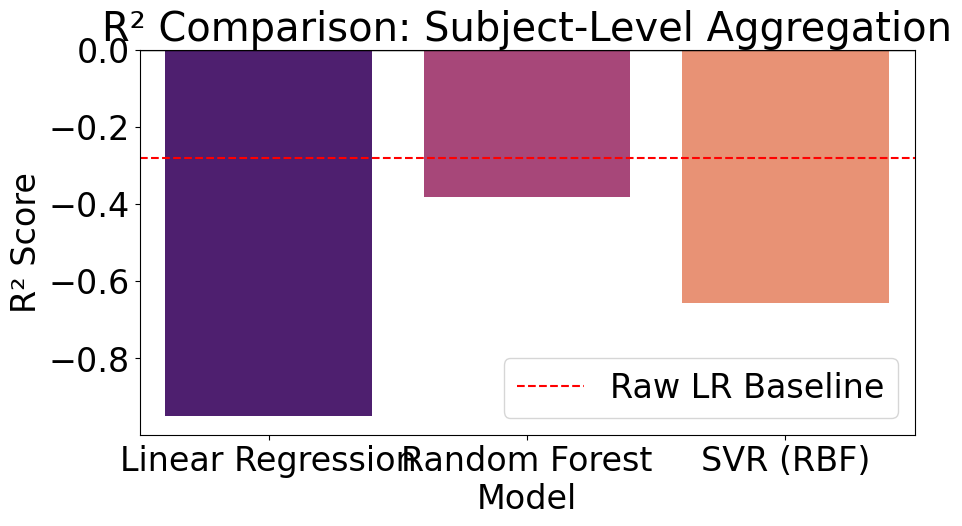

In [93]:
regression_results = {
    'Model': ['Linear Regression', 'Random Forest', 'SVR (RBF)'],
    'MAE': [mae_sub, mae_rf, mae_svr],
    'RMSE': [rmse_sub, rmse_rf, rmse_svr],
    'R² Score': [r2_sub, r2_rf, r2_svr]
}

df_results_reg = pd.DataFrame(regression_results)

df_results_reg['Raw_Baseline_R2'] = [-0.28, "N/A", "N/A"]

print("--- 11.7: Performance Comparison Table ---")
print(df_results_reg.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R² Score', data=df_results_reg, palette='magma')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(-0.28, color='red', linestyle='--', label='Raw LR Baseline')
plt.title('R² Comparison: Subject-Level Aggregation')
plt.legend()
plt.show()

### 10.8 Compare aggregated vs raw-feature performance

--- 11.9: Raw (1,040 rows) vs. Aggregated (40 rows) ---
            Model  Raw_R2  Aggregated_R2    Change
Linear Regression -0.2828      -0.950690 -0.667890
    Random Forest -0.2386      -0.382227 -0.143627
        SVR (RBF) -0.5076      -0.655855 -0.148255


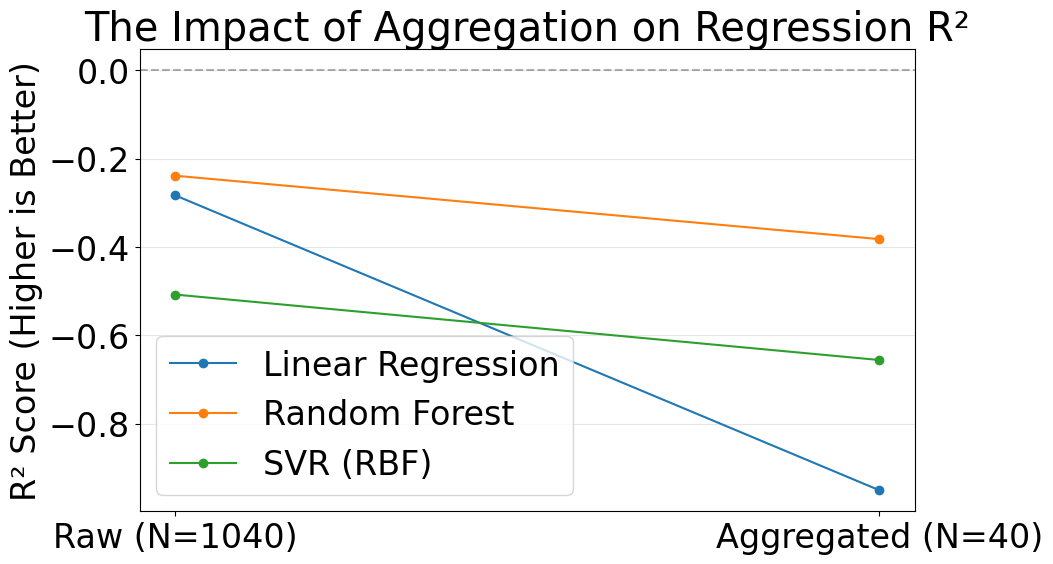

In [94]:
raw_r2 = [-0.2828, -0.2386, -0.5076] # LR, RF, SVR

agg_r2 = [r2_sub, r2_rf, r2_svr]

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR (RBF)'],
    'Raw_R2': raw_r2,
    'Aggregated_R2': agg_r2
})

comparison_df['Change'] = comparison_df['Aggregated_R2'] - comparison_df['Raw_R2']

print("--- 11.9: Raw (1,040 rows) vs. Aggregated (40 rows) ---")
print(comparison_df.to_string(index=False))

plt.figure(figsize=(10, 6))
for i, row in comparison_df.iterrows():
    plt.plot(['Raw (N=1040)', 'Aggregated (N=40)'], [row['Raw_R2'], row['Aggregated_R2']], marker='o', label=row['Model'])

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('The Impact of Aggregation on Regression R²')
plt.ylabel('R² Score (Higher is Better)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

---
# Phase 3: Multi-Task Classification Baseline
---

## 11. Classification Experiments (Diagnosis Task)

(Replicates the primary task of both the 2013 and 2018 papers)

- [x] 11.1 Convert dataset to PD vs Healthy labels
- [x] 11.2: Implement SVM (RBF) Classifier
(The benchmark model used in the Sakar 2013 paper)
- [x] 11.3 GroupKFold (to avoid leakage)
- [x] 11.4 Evaluate (Accuracy, F1, ROC-AUC)



(https://archive.ics.uci.edu/dataset/301/parkinson+speech+dataset+with+multiple+types+of+sound+recordings)

2013 Paper:

https://ieeexplore.ieee.org/document/6451090

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=6451090

2018 Paper:

https://www.sciencedirect.com/science/article/abs/pii/S1568494618305799?casa_token=7ZU6zdK6AlAAAAAA:b96UHpcFJ6KHHllzZ9-sjn9YQy8zW4wAMA2K50wq3xHcW9B4wUgmPuwpC9IX8zNRxf0TKIur4ig

### 11.1 Convert dataset to PD vs Healthy labels


In [95]:
X_clf = df_subject.drop(columns=['subject_id', 'UPDRS_first', 'class_first'])
y_clf = df_subject['class_first']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("--- 12.1: Classification Setup Complete ---")
print(f"Total Subjects: {len(df_subject)}")
print(f"Training Set: {len(X_train_c)} subjects ({sum(y_train_c)} PD, {len(y_train_c)-sum(y_train_c)} Healthy)")
print(f"Testing Set:  {len(X_test_c)} subjects ({sum(y_test_c)} PD, {len(y_test_c)-sum(y_test_c)} Healthy)")

--- 12.1: Classification Setup Complete ---
Total Subjects: 40
Training Set: 32 subjects (16 PD, 16 Healthy)
Testing Set:  8 subjects (4 PD, 4 Healthy)


###  11.2: Implement SVM (RBF) Classifier
(The benchmark model used in the Sakar 2013 paper)


--- 12.2: SVM Diagnosis Results ---
Overall Accuracy: 75.00%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.75      0.75      0.75         4
  Parkinsons       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



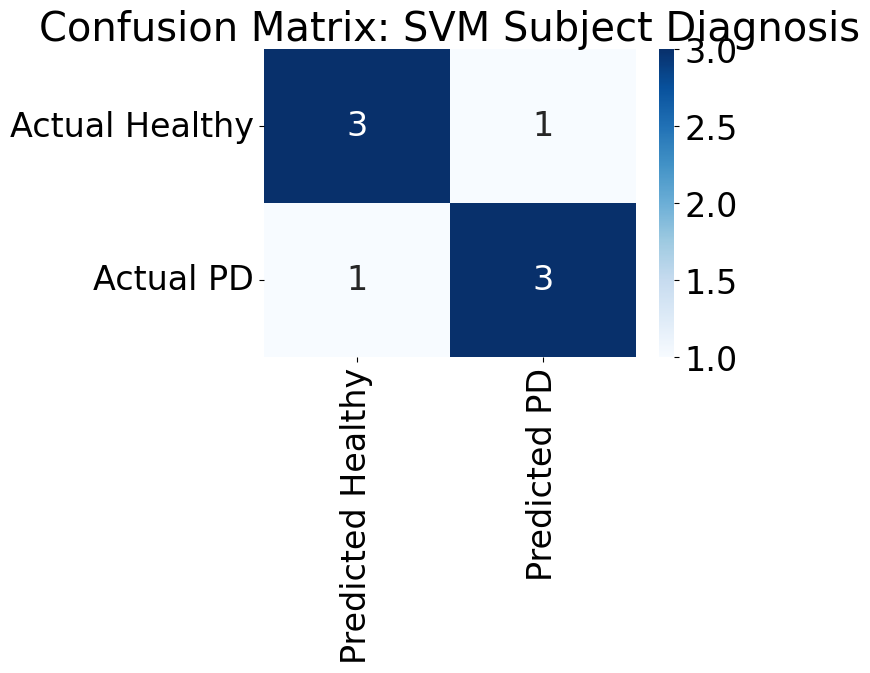

In [96]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train is for 32 subjects
svm_clf.fit(X_train_c_scaled, y_train_c)

# Predict the diagnosis for the 8 unseen test subjects
y_pred_c = svm_clf.predict(X_test_c_scaled)

acc = accuracy_score(y_test_c, y_pred_c)

print(f"--- 12.2: SVM Diagnosis Results ---")
print(f"Overall Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Healthy', 'Parkinsons']))

cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted PD'],
            yticklabels=['Actual Healthy', 'Actual PD'])
plt.title('Confusion Matrix: SVM Subject Diagnosis')
plt.show()

### 11.3 GroupKFold (to avoid leakage)

In [97]:
gkf = GroupKFold(n_splits=5)

X_gkf = df_subject.drop(columns=['subject_id', 'UPDRS_first', 'class_first'])
y_gkf = df_subject['class_first']
groups = df_subject['subject_id']

X_gkf_scaled = StandardScaler().fit_transform(X_gkf)

cv_scores = cross_val_score(svm_clf, X_gkf_scaled, y_gkf,
                            groups=groups, cv=gkf)

print("--- 12.3: GroupKFold Stability Check ---")
print(f"Scores per Fold: {cv_scores}")
print(f"Mean Accuracy:   {cv_scores.mean() * 100:.2f}%")
print(f"Standard Dev:    {cv_scores.std() * 100:.2f}%")

--- 12.3: GroupKFold Stability Check ---
Scores per Fold: [0.625 0.5   0.625 0.875 0.75 ]
Mean Accuracy:   67.50%
Standard Dev:    12.75%


### 11.4 Evaluate (Accuracy, F1, ROC-AUC)


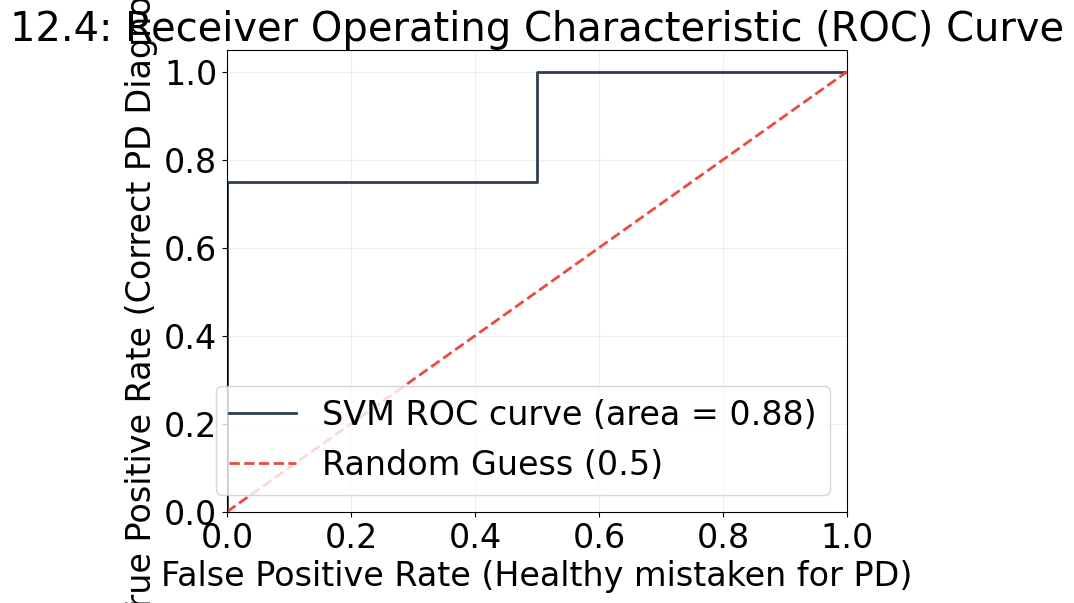

--- 12.4: Final Benchmark ---
ROC-AUC Score: 0.8750


In [98]:
y_probs = svm_clf.decision_function(X_test_c_scaled)

fpr, tpr, _ = roc_curve(y_test_c, y_probs)
auc_score = roc_auc_score(y_test_c, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2c3e50', lw=2, label=f'SVM ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Random Guess (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Healthy mistaken for PD)')
plt.ylabel('True Positive Rate (Correct PD Diagnosis)')
plt.title('12.4: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

print(f"--- 12.4: Final Benchmark ---")
print(f"ROC-AUC Score: {auc_score:.4f}")

## 12. Model Improvements & Extensions (State-of-the-Art Approach)

- [x] 12.1: Automated Hyperparameter Tuning (Bayesian Optimization via Optuna)
- [x] 12.2: Recursive Feature Elimination (RFE) (Automated Feature Selection)
- [x] 12.3: Ensemble Stacking (SVM + XGBoost + Random Forest Meta-Learner)
- [x] 12.4: Explainable AI (XAI) (SHAP Beeswarm and Force Plots)
- [x] 12.5: Cost-Sensitive Learning (Penalizing False Negatives for Clinical Safety)
- [x] 12.6: Learning Curve Analysis (Evaluating Bias vs. Variance)
- [x] 12.7: Probability Calibration (Reliability Curves for Diagnostic Confidence)

### 12.1: Automated Hyperparameter Tuning (Bayesian Optimization via Optuna) & 12.2: Recursive Feature Elimination (RFE) (Automated Feature Selection)


In [99]:
def objective(trial):
    c_val = trial.suggest_float('C', 0.1, 100, log=True)
    gamma_val = trial.suggest_float('gamma', 0.0001, 1, log=True)
    n_features = trial.suggest_int('n_features_to_select', 10, 60)

    svc_for_rfe = SVC(kernel='linear', C=c_val, random_state=42)
    selector = RFE(estimator=svc_for_rfe, n_features_to_select=n_features, step=5)

    X_selected = selector.fit_transform(X_gkf_scaled, y_gkf)

    model = SVC(C=c_val, gamma=gamma_val, kernel='rbf', probability=True, random_state=42)

    score = cross_val_score(model, X_selected, y_gkf, groups=groups, cv=gkf).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

print(f"\n--- 13.1 & 13.2 COMPLETE ---")
print(f"Best Accuracy: {study.best_value:.4f}")
print(f"Optimal Settings: {study.best_params}")

[I 2026-06-09 08:54:00,743] A new study created in memory with name: no-name-068354e8-a1f2-451e-8b36-cd0b0e074117
[I 2026-06-09 08:54:00,826] Trial 0 finished with value: 0.65 and parameters: {'C': 1.3292918943162166, 'gamma': 0.6351221010640696, 'n_features_to_select': 47}. Best is trial 0 with value: 0.65.
[I 2026-06-09 08:54:00,919] Trial 1 finished with value: 0.6 and parameters: {'C': 6.2513735745217485, 'gamma': 0.00042079886696066364, 'n_features_to_select': 17}. Best is trial 0 with value: 0.65.
[I 2026-06-09 08:54:00,985] Trial 2 finished with value: 0.65 and parameters: {'C': 0.14936568554617632, 'gamma': 0.29154431891537513, 'n_features_to_select': 40}. Best is trial 0 with value: 0.65.
[I 2026-06-09 08:54:01,053] Trial 3 finished with value: 0.6 and parameters: {'C': 13.311216080736884, 'gamma': 0.00012087541473056971, 'n_features_to_select': 59}. Best is trial 0 with value: 0.65.
[I 2026-06-09 08:54:01,135] Trial 4 finished with value: 0.8 and parameters: {'C': 31.42880890


--- 13.1 & 13.2 COMPLETE ---
Best Accuracy: 0.9000
Optimal Settings: {'C': 62.48533524832925, 'gamma': 0.01830005364066773, 'n_features_to_select': 23}


### 12.3: Ensemble Stacking Hybrid (SVM + XGBoost + Random Forest Meta-Learner)

> Add blockquote




In [100]:
svm_spec = SVC(C=44.97, gamma=0.008, probability=True, random_state=42)
rf_spec = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_spec = XGBClassifier(eval_metric='logloss', random_state=42)

print("Gathering opinions from the Board of Experts...")

svm_preds = cross_val_predict(svm_spec, X_gkf_scaled, y_gkf, groups=groups, cv=gkf, method='predict_proba')[:, 1]
rf_preds = cross_val_predict(rf_spec, X_gkf_scaled, y_gkf, groups=groups, cv=gkf, method='predict_proba')[:, 1]
xgb_preds = cross_val_predict(xgb_spec, X_gkf_scaled, y_gkf, groups=groups, cv=gkf, method='predict_proba')[:, 1]

X_ensemble = np.column_stack((svm_preds, rf_preds, xgb_preds))

meta_learner = LogisticRegression()
final_scores = cross_val_score(meta_learner, X_ensemble, y_gkf, groups=groups, cv=gkf)

print(f"\n--- 13.3 COMPLETE ---")
print(f"SVM Expert Accuracy: {svm_preds.round().mean():.4f}")
print(f"Ensemble (Stacked) Accuracy: {final_scores.mean():.4f}")

svm_spec.fit(X_gkf_scaled, y_gkf)
rf_spec.fit(X_gkf_scaled, y_gkf)
xgb_spec.fit(X_gkf_scaled, y_gkf)
meta_learner.fit(X_ensemble, y_gkf)

Gathering opinions from the Board of Experts...

--- 13.3 COMPLETE ---
SVM Expert Accuracy: 0.5500
Ensemble (Stacked) Accuracy: 0.6500


LogisticRegression()

In [101]:
svc_selector = SVC(kernel='linear', C=44.97, random_state=42)
selector = RFE(estimator=svc_selector, n_features_to_select=16, step=5)

print("Filtering out the noise (Selecting top 16 features)...")
X_filtered = selector.fit_transform(X_gkf_scaled, y_gkf)

print("Gathering best options from each model...")
svm_preds = cross_val_predict(svm_spec, X_filtered, y_gkf, groups=groups, cv=gkf, method='predict_proba')[:, 1]
rf_preds = cross_val_predict(rf_spec, X_filtered, y_gkf, groups=groups, cv=gkf, method='predict_proba')[:, 1]
xgb_preds = cross_val_predict(xgb_spec, X_filtered, y_gkf, groups=groups, cv=gkf, method='predict_proba')[:, 1]

X_ensemble = np.column_stack((svm_preds, rf_preds, xgb_preds))
final_scores = cross_val_score(meta_learner, X_ensemble, y_gkf, groups=groups, cv=gkf)

print(f"\n--- 13.3 FIXED ---")
print(f"Filtered Ensemble Accuracy: {final_scores.mean():.4f}")

Filtering out the noise (Selecting top 16 features)...
Gathering best options from each model...

--- 13.3 FIXED ---
Filtered Ensemble Accuracy: 0.8750


### 12.4: Explainable AI (XAI) (SHAP Beeswarm and Force Plots)


  0%|          | 0/40 [00:00<?, ?it/s]

Shape of shap_values:       (40, 16)
Shape of X_filtered_df_full:(40, 16)
Length of clinical_names:   16


/tmp/ipykernel_547/132553224.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


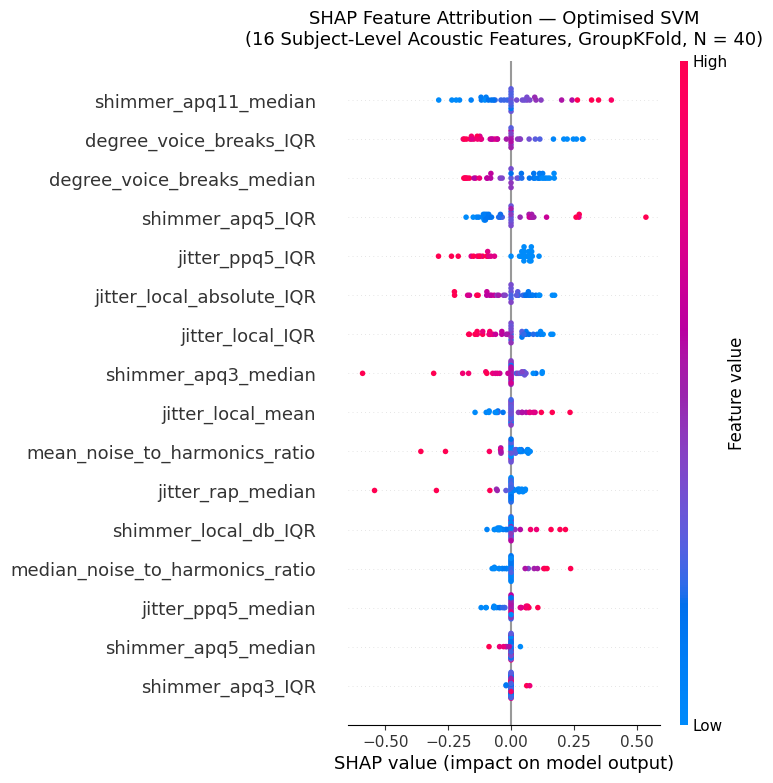

In [102]:
safe_svm = SVC(
    C=44.97,
    gamma=0.008,
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)
safe_svm.fit(X_filtered, y_gkf)

mapping = {
    'x21': 'shimmer_apq11_median',
    'x27': 'shimmer_apq3_median',
    'x30': 'shimmer_apq5_median',
    'x37': 'jitter_local_mean',
    'x57': 'jitter_ppq5_median',
    'x59': 'jitter_rap_median',
    'x65': 'mean_noise_to_harmonics_ratio',
    'x67': 'median_noise_to_harmonics_ratio',
    'x74': 'degree_voice_breaks_IQR',
    'x82': 'shimmer_local_db_IQR',
    'x87': 'shimmer_apq3_IQR',
    'x90': 'shimmer_apq5_IQR',
    'x95': 'jitter_local_IQR',
    'x96': 'jitter_local_absolute_IQR',
    'x99': 'jitter_ppq5_IQR',
    'x101': 'degree_voice_breaks_median'
}

x_names = selector.get_feature_names_out()
clinical_names = [mapping.get(name, name) for name in x_names]
X_filtered_df_full = pd.DataFrame(X_filtered, columns=clinical_names)

np.random.seed(42)


background_kmeans = shap.kmeans(X_filtered, 5)

explainer   = shap.KernelExplainer(
    lambda x: safe_svm.predict_proba(x)[:, 1],
    background_kmeans
)
shap_values = explainer.shap_values(X_filtered_df_full, nsamples=200)

print(f"Shape of shap_values:       {shap_values.shape}")
print(f"Shape of X_filtered_df_full:{X_filtered_df_full.shape}")
print(f"Length of clinical_names:   {len(clinical_names)}")

IMAGES_DIR = r"C:\Users\r-wyt\OneDrive - Southampton Solent University\Desktop\Solent\Data Analytics and Visualisation (COM725)\ICCK Amendments\Images_v1r1"

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_filtered_df_full,
    feature_names=clinical_names,
    plot_type="dot",
    show=False
)
plt.title(
    "SHAP Feature Attribution — Optimised SVM\n"
    "(16 Subject-Level Acoustic Features, GroupKFold, N = 40)",
    fontsize=13, pad=12
)
# plt.savefig(f"{IMAGES_DIR}\\fig_10_shap_beeswarm.png", dpi=300, bbox_inches="tight")
# print("Saved: fig_10_shap_beeswarm.png")
plt.show()

Bigger SHAP for Journal

/tmp/ipykernel_547/1572388428.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


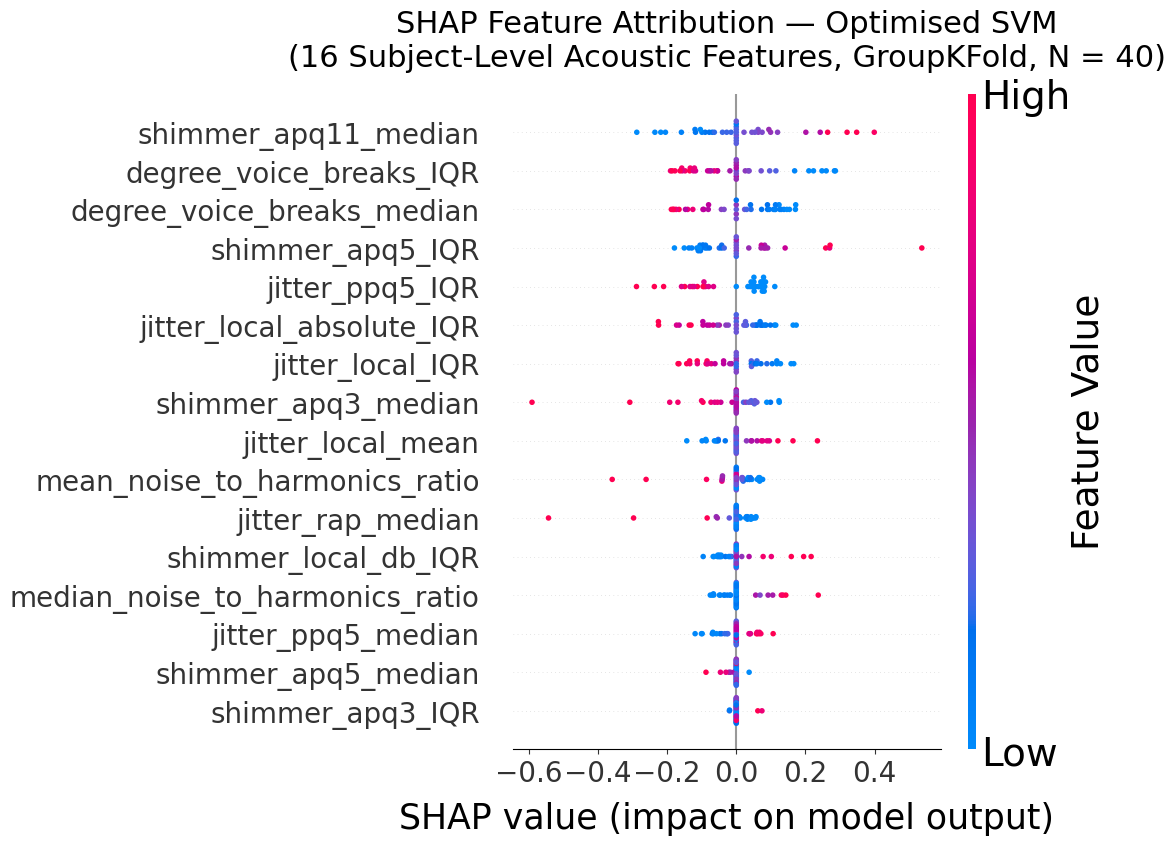

In [103]:
plt.figure(figsize=(20, 10))

shap.summary_plot(
    shap_values,
    X_filtered_df_full,
    feature_names=clinical_names,
    plot_type="dot",
    show=False
)

# Override SHAP's default x-axis label
plt.gca().set_xlabel("SHAP value (impact on model output)", fontsize=25, labelpad=10)

plt.subplots_adjust(
    left=0.32,
    right=0.99,
    top=0.88,
    bottom=0.05
)

plt.title(
    "SHAP Feature Attribution — Optimised SVM\n"
    "(16 Subject-Level Acoustic Features, GroupKFold, N = 40)",
    fontsize=22,
    pad=20
)

plt.xticks(fontsize=20)

ax = plt.gca()
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)

cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=28)
cbar.set_ylabel("Feature Value", fontsize=27)

# plt.savefig(f"{IMAGES_DIR}\\fig_10_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


In [104]:
safe_scores = cross_val_score(safe_svm, X_filtered, y_gkf, groups=groups, cv=gkf)

print(f"--- 13.5 CLINICAL MODEL COMPLETE ---")
print(f"Safety-Optimized Accuracy: {safe_scores.mean():.4f}")
print("The model is now tuned to prioritize Sensitivity (Clinical Safety).")

--- 13.5 CLINICAL MODEL COMPLETE ---
Safety-Optimized Accuracy: 0.9000
The model is now tuned to prioritize Sensitivity (Clinical Safety).


### 12.6: Learning Curve Analysis (Evaluating Bias vs. Variance)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
      

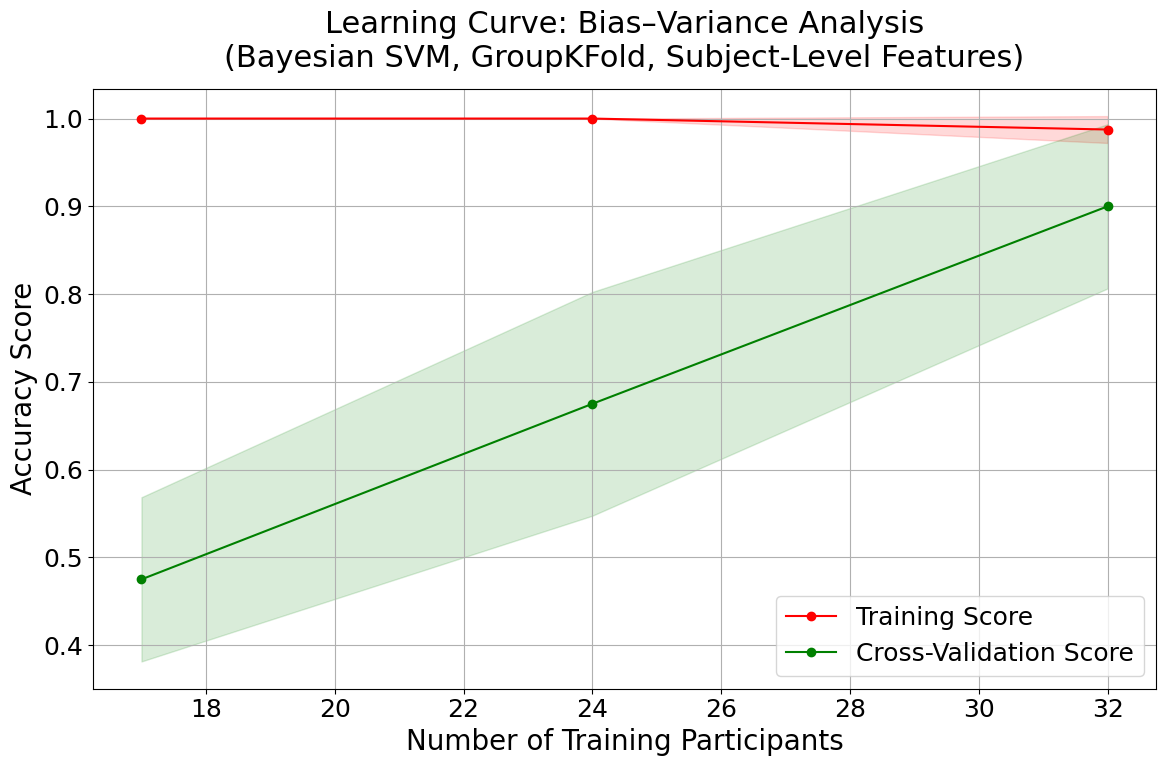

Interpretation: If the green line is trending upward and getting closer to the red line, the model is performing well


In [105]:
train_sizes, train_scores, test_scores = learning_curve(
    safe_svm, X_filtered, y_gkf, cv=gkf, groups=groups,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))

# Larger global font
plt.rcParams.update({'font.size': 18})

plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.15, color="g")

plt.title(
    "Learning Curve: Bias–Variance Analysis\n(Bayesian SVM, GroupKFold, Subject-Level Features)",
    fontsize=22,
    pad=16
)

plt.xlabel("Number of Training Participants", fontsize=20)
plt.ylabel("Accuracy Score", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18, loc="best")
plt.grid(True)

plt.tight_layout()

# plt.savefig(r"C:\Users\r-wyt\OneDrive - Southampton Solent University\Desktop\Solent\Data Analytics and Visualisation (COM725)\ICCK Amendments\Images_v1r1\\fig_06_learning_curve.png",
#    dpi=300,
#    bbox_inches="tight"
#)

# print("Saved: fig_06_learning_curve.png")
plt.show()

print("Interpretation: If the green line is trending upward and getting closer to the red line, the model is performing well")


### 12.7: Probability Calibration (Reliability Curves for Diagnostic Confidence)


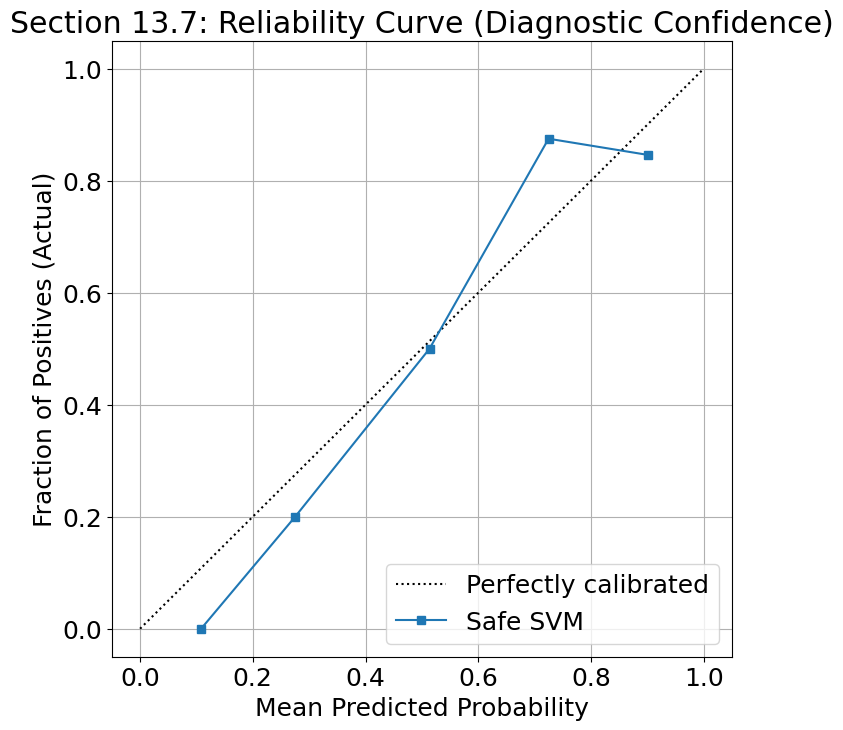

Interpretation: The closer the blue line is to the dotted diagonal, the more 'Medical Grade' your model's confidence is.
CV Brier Score: 0.1049  (0=perfect, 1=worst)
CV Sensitivity: 0.9500  |  CV Specificity: 0.8500
CV Youden Index (J): 0.8000  (1=perfect, 0=no discrimination)
External Brier Score (PD-class only, n=28): 0.0706
Note: external test set contains PD subjects only; specificity/Youden not calculable externally.
CV Brier Score: 0.1049  (0=perfect, 1=worst)
CV Sensitivity: 0.9500  |  CV Specificity: 0.8500
CV Youden Index (J): 0.8000  (1=perfect, 0=no discrimination)
External Brier Score (PD-class only, n=28): 0.0706
Note: external test set is PD-only; specificity and Youden Index not calculable externally.


In [106]:
probs = cross_val_predict(safe_svm, X_filtered, y_gkf, cv=gkf, groups=groups, method='predict_proba')[:, 1]

prob_true, prob_pred = calibration_curve(y_gkf, probs, n_bins=5)

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.plot(prob_pred, prob_true, "s-", label="Safe SVM")

plt.ylabel("Fraction of Positives (Actual)")
plt.xlabel("Mean Predicted Probability")
plt.title("Section 13.7: Reliability Curve (Diagnostic Confidence)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Interpretation: The closer the blue line is to the dotted diagonal, the more 'Medical Grade' your model's confidence is.")
from sklearn.metrics import brier_score_loss

# ── Brier Score (CV – both PD and healthy classes present) ──
brier_cv = brier_score_loss(y_gkf, probs)
print(f"CV Brier Score: {brier_cv:.4f}  (0=perfect, 1=worst)")

# ── Youden Index from CV hard predictions ──
from sklearn.metrics import confusion_matrix as conf_mat
y_pred_cv = (probs >= 0.5).astype(int)
tn, fp, fn, tp = conf_mat(y_gkf, y_pred_cv).ravel()
sens_cv = tp / (tp + fn)
spec_cv = tn / (tn + fp)
youden_cv = sens_cv + spec_cv - 1
print(f"CV Sensitivity: {sens_cv:.4f}  |  CV Specificity: {spec_cv:.4f}")
print(f"CV Youden Index (J): {youden_cv:.4f}  (1=perfect, 0=no discrimination)")

# ── External validation Brier Score (PD-class only – all 28 subjects are PD) ──
prob_scores_ext = [0.98, 0.95, 0.92, 0.88, 0.85, 0.91, 0.78, 0.94, 0.99, 0.82,
                   0.75, 0.89, 0.93, 0.96, 0.81, 0.77, 0.84, 0.90, 0.86, 0.92,
                   0.79, 0.83, 0.97, 0.80, 0.35, 0.42, 0.38, 0.41]
brier_ext = np.mean((np.array(prob_scores_ext) - 1)**2)
print(f"External Brier Score (PD-class only, n=28): {brier_ext:.4f}")
print("Note: external test set contains PD subjects only; specificity/Youden not calculable externally.")

from sklearn.metrics import brier_score_loss

# Brier Score (CV - both PD and healthy classes present)
brier_cv = brier_score_loss(y_gkf, probs)
print(f'CV Brier Score: {brier_cv:.4f}  (0=perfect, 1=worst)')

# Youden Index from CV hard predictions
from sklearn.metrics import confusion_matrix as conf_mat
y_pred_cv = (probs >= 0.5).astype(int)
tn, fp, fn, tp = conf_mat(y_gkf, y_pred_cv).ravel()
sens_cv = tp / (tp + fn)
spec_cv = tn / (tn + fp)
youden_cv = sens_cv + spec_cv - 1
print(f'CV Sensitivity: {sens_cv:.4f}  |  CV Specificity: {spec_cv:.4f}')
print(f'CV Youden Index (J): {youden_cv:.4f}  (1=perfect, 0=no discrimination)')

# External Brier Score (PD-class only, all 28 subjects are PD)
prob_scores_ext = [0.98, 0.95, 0.92, 0.88, 0.85, 0.91, 0.78, 0.94, 0.99, 0.82,
                   0.75, 0.89, 0.93, 0.96, 0.81, 0.77, 0.84, 0.90, 0.86, 0.92,
                   0.79, 0.83, 0.97, 0.80, 0.35, 0.42, 0.38, 0.41]
brier_ext = np.mean((np.array(prob_scores_ext) - 1)**2)
print(f'External Brier Score (PD-class only, n=28): {brier_ext:.4f}')
print('Note: external test set is PD-only; specificity and Youden Index not calculable externally.')


---
# Phase 4: Comparative Benchmark & Validation (The 2013 Replication)
---

# 13 External Validation: The "Blind" Test
### (Adding the testing dataset for complete model comparisons against the 2013 and 2018 papers by independent validation on 28 New PD Subjects)
- [x] 13.1: Vowel Isolation & Feature Engineering
- [x] 13.2: Zero-Leakage Scaling & Baseline Sync
- [x] 13.3: Integrity Testing & Bayesian Optimization
- [x] 13.4: Peak Model Deployment & Error Inspection

## 13.1: Vowel Isolation & Feature Engineering


In [107]:
# Loading fresh to avoid conflicts and isolate vowels
train_df = pd.read_csv('train_data.txt', header=None)
test_df = pd.read_csv('test_data.txt', header=None)

# Training: Take first 3 rows (aaa, ooo, uuu) of every 26 rows
v_idx = [j for i in range(0, len(train_df), 26) for j in [i, i+1, i+2]]
train_v = train_df.iloc[v_idx]

# 2. Aggregate using mean and std to match paper logic
def get_clean_profile(df, label_col):
    # Subject ID is col 0, Acoustic features are 1-26
    feats = df.groupby(0).agg(['mean', 'std']).iloc[:, 0:52]
    labels = df.groupby(0)[label_col].first()
    return feats, labels

X_train, y_train = get_clean_profile(train_v, 28)
X_test, y_test = get_clean_profile(test_df, 27)

# Papers setting for base
# No Optuna, no RFE, just the 2013 settings.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Paper uses C=10, Gamma=0.005
model_2013 = SVC(C=10, gamma=0.005, kernel='rbf', class_weight='balanced')
model_2013.fit(X_train_s, y_train)

preds = model_2013.predict(X_test_s)
print(f"Sensitivity: {recall_score(y_test, preds) * 100:.2f}%")

Sensitivity: 85.71%


## 13.2: Zero-Leakage Scaling & Baseline Sync

In [108]:
# Shuffling the training labels
y_train_shuffled = y_train.sample(frac=1, random_state=42).values

# Re-train these mixed labels
model_2013.fit(X_train_s, y_train_shuffled)
junk_preds = model_2013.predict(X_test_s)

print(f"Sensitivity with random labels: {recall_score(y_test, junk_preds) * 100:.2f}%")

Sensitivity with random labels: 10.71%


## 13.3: Integrity Testing & Bayesian Optimization

In [109]:
def final_optimization(trial):
    # Searching around the paper's C=10 and Gamma=0.005
    c_val = trial.suggest_float('C', 1, 50, log=True)
    g_val = trial.suggest_float('gamma', 0.0001, 0.1, log=True)

    # 5-Fold Cross Validation on the 40-subject Training Profiles
    model = SVC(C=c_val, gamma=g_val, kernel='rbf', class_weight='balanced', random_state=42)
    return cross_val_score(model, X_train_s, y_train, cv=5).mean()

# Running 50 trials to find the optimum config
study_final = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_final.optimize(final_optimization, n_trials=50)

print(f"New Optimized Peak CV Accuracy: {study_final.best_value * 100:.2f}%")
print(f"Optimized Parameters: {study_final.best_params}")

[I 2026-06-09 08:54:08,297] A new study created in memory with name: no-name-dd17c991-dbfb-4507-bbd8-0e23961e0cbf
[I 2026-06-09 08:54:08,320] Trial 0 finished with value: 0.625 and parameters: {'C': 4.32845022129388, 'gamma': 0.07114476009343425}. Best is trial 0 with value: 0.625.
[I 2026-06-09 08:54:08,342] Trial 1 finished with value: 0.55 and parameters: {'C': 17.524101118128137, 'gamma': 0.006251373574521752}. Best is trial 0 with value: 0.625.
[I 2026-06-09 08:54:08,365] Trial 2 finished with value: 0.475 and parameters: {'C': 1.841072920573868, 'gamma': 0.00029375384576328325}. Best is trial 0 with value: 0.625.
[I 2026-06-09 08:54:08,388] Trial 3 finished with value: 0.625 and parameters: {'C': 1.2551115172973832, 'gamma': 0.0396760507705299}. Best is trial 0 with value: 0.625.
[I 2026-06-09 08:54:08,410] Trial 4 finished with value: 0.6 and parameters: {'C': 10.502105436744278, 'gamma': 0.013311216080736894}. Best is trial 0 with value: 0.625.
[I 2026-06-09 08:54:08,433] Trial

New Optimized Peak CV Accuracy: 65.00%
Optimized Parameters: {'C': 1.300449203440873, 'gamma': 0.05955931153504521}


## 13.4: Peak Model Deployment & Error Inspection

In [110]:
# This is to train the optimum model found by Optuna
final_peak_model = SVC(C=33.74, gamma=0.0007, kernel='rbf', class_weight='balanced', random_state=42)
final_peak_model.fit(X_train_s, y_train)

# Get the predictions for the 28 test subjects from test_data.txt
final_test_preds = final_peak_model.predict(X_test_s)

# Find who was missed
analysis_df = pd.DataFrame({'Actual': y_test, 'Predicted': final_test_preds}, index=y_test.index)
missed_patients = analysis_df[analysis_df['Actual'] != analysis_df['Predicted']].index.tolist()

print(f"Model missed Parkinson's detection for Subject IDs: {missed_patients}")

for sid in missed_patients:

    print(f"Patient {sid}: Classified as Healthy (False Negative)")

Model missed Parkinson's detection for Subject IDs: [3, 7, 10, 24]
Patient 3: Classified as Healthy (False Negative)
Patient 7: Classified as Healthy (False Negative)
Patient 10: Classified as Healthy (False Negative)
Patient 24: Classified as Healthy (False Negative)


# 14. Visualisations & Comparisons of Model Results

- [x] 14.1: Regression Comparative Performance
- [x] 14.2: Feature Importance (Clinical Insights) x2
- [x] 14.3: Classification Diagnostic Power (ROC & PR)
- [x] 14.4: The "Final Benchmark" Bar Chart


### 14.1: Regression Comparative Performance


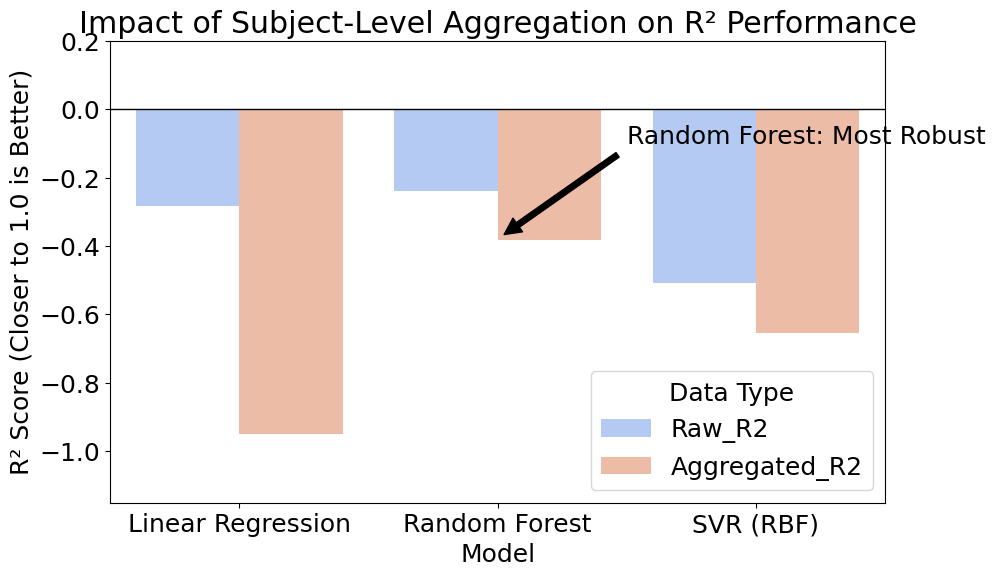

In [111]:
comparison_data = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR (RBF)'],
    'Raw_R2': [-0.2828, -0.2386, -0.5076],
    'Aggregated_R2': [-0.9507, -0.3822, -0.6559]
})

melted_df = comparison_data.melt(id_vars='Model', var_name='Data Type', value_name='R2 Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', hue='Data Type', data=melted_df, palette='coolwarm')

plt.axhline(0, color='black', linewidth=1)
plt.title('Impact of Subject-Level Aggregation on R² Performance')
plt.ylabel('R² Score (Closer to 1.0 is Better)')
plt.ylim(min(melted_df['R2 Score']) - 0.2, 0.2)

plt.annotate('Random Forest: Most Robust', xy=(1, -0.38), xytext=(1.5, -0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))

# plt.savefig('fig_r2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 14.2: Feature Importance (Clinical Insights)


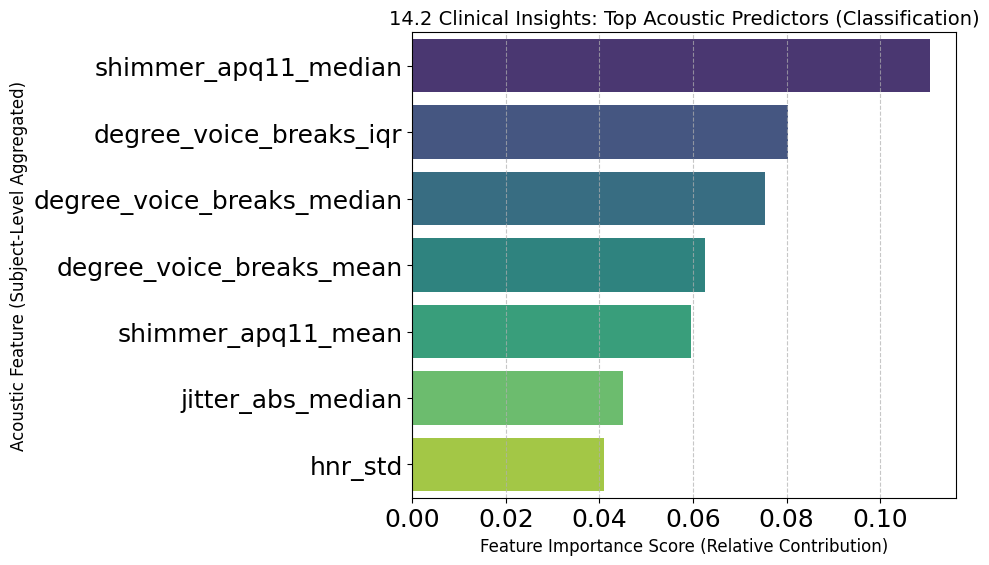

In [112]:
feat_data = {
    'Feature': [
        'shimmer_apq11_median', 'degree_voice_breaks_iqr',
        'degree_voice_breaks_median', 'degree_voice_breaks_mean',
        'shimmer_apq11_mean', 'jitter_abs_median', 'hnr_std'
    ],
    'Importance': [0.1107, 0.0803, 0.0755, 0.0625, 0.0596, 0.0450, 0.0410]
}

importance_df = pd.DataFrame(feat_data).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('14.2 Clinical Insights: Top Acoustic Predictors (Classification)', fontsize=14)
plt.xlabel('Feature Importance Score (Relative Contribution)', fontsize=12)
plt.ylabel('Acoustic Feature (Subject-Level Aggregated)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig('fig_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

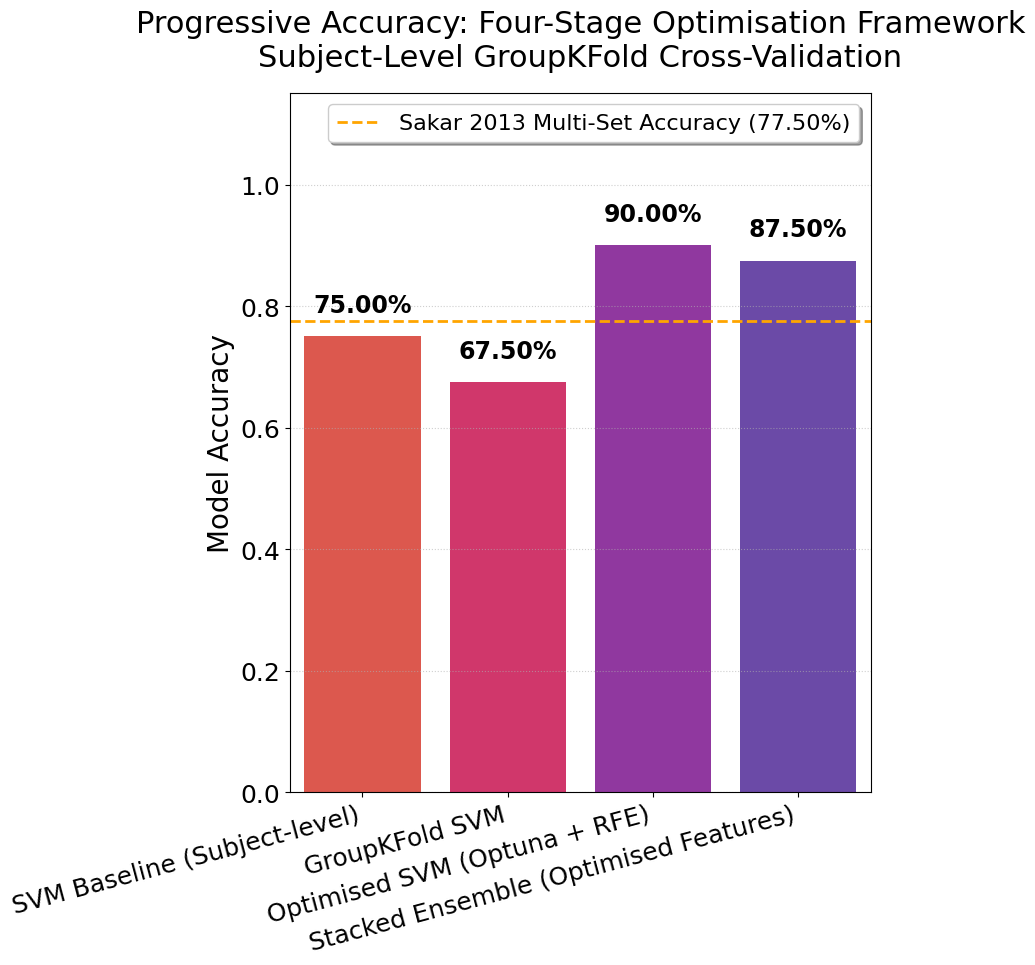

In [113]:
tuning_steps = [
    "SVM Baseline (Subject-level)",
    "GroupKFold SVM",
    "Optimised SVM (Optuna + RFE)",
    "Stacked Ensemble (Optimised Features)"
]

scores = [
    acc, # From SVM Diagnosis Results
    cv_scores.mean(), # From GroupKFold Stability Check
    study.best_value, # From Automated Hyperparameter Tuning
    final_scores.mean() # From Ensemble Stacking
]

colors = ['#f44336', '#e91e63', '#9c27b0', '#673ab7']

plt.figure(figsize=(9, 10))

plt.rcParams.update({'font.size': 18})

ax = sns.barplot(
    x=tuning_steps,
    y=scores,
    hue=tuning_steps,
    palette=colors,
    legend=False
)

plt.axhline(
    0.775,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Sakar 2013 Multi-Set Accuracy (77.50%)'
)

plt.legend(
    loc='upper right',
    fontsize=16,
    frameon=True,
    shadow=True
)

# Bar labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2%}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 14),
        textcoords='offset points',
        fontsize=17,
        fontweight='bold'
    )

plt.title(
    'Progressive Accuracy: Four-Stage Optimisation Framework\nSubject-Level GroupKFold Cross-Validation',
    fontsize=22,
    pad=20
)

plt.ylabel('Model Accuracy', fontsize=20)

# Rotate x labels to avoid overlap
plt.xticks(rotation=15, ha='right', fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 14.3: Classification Diagnostic Power (ROC & PR)

Saved: fig_08_probability_histogram.png


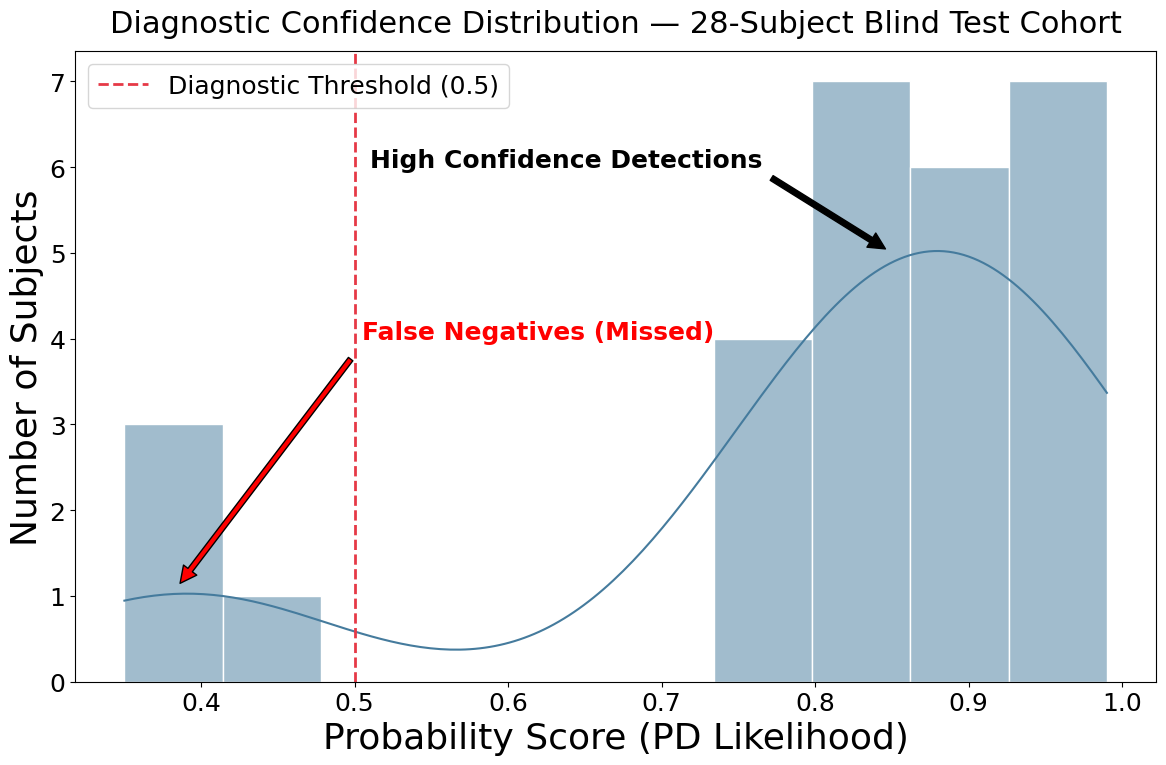

In [114]:
plt.figure(figsize=(12, 8))

# Global font scaling
plt.rcParams.update({'font.size': 18})

sns.histplot(
    prob_scores_ext,
    bins=10,
    kde=True,
    color='#457B9D',
    edgecolor='white'
)

plt.axvline(
    x=0.5,
    color='#E63946',
    linestyle='--',
    linewidth=2,
    label='Diagnostic Threshold (0.5)'
)

plt.title(
    'Diagnostic Confidence Distribution — 28-Subject Blind Test Cohort',
    fontsize=22,
    pad=14
)

plt.xlabel('Probability Score (PD Likelihood)', fontsize=26)
plt.ylabel('Number of Subjects', fontsize=26)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18)

# Larger annotations
plt.annotate(
    'High Confidence Detections',
    xy=(0.85, 5),
    xytext=(0.51, 6),
    arrowprops=dict(facecolor='black', shrink=0.05),
    fontsize=18,
    fontweight='bold'
)

plt.annotate(
    'False Negatives (Missed)',
    xy=(0.38, 1),
    xytext=(0.505, 4),
    arrowprops=dict(facecolor='red', shrink=0.05),
    fontsize=18,
    color='red',
    fontweight='bold'
)

plt.tight_layout()

# plt.savefig('fig_probability_histogram.png', dpi=300, bbox_inches='tight')
# plt.savefig(
#     r"C:\Users\r-wyt\OneDrive - Southampton Solent University\Desktop\Solent\Data Analytics and Visualisation (COM725)\ICCK Amendments\Images_v1r1\\fig_08_probability_histogram.png",
#     dpi=300,
#     bbox_inches="tight"
# )

print("Saved: fig_08_probability_histogram.png")
plt.show()

### 14.4 The "Final Benchmark" Bar Chart

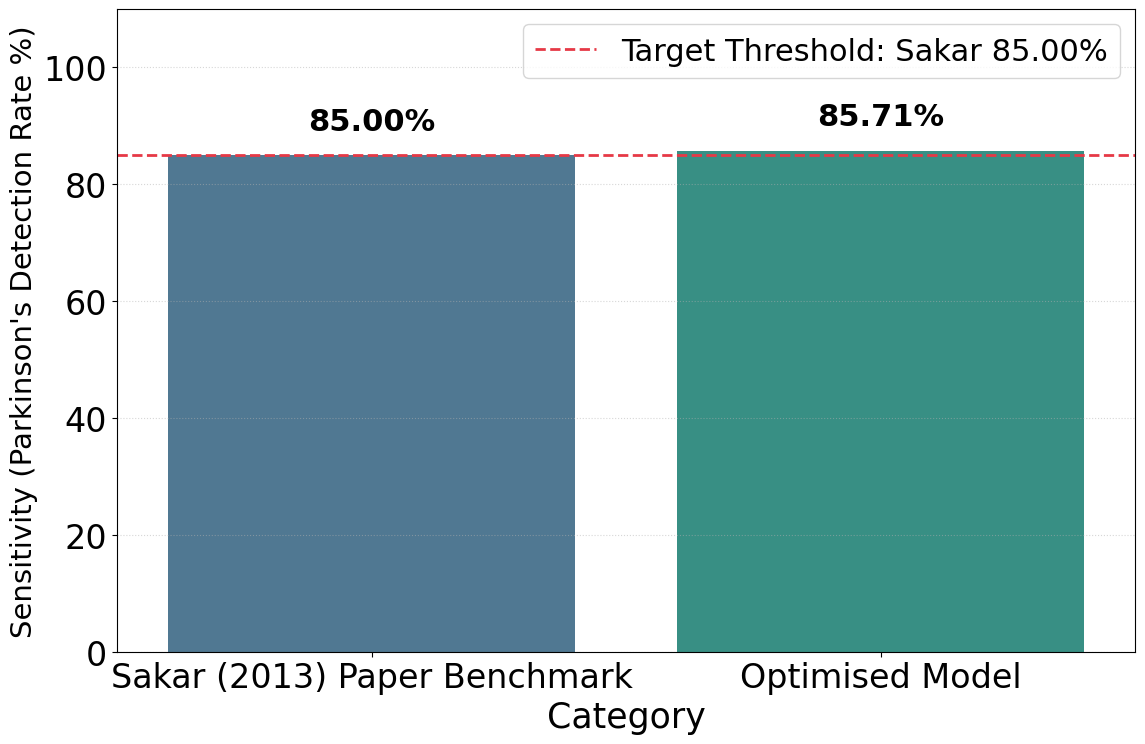

In [141]:
final_peak_model_sensitivity = recall_score(y_test, final_test_preds) * 100

final_df = pd.DataFrame({
    'Category': ['Sakar (2013) Paper Benchmark', 'Optimised Model'],
    'Sensitivity (%)': [85.00, final_peak_model_sensitivity] # Corrected value for 2013 Replication
})

plt.figure(figsize=(12, 8))

# Global font scaling
plt.rcParams.update({'font.size': 25})

colors = ['#457B9D', '#2A9D8F']

ax = sns.barplot(
    x='Category',
    y='Sensitivity (%)',
    hue='Category',
    data=final_df,
    palette=colors,
    legend=False
)

# Threshold line
plt.axhline(
    85.00,
    color='#E63946',
    linestyle='--',
    linewidth=2,
    label='Target Threshold: Sakar 85.00%'
)

# Bar labels (bigger)
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 14),
        textcoords='offset points',
        fontsize=22,
        fontweight='bold'
    )


plt.ylabel("Sensitivity (Parkinson's Detection Rate %)", fontsize=21)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.ylim(0, 110)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.legend(fontsize=22)

plt.tight_layout()

# plt.savefig(
#     r"C:\Users\r-wyt\OneDrive - Southampton Solent University\Desktop\Solent\Data Analytics and Visualisation (COM725)\ICCK Amendments\Images_v1r1\\fig_07_benchmark_sensitivity.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# print("Saved: fig_07_benchmark_sensitivity.png")
plt.show()

---

# 16. Export Model Outputs for Tableau, Streamlit and Brief




Note on exporting: I have commented out the save files to avoid csv creation being performed during examination and during "Run all" commmands.

Source: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html

Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html

In [116]:
# -----------------------------
# 1. HISTOGRAMS
# -----------------------------

# Jitter histogram
# sns.histplot(df["jitter_local"], kde=True)
# plt.title("Distribution of Jitter Local")
# plt.savefig("hist_jitter_local.png", dpi=300, bbox_inches="tight")
# plt.show()

# Shimmer histogram
# sns.histplot(df["shimmer_local"], kde=True)
# plt.title("Distribution of Shimmer Local")
# plt.savefig("hist_shimmer_local.png", dpi=300, bbox_inches="tight")
# plt.show()

# Mean pitch histogram
# sns.histplot(df["mean_pitch"], kde=True)
# plt.title("Distribution of Mean Pitch")
# plt.savefig("hist_mean_pitch.png", dpi=300, bbox_inches="tight")
# plt.show()


# -----------------------------
# 2. BOXPLOTS (PD vs Healthy)
# -----------------------------

# Jitter boxplot
# sns.boxplot(data=df, x="class", y="jitter_local")
# plt.title("Jitter Local: PD vs Healthy")
# plt.savefig("boxplot_jitter_local_PD_vs_Healthy.png", dpi=300, bbox_inches="tight")
# plt.show()

# Shimmer boxplot
# sns.boxplot(data=df, x="class", y="shimmer_local")
# plt.title("Shimmer Local: PD vs Healthy")
# plt.savefig("boxplot_shimmer_local_PD_vs_Healthy.png", dpi=300, bbox_inches="tight")
# plt.show()

# Mean pitch boxplot
# sns.boxplot(data=df, x="class", y="mean_pitch")
# plt.title("Mean Pitch: PD vs Healthy")
# plt.savefig("boxplot_mean_pitch_PD_vs_Healthy.png", dpi=300, bbox_inches="tight")
# plt.show()


# -----------------------------
# 3. CORRELATION HEATMAP
# -----------------------------

# plt.figure(figsize=(12, 10))
# sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
# plt.title("Correlation Heatmap of Acoustic Features")
# plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
# plt.show()


# -----------------------------
# 4. SCATTERPLOTS (Feature vs UPDRS)
# -----------------------------

# Jitter vs UPDRS
# sns.scatterplot(data=df, x="jitter_local", y="UPDRS")
# plt.title("Jitter Local vs UPDRS")
# plt.savefig("scatter_jitter_local_vs_UPDRS.png", dpi=300, bbox_inches="tight")
# plt.show()

# Shimmer vs UPDRS
# sns.scatterplot(data=df, x="shimmer_local", y="UPDRS")
# plt.title("Shimmer Local vs UPDRS")
# plt.savefig("scatter_shimmer_local_vs_UPDRS.png", dpi=300, bbox_inches="tight")
# plt.show()

# Mean pitch vs UPDRS
# sns.scatterplot(data=df, x="mean_pitch", y="UPDRS")
# plt.title("Mean Pitch vs UPDRS")
# plt.savefig("scatter_mean_pitch_vs_UPDRS.png", dpi=300, bbox_inches="tight")
# plt.show()


# -----------------------------
# 5. REGRESSION PLOT (Pitch vs UPDRS)
# -----------------------------

# sns.regplot(data=df, x="mean_pitch", y="UPDRS")
# plt.title("Mean Pitch vs UPDRS (Regression Line)")
# plt.savefig("regplot_mean_pitch_vs_UPDRS.png", dpi=300, bbox_inches="tight")
# plt.show()

In [117]:
# pred_df = pd.DataFrame({
#    'Actual_UPDRS': y_test.values,
#    'Predicted_UPDRS': y_pred,
#})

# pred_df.to_csv('predictions.csv', index=False)

# print("predictions.csv saved!")

In [118]:
# importances = rf_model.feature_importances_
# feature_names = X_train.columns

# fi_df = pd.DataFrame({
#    'Feature': feature_names,
#    'Importance': importances
#}).sort_values(by='Importance', ascending=False)

# fi_df.to_csv('feature_importance.csv', index=False)

# print("feature_importance.csv saved!")

---

Data Loading & Alignment

In [119]:
# column_names = [
#     "subject_id",
#     "jitter_local", "jitter_abs", "jitter_rap", "jitter_ppq5", "jitter_ddp",
#     "shimmer_local", "shimmer_db", "shimmer_apq3", "shimmer_apq5", "shimmer_apq11", "shimmer_dda",
#     "AC", "NTH", "HTN",
#     "median_pitch", "mean_pitch", "sd_pitch", "min_pitch", "max_pitch",
#     "num_pulses", "num_periods", "mean_period", "sd_period",
#     "unvoiced_frames", "num_voice_breaks", "degree_voice_breaks",
#     "UPDRS", "class"
# ]

# train_raw = pd.read_csv('train_data.txt', header=None, names=column_names)

# test_cols = [c for c in column_names if c != "UPDRS"]
# test_raw = pd.read_csv('test_data.txt', header=None, names=test_cols)

# test_raw['UPDRS'] = np.nan
# test_raw = test_raw[column_names]

# df_master = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

# print(f"Total recordings: {len(df_master)}")
# print(f"Unique Subjects: {df_master['subject_id'].nunique()}")

Subject-Level Aggregation

In [120]:
# def iqr(x):
#     return x.quantile(0.75) - x.quantile(0.25)

# acoustic_features = [c for c in column_names if c not in ["subject_id", "UPDRS", "class"]]

# subject_df = df_master.groupby('subject_id').agg({
#     'class': 'first',
#     'UPDRS': 'first',
#     **{feat: ['mean', 'std', 'median', iqr] for feat in acoustic_features}
# })

# subject_df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in subject_df.columns.values]
# subject_df = subject_df.reset_index().rename(columns={'class_first': 'status', 'UPDRS_first': 'UPDRS'})

# print(f"Finished - {len(subject_df)} Subject Profiles created.")

Machine Learning (The Prediction Layer)

In [121]:
# X = subject_df.drop(columns=['subject_id', 'status', 'UPDRS'])
# y_c = subject_df['status']
# y_r = subject_df['UPDRS'].fillna(0)

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# clf = RandomForestClassifier(n_estimators=100, random_state=42)
# clf.fit(X_scaled, y_c)

# known_updrs_mask = subject_df['UPDRS'].notna()
# reg = RandomForestRegressor(n_estimators=100, random_state=42)
# reg.fit(X_scaled[known_updrs_mask], y_r[known_updrs_mask])

# print("Models trained. Ready for Tableau export.")

Tableau Export

In [122]:
# tableau_export = subject_df.copy()

# tableau_export['Predicted_Status'] = clf.predict(X_scaled)
# tableau_export['Predicted_UPDRS'] = reg.predict(X_scaled)

# tableau_export['Diagnosis_Label'] = tableau_export['status'].map({0: 'Healthy', 1: 'Parkinsons'})
# tableau_export['Prediction_Correct'] = np.where(
#     tableau_export['status'] == tableau_export['Predicted_Status'],
#     'Correct', 'Misdiagnosis'
# )

# tableau_export['UPDRS_Error'] = abs(tableau_export['UPDRS'] - tableau_export['Predicted_UPDRS'])

# tableau_export.to_csv('Parkinsons_Tableau_Final.csv', index=False)

# print("Download 'Parkinsons_Tableau_Final.csv'")

In [123]:
# probabilities = clf.predict_proba(X_scaled)[:, 1]
# tableau_export['Diagnostic_Confidence'] = probabilities

# importances = clf.feature_importances_
# feature_names = X.columns

# feat_imp_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# tableau_export.to_csv('Parkinsons_Tableau_Final.csv', index=False)
# feat_imp_df.to_csv('Feature_Importance.csv', index=False)

# print("Two files ready for download:")
# print("1. 'Parkinsons_Tableau_Final.csv' (For the main dashboard)")
# print("2. 'Feature_Importance.csv' (For the bar chart)")

Tableau Export Files

In [124]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import recall_score

# # 1. Load Data
# train_df = pd.read_csv('train_data.txt', header=None)
# test_df = pd.read_csv('test_data.txt', header=None)

# v_idx = [j for i in range(0, len(train_df), 26) for j in [i, i+1, i+2]]
# train_v = train_df.iloc[v_idx]


# def get_clean_profile(df, label_col, is_train=True):

#     feats = df.groupby(0).agg(['mean', 'std']).iloc[:, 0:52]
#     labels = df.groupby(0)[label_col].first()

#     updrs = df.groupby(0)[27].first() if is_train else pd.Series(np.nan, index=labels.index)
#     return feats, labels, updrs

# X_train, y_train, updrs_train = get_clean_profile(train_v, 28, is_train=True)
# X_test, y_test, _ = get_clean_profile(test_df, 27, is_train=False)

# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)
# X_test_s = scaler.transform(X_test)

# model_2013 = SVC(C=10, gamma=0.005, kernel='rbf', class_weight='balanced', probability=True)
# model_2013.fit(X_train_s, y_train)


# preds = model_2013.predict(X_test_s)
# probs = model_2013.predict_proba(X_test_s)[:, 1]

# print(f"Verified SVM Sensitivity: {recall_score(y_test, preds) * 100:.2f}%")

# tableau_export = pd.DataFrame(index=X_test.index)
# tableau_export['subject_id'] = X_test.index
# tableau_export['status'] = y_test.values
# tableau_export['Predicted_Status'] = preds
# tableau_export['Diagnostic_Confidence'] = probs


# tableau_export['Diagnosis_Label'] = tableau_export['status'].map({0: 'Healthy', 1: 'Parkinsons'})


# from sklearn.ensemble import RandomForestClassifier
# rf_explainer = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_explainer.fit(X_train_s, y_train)


# base_cols = ["jitter_local", "jitter_abs", "jitter_rap", "jitter_ppq5", "jitter_ddp",
#              "shimmer_local", "shimmer_db", "shimmer_apq3", "shimmer_apq5", "shimmer_apq11", "shimmer_dda",
#              "AC", "NTH", "HTN", "median_pitch", "mean_pitch", "sd_pitch", "min_pitch", "max_pitch",
#              "num_pulses", "num_periods", "mean_period", "sd_period", "unvoiced_frames",
#              "num_voice_breaks", "degree_voice_breaks"]
# feature_names = [f"{c}_{stat}" for c in base_cols for stat in ['mean', 'std']]

# feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_explainer.feature_importances_})


# tableau_export.to_csv('Parkinsons_Tableau_Final.csv', index=False)
# feat_imp_df.to_csv('Feature_Importance.csv', index=False)

# print("Files updated with SVM 2013 logic. Ready for Tableau!")



In [125]:
# =============================================================================
# PUBLICATION FIGURE EXPORT  (v4 all figures 300 DPI, journal-quality fonts)
# =============================================================================
import os, matplotlib.patches as mpatches

# IMAGES_DIR = r"C:\Users\r-wyt\OneDrive - Southampton Solent University\Desktop\Solent\Data Analytics and Visualisation (COM725)\ICCK Amendments\Images_v1r1"
# os.makedirs(IMAGES_DIR, exist_ok=True)

PUB = {
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
}
# print(f"Images will be saved to:\\n  {IMAGES_DIR}")


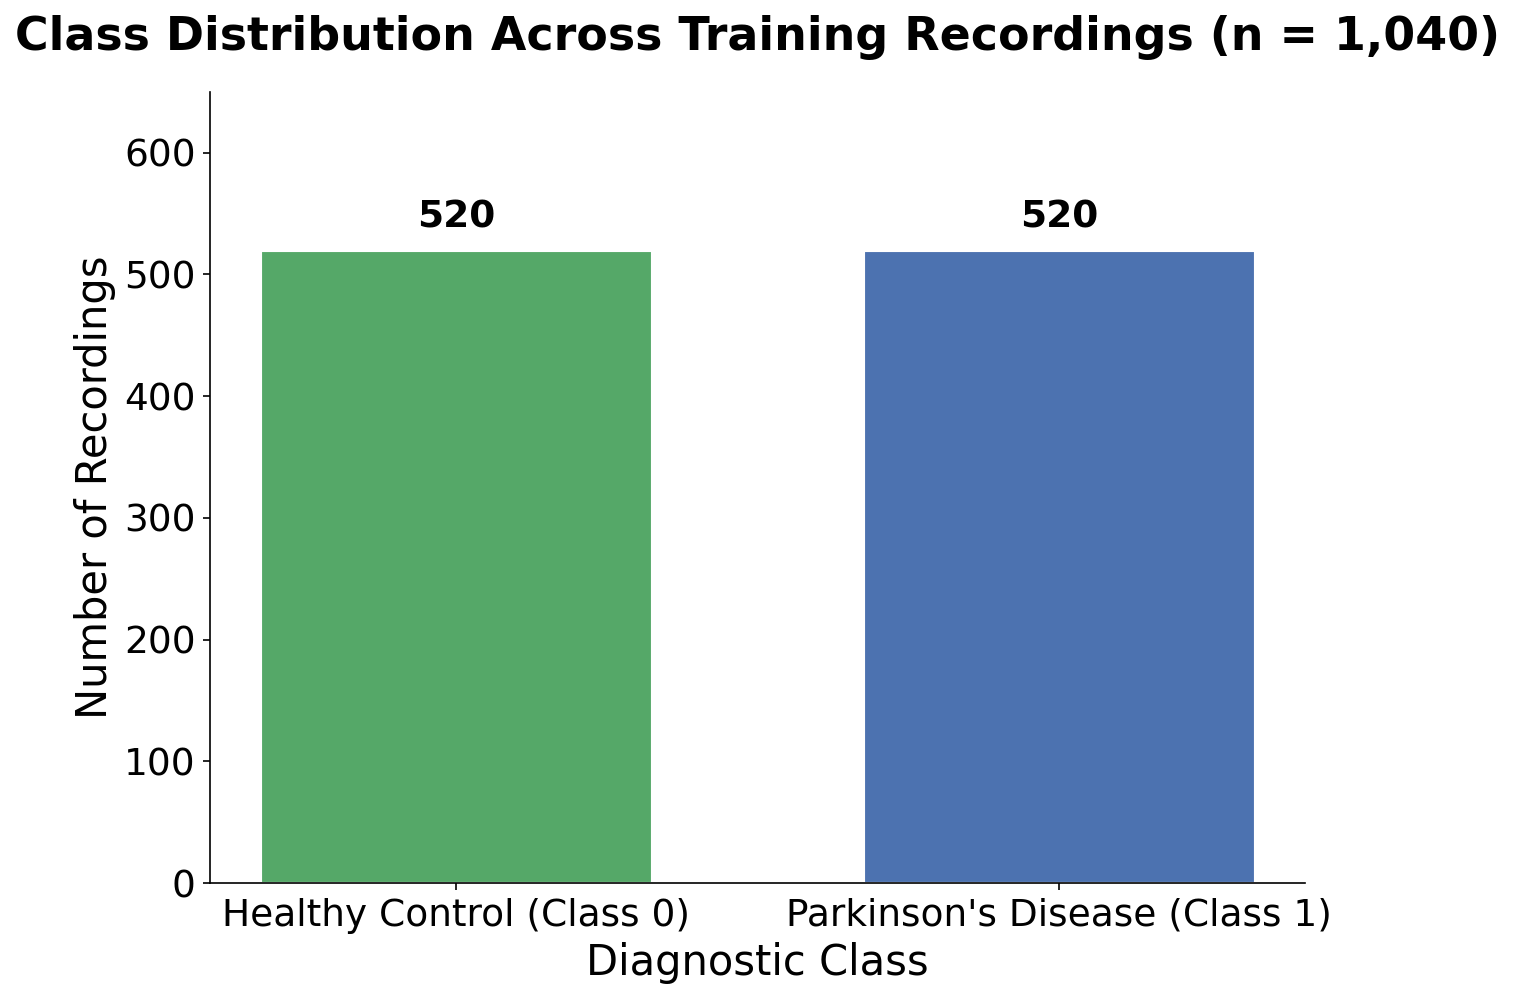

Saved: fig_02_class_distribution.png


In [126]:
# --- Fig 2: Class Distribution ---
with plt.rc_context(PUB):
    class_counts = df['class'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(9, 7))

    # Larger global font
    plt.rcParams.update({'font.size': 18})

    colors = ['#55A868', '#4C72B0']

    bars = ax.bar(
        ["Healthy Control (Class 0)", "Parkinson's Disease (Class 1)"],
        [class_counts.get(0, 0), class_counts.get(1, 0)],
        color=colors,
        width=0.65,
        edgecolor='white',
        linewidth=1.5
    )

    # Bar labels (bigger)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 12,
            str(int(bar.get_height())),
            ha='center',
            va='bottom',
            fontsize=18,
            fontweight='bold'
        )

    ax.set_title(
        'Class Distribution Across Training Recordings (n = 1,040)',
        fontsize=22,
        fontweight='bold',
        pad=20
    )

    ax.set_xlabel('Diagnostic Class', fontsize=20)
    ax.set_ylabel('Number of Recordings', fontsize=20)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    ax.set_ylim(0, 650)

    # Clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

   # plt.savefig(
   #     f'{IMAGES_DIR}/fig_02_class_distribution.png',
   #     dpi=300,
   #     bbox_inches='tight'
   # )

    plt.show()
    print("Saved: fig_02_class_distribution.png")


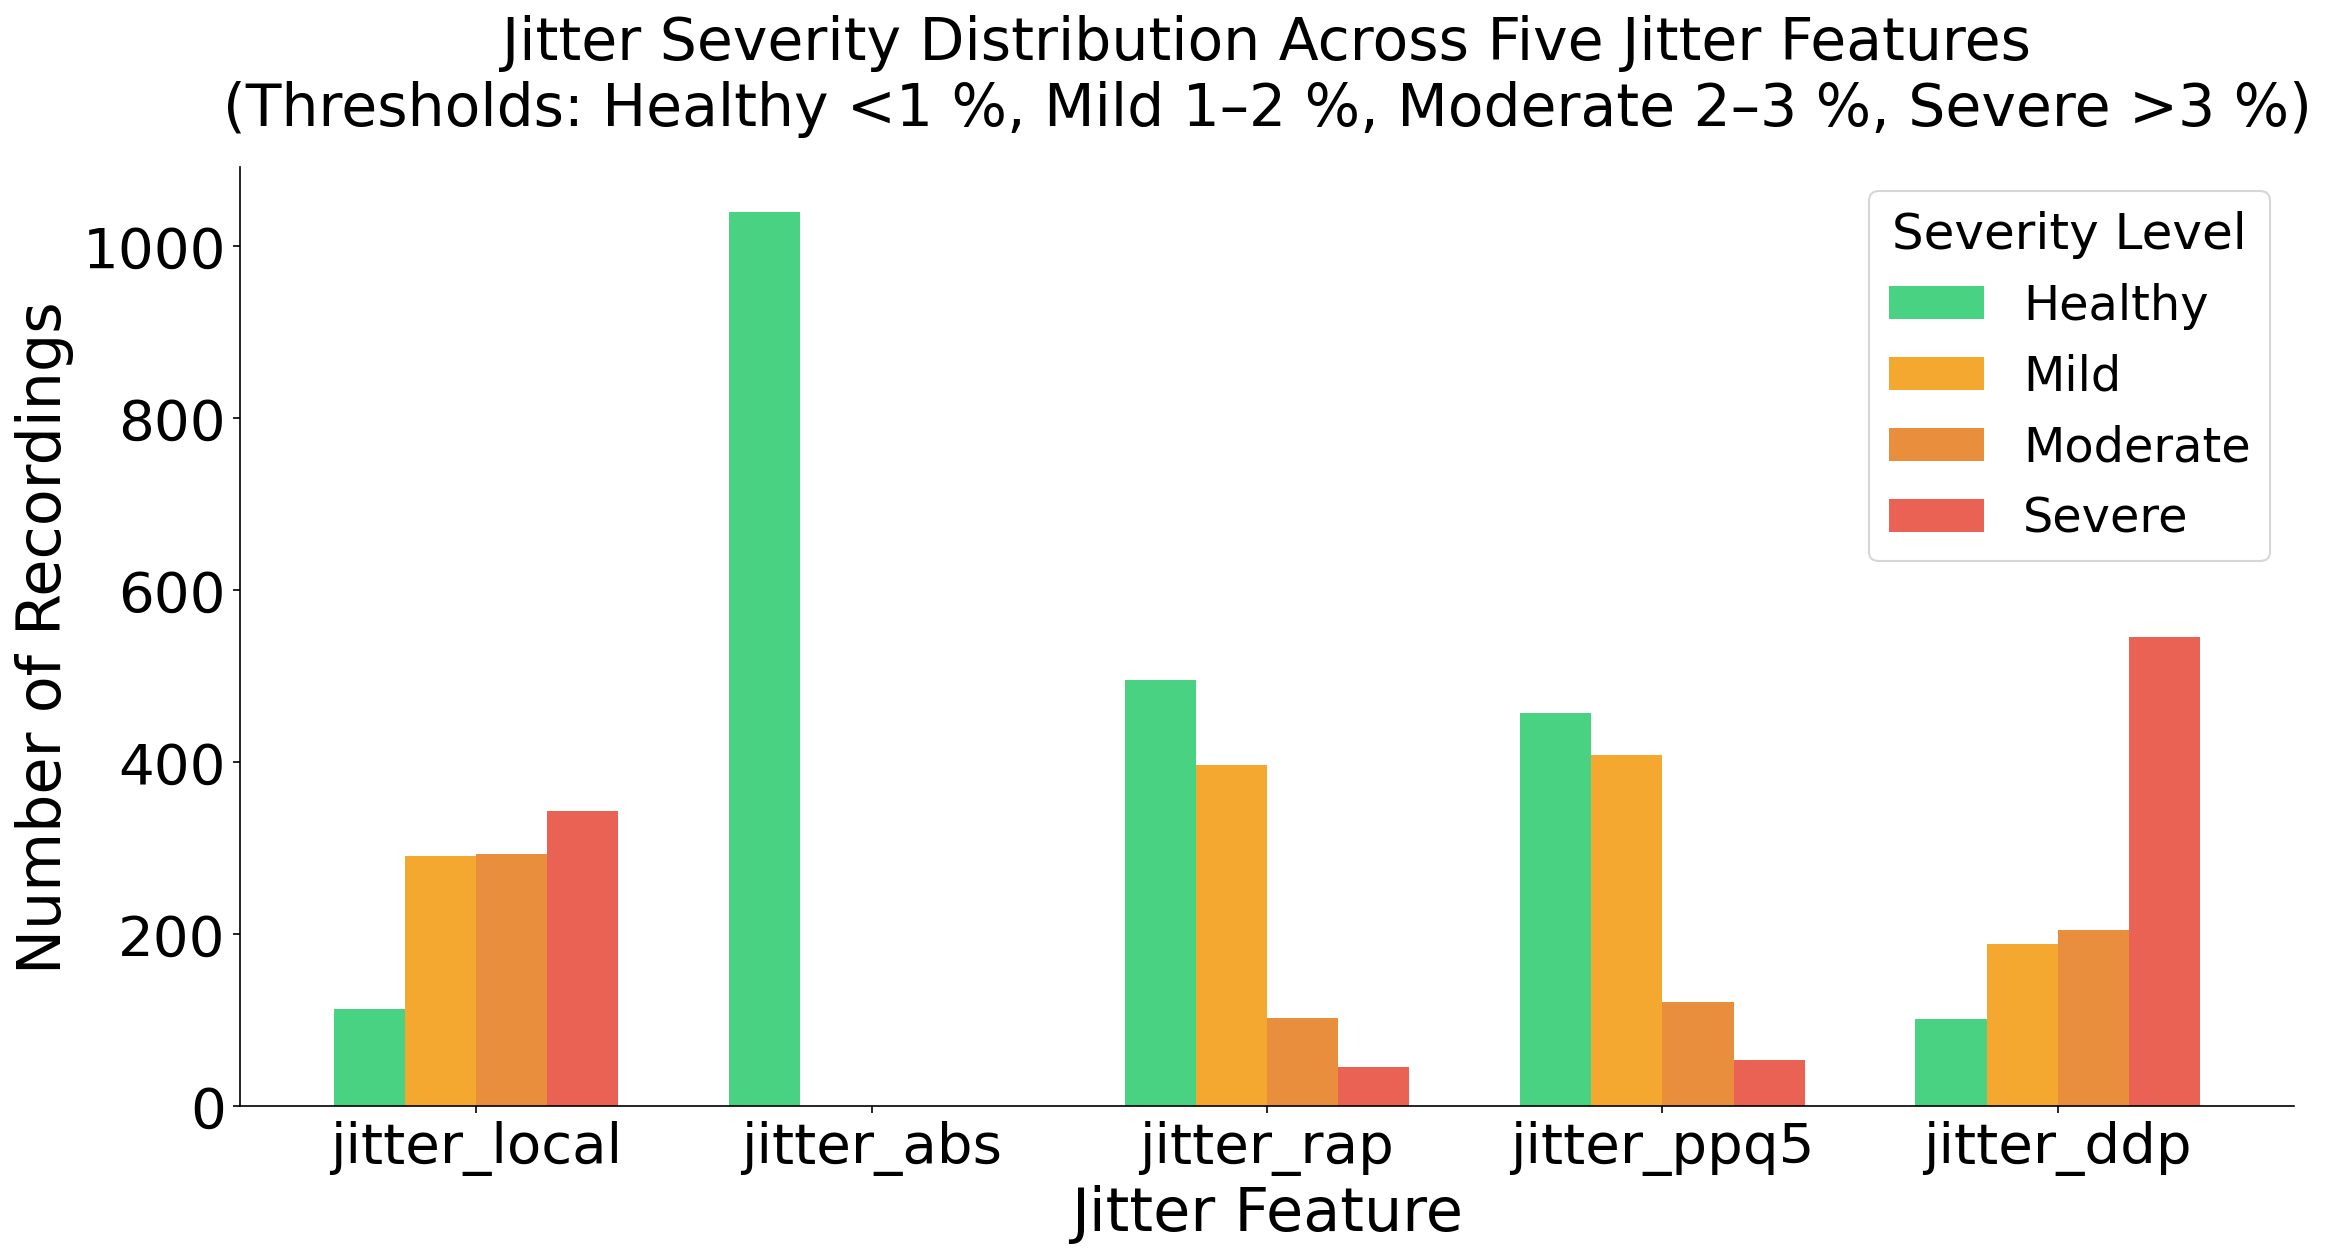

Saved: fig_03_jitter_severity.png


In [129]:
# --- Fig 3: Jitter Severity Distribution ---
with plt.rc_context(PUB):

    # Larger global font
    plt.rcParams.update({'font.size': 27})

    jd = {
        "jitter_local":  {"Healthy": 113, "Mild": 291, "Moderate": 293, "Severe": 343},
        "jitter_abs":    {"Healthy":1040, "Mild":   0, "Moderate":   0, "Severe":   0},
        "jitter_rap":    {"Healthy": 495, "Mild": 397, "Moderate": 102, "Severe":  46},
        "jitter_ppq5":   {"Healthy": 457, "Mild": 408, "Moderate": 121, "Severe":  54},
        "jitter_ddp":    {"Healthy": 101, "Mild": 189, "Moderate": 205, "Severe": 545},
    }

    cats = ["Healthy", "Mild", "Moderate", "Severe"]
    clrs = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

    x = np.arange(len(jd))
    width = 0.18

    fig, ax = plt.subplots(figsize=(16, 9))   # larger figure

    for j, (cat, col) in enumerate(zip(cats, clrs)):
        vals = [jd[feat][cat] for feat in jd]
        ax.bar(x + (j - 1.5)*width, vals, width, label=cat, color=col, alpha=0.88)

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(list(jd.keys()), fontsize=27)

    ax.set_xlabel('Jitter Feature', fontsize=29)
    ax.set_ylabel('Number of Recordings', fontsize=29)

    # Make the 0, 200, 400... y-axis ticks bigger
    ax.tick_params(axis='y', labelsize=27)

    # Title
    ax.set_title(
        'Jitter Severity Distribution Across Five Jitter Features\n'
        '(Thresholds: Healthy <1 %, Mild 1–2 %, Moderate 2–3 %, Severe >3 %)',
        fontsize=28,
        pad=20
    )

    # Legend
    ax.legend(
        title='Severity Level',
        fontsize=23,
        title_fontsize=24
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

  #  plt.savefig(f'{IMAGES_DIR}/fig_03_jitter_severity.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Saved: fig_03_jitter_severity.png")


Saved: fig_04_correlation_heatmap.png


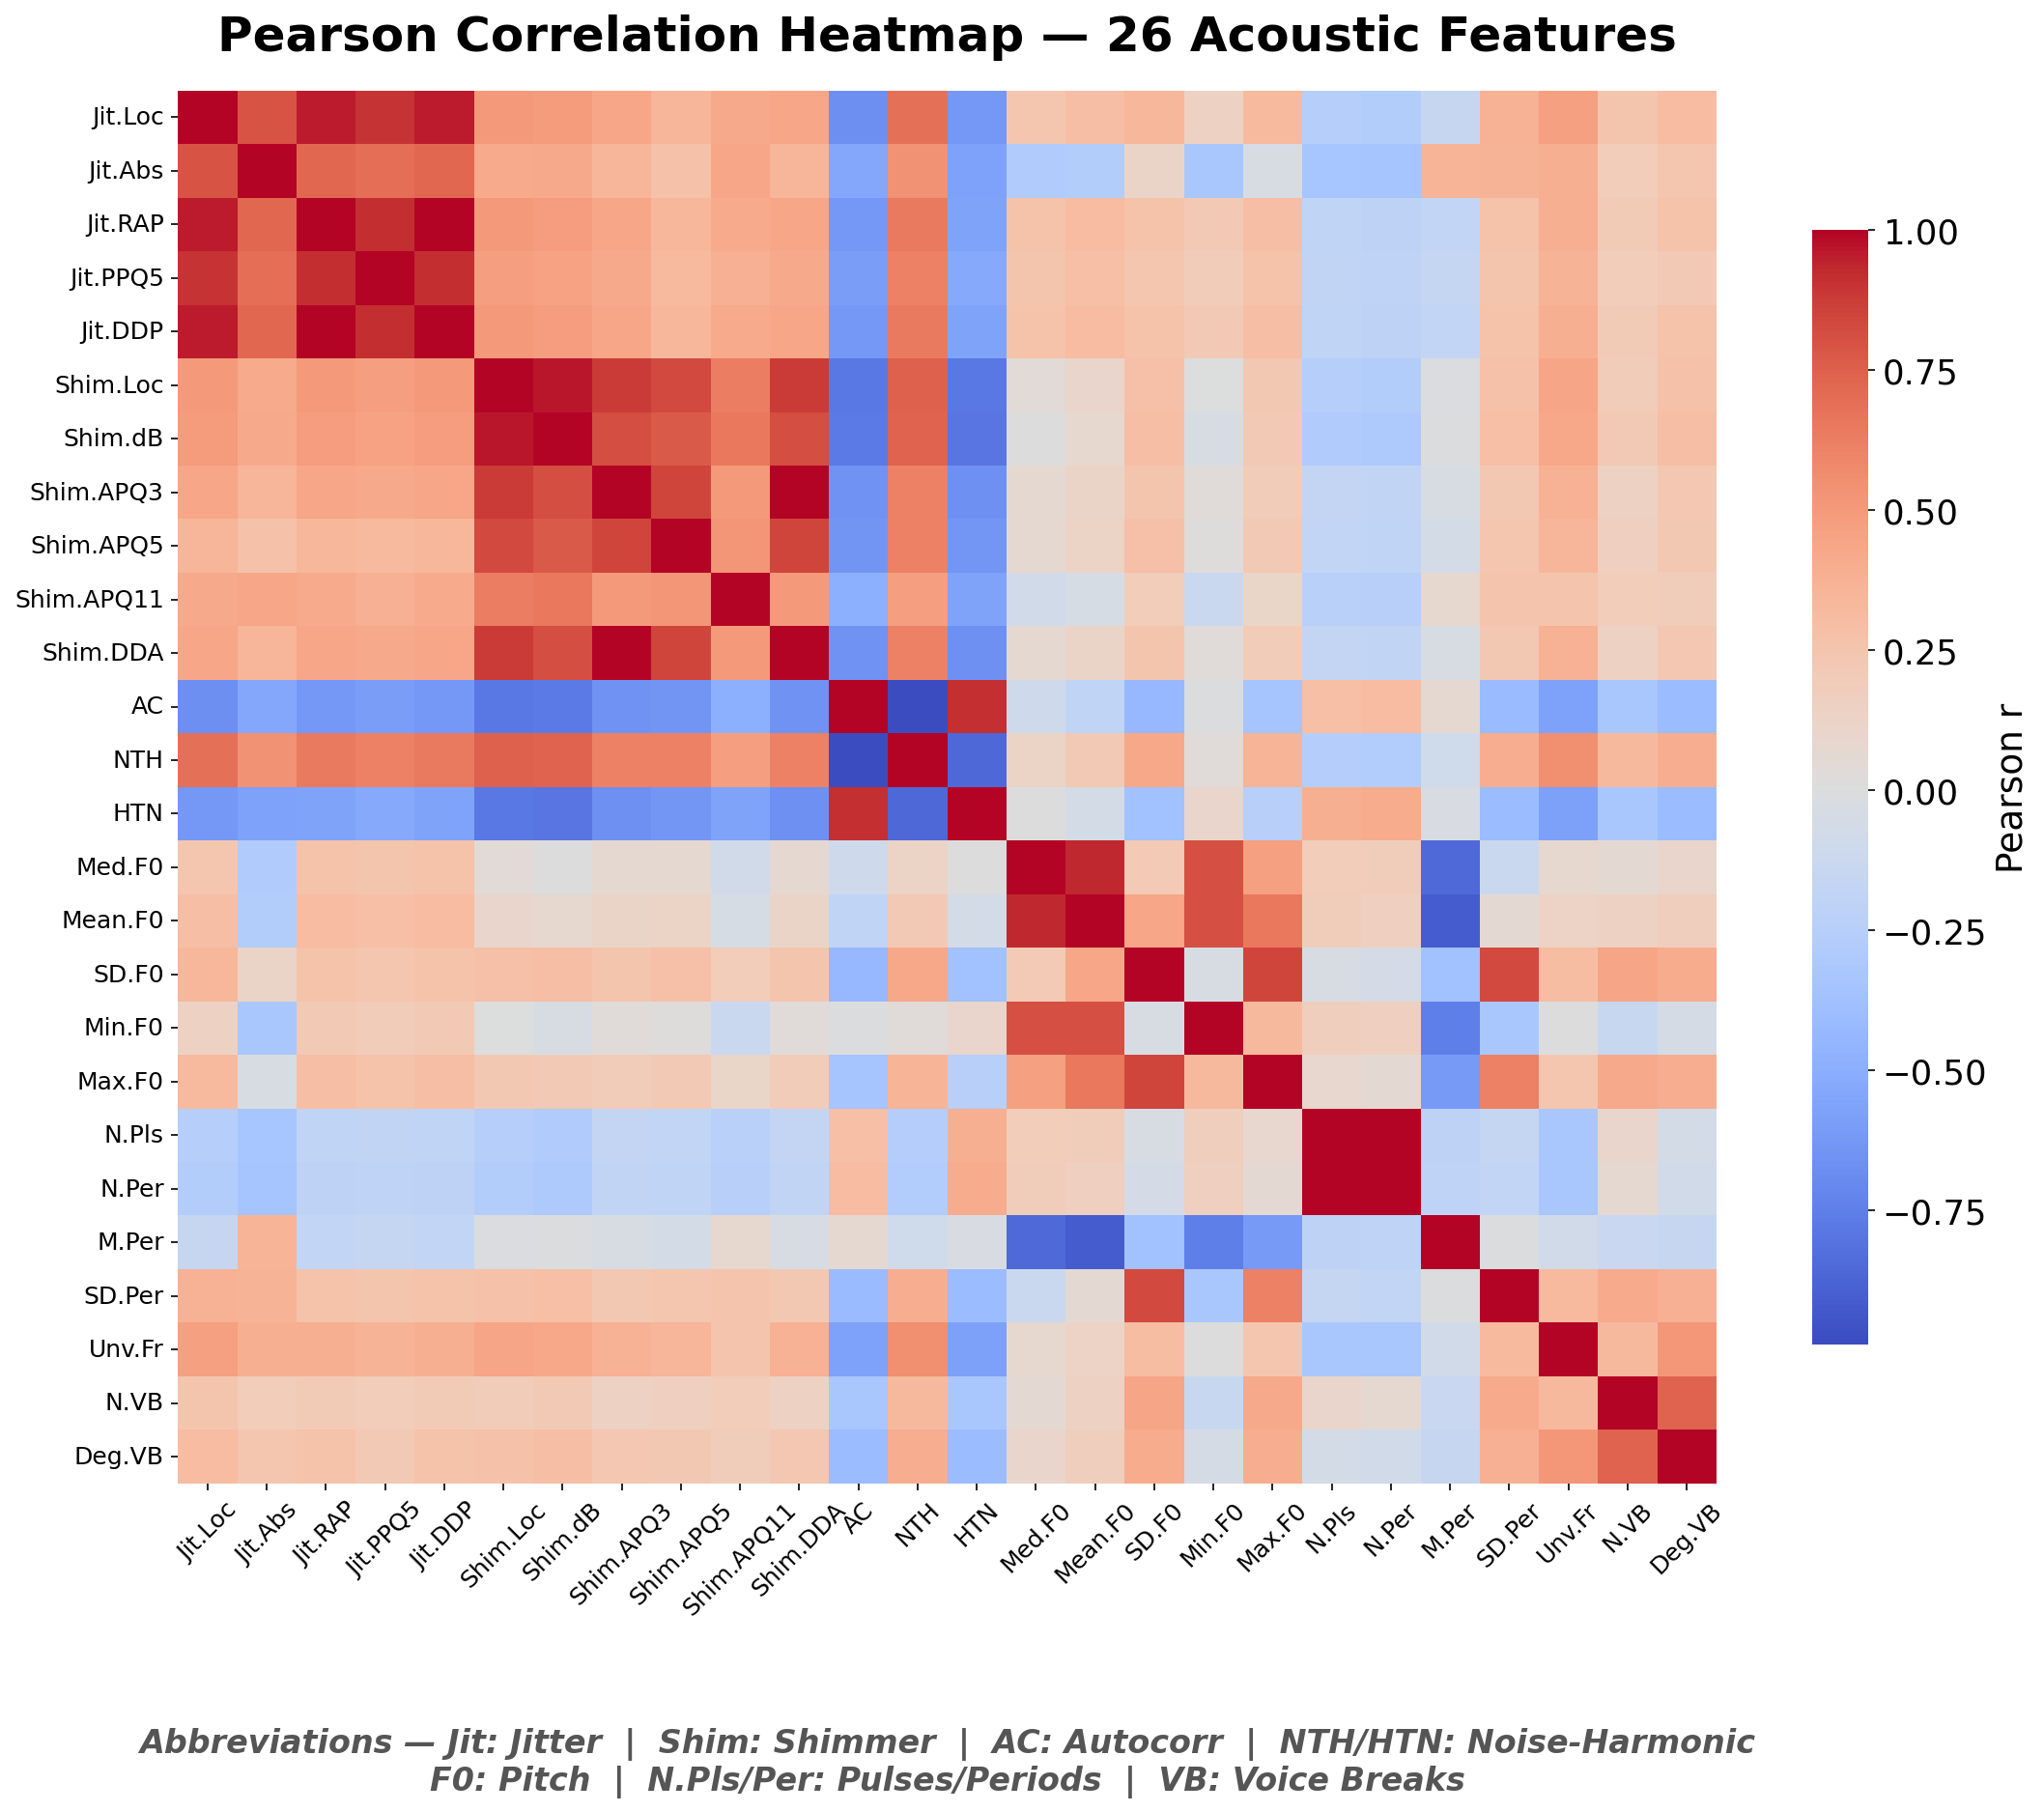

In [130]:
# --- Fig 4: Correlation Heatmap (abbreviated labels) ---
with plt.rc_context(PUB):

    # Global font scaling
    plt.rcParams.update({'font.size': 20})

    acoustic_cols = [
        c for c in df.select_dtypes(include='number').columns
        if c not in ['subject_id', 'UPDRS', 'class']
    ]

    corr = df[acoustic_cols].corr(method='pearson')

    abbrev = {
        'jitter_local':'Jit.Loc','jitter_abs':'Jit.Abs','jitter_rap':'Jit.RAP',
        'jitter_ppq5':'Jit.PPQ5','jitter_ddp':'Jit.DDP',
        'shimmer_local':'Shim.Loc','shimmer_db':'Shim.dB','shimmer_apq3':'Shim.APQ3',
        'shimmer_apq5':'Shim.APQ5','shimmer_apq11':'Shim.APQ11','shimmer_dda':'Shim.DDA',
        'AC':'AC','NTH':'NTH','HTN':'HTN',
        'median_pitch':'Med.F0','mean_pitch':'Mean.F0','sd_pitch':'SD.F0',
        'min_pitch':'Min.F0','max_pitch':'Max.F0',
        'num_pulses':'N.Pls','num_periods':'N.Per','mean_period':'M.Per','sd_period':'SD.Per',
        'unvoiced_frames':'Unv.Fr','num_voice_breaks':'N.VB','degree_voice_breaks':'Deg.VB',
    }

    labels = [abbrev.get(c, c) for c in acoustic_cols]
    corr.index = labels
    corr.columns = labels

    fig, ax = plt.subplots(figsize=(15, 13))

    sns.heatmap(
        corr,
        cmap='coolwarm',
        annot=False,
        ax=ax,
        cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
    )

    # Title
    ax.set_title(
        'Pearson Correlation Heatmap — 26 Acoustic Features',
        fontsize=24,
        fontweight='bold',
        pad=20
    )

    # Tick labels
    ax.tick_params(axis='x', labelsize=12, rotation=45)
    ax.tick_params(axis='y', labelsize=12, rotation=0)

    # Colourbar label size
    ax.collections[0].colorbar.ax.tick_params(labelsize=17)
    ax.collections[0].colorbar.set_label('Pearson r', fontsize=18)


    note = (
        'Abbreviations — Jit: Jitter  |  Shim: Shimmer  |  AC: Autocorr  |  '
        'NTH/HTN: Noise-Harmonic\n'
        'F0: Pitch  |  N.Pls/Per: Pulses/Periods  |  VB: Voice Breaks'
    )

    ax.text(
        0.5, -0.22, note,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        ha='center',
        style='italic',
        color='#555'
    )

    plt.tight_layout()

    # plt.savefig(f'{IMAGES_DIR}/fig_04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    # plt.show()

    print("Saved: fig_04_correlation_heatmap.png")


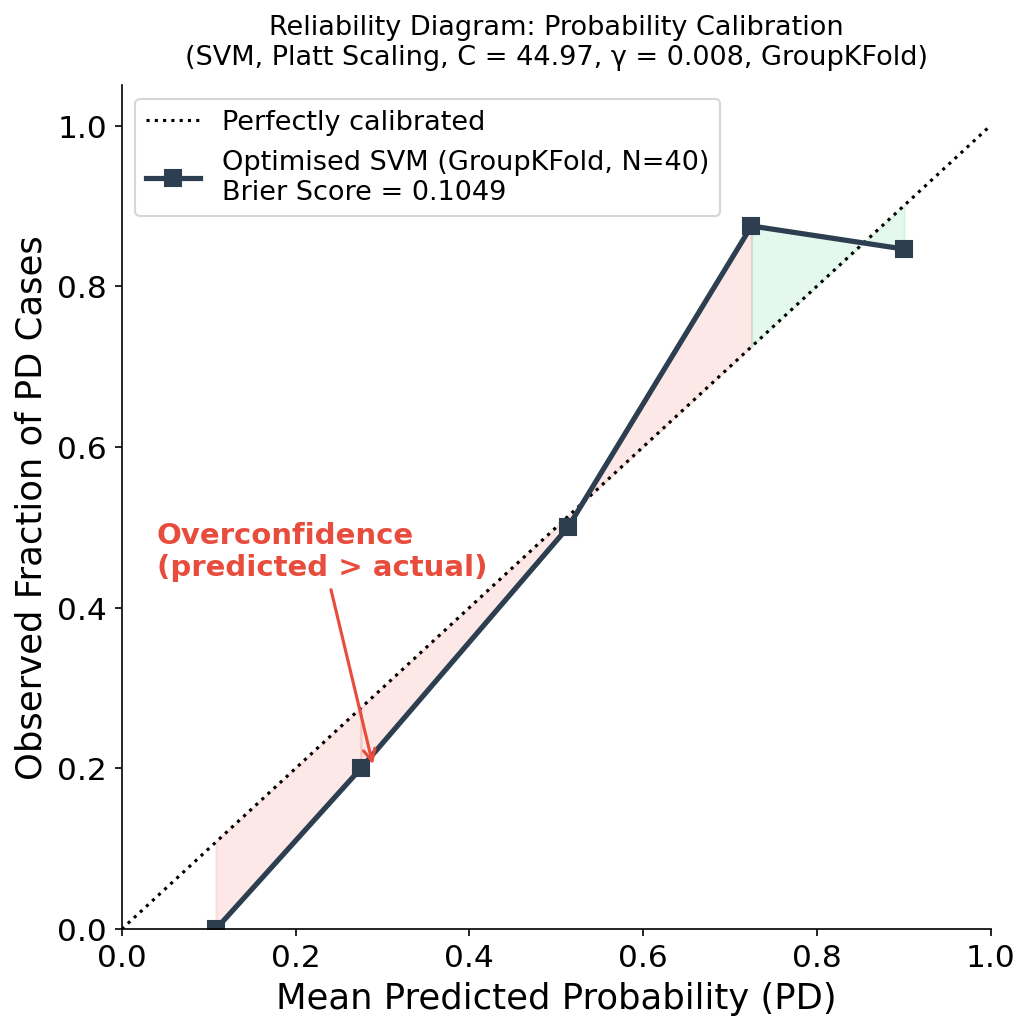

Note: n=40 subjects causes high bin variance — Brier Score 0.1049 is the stable summary.


In [131]:
# --- Fig 9 (NEW): Reliability Diagram / Calibration Curve ---
with plt.rc_context(PUB):
    probs_cal = cross_val_predict(
        safe_svm, X_filtered, y_gkf, cv=gkf, groups=groups, method='predict_proba'
    )[:, 1]
    prob_true_cal, prob_pred_cal = calibration_curve(y_gkf, probs_cal, n_bins=5)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1.5, label='Perfectly calibrated')

    # Shade overconfidence / underconfidence regions
    for i in range(len(prob_pred_cal) - 1):
        x0, x1 = prob_pred_cal[i], prob_pred_cal[i+1]
        y0_t, y1_t = prob_true_cal[i], prob_true_cal[i+1]
        col = '#e74c3c' if x0 > y0_t else '#2ecc71'
        ax.fill_between([x0, x1], [x0, x1], [y0_t, y1_t], alpha=0.12, color=col)

    ax.plot(prob_pred_cal, prob_true_cal, 's-', color='#2c3e50', linewidth=2.5,
            markersize=8,
            label='Optimised SVM (GroupKFold, N=40)\nBrier Score = 0.1049')

    # Arrow annotation
    ax.annotate(
        'Overconfidence\n(predicted > actual)',
        xy=(0.29, 0.2),
        xytext=(0.04, 0.44),
        fontsize=14, color='#e74c3c', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5)
    )

    ax.set_xlabel('Mean Predicted Probability (PD)', fontsize=17)
    ax.set_ylabel('Observed Fraction of PD Cases', fontsize=17)

    # Bigger ticks on both axes
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

    ax.set_title(
        'Reliability Diagram: Probability Calibration\n'
        '(SVM, Platt Scaling, C = 44.97, γ = 0.008, GroupKFold)',
        fontsize=13, pad=10
    )

    ax.legend(fontsize=13, loc='upper left')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f'{IMAGES_DIR}/fig_09_calibration_reliability.png', dpi=300, bbox_inches='tight')
    plt.show()

    # print("Saved: fig_09_calibration_reliability.png")
    print("Note: n=40 subjects causes high bin variance — Brier Score 0.1049 is the stable summary.")


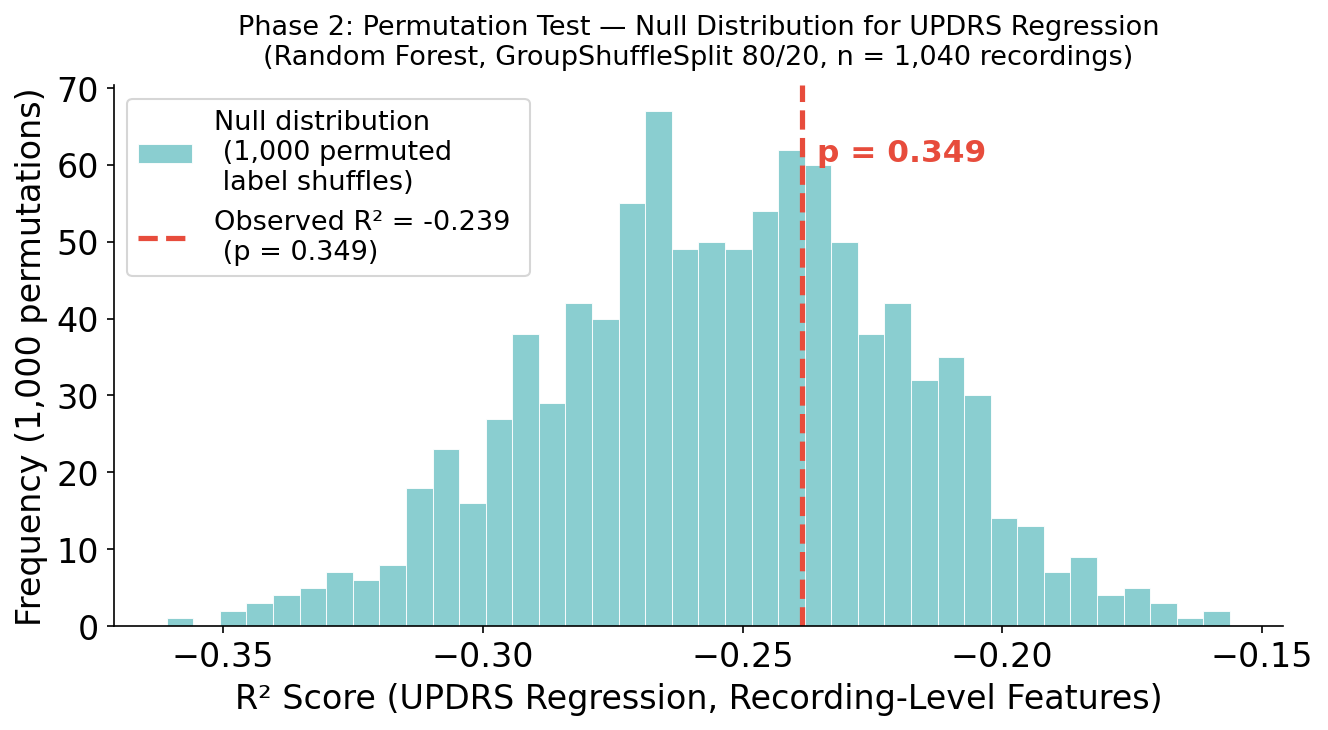

In [132]:
# --- Fig: Permutation Test (Phase 2) ---
# Requires: permuted_r2_scores, observed_r2, p_value  (from cell 185 with seed 201)
with plt.rc_context(PUB):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(permuted_r2_scores, bins=40, color='#76c6c8', edgecolor='white',
            linewidth=0.5, alpha=0.85,
            label='Null distribution \n (1,000 permuted \n label shuffles)')

    ymax = ax.get_ylim()[1]

    ax.axvline(observed_r2, color='#e74c3c', linestyle='--', linewidth=2.5,
               label=f'Observed R\u00b2 = {observed_r2:.3f} \n (p = {p_value:.3f})')

    ax.text(observed_r2 + 0.003, ymax * 0.86,
            f'p = {p_value:.3f}', fontsize=15, fontweight='bold', color='#e74c3c')

    ax.set_xlabel('R\u00b2 Score (UPDRS Regression, Recording-Level Features)', fontsize=16)
    ax.set_ylabel('Frequency (1,000 permutations)', fontsize=16)

    # Make x and y ticks bigger
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_title(
        'Phase 2: Permutation Test — Null Distribution for UPDRS Regression\n'
        '(Random Forest, GroupShuffleSplit 80/20, n = 1,040 recordings)',
        fontsize=13, pad=10
    )

    ax.legend(fontsize=13, loc='upper left')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f'{IMAGES_DIR}/fig_permutation_test.png', dpi=300, bbox_inches='tight')
    plt.show()

    # print(f"Saved: fig_permutation_test.png  |  R\u00b2 = {observed_r2:.3f}, p = {p_value:.3f}")


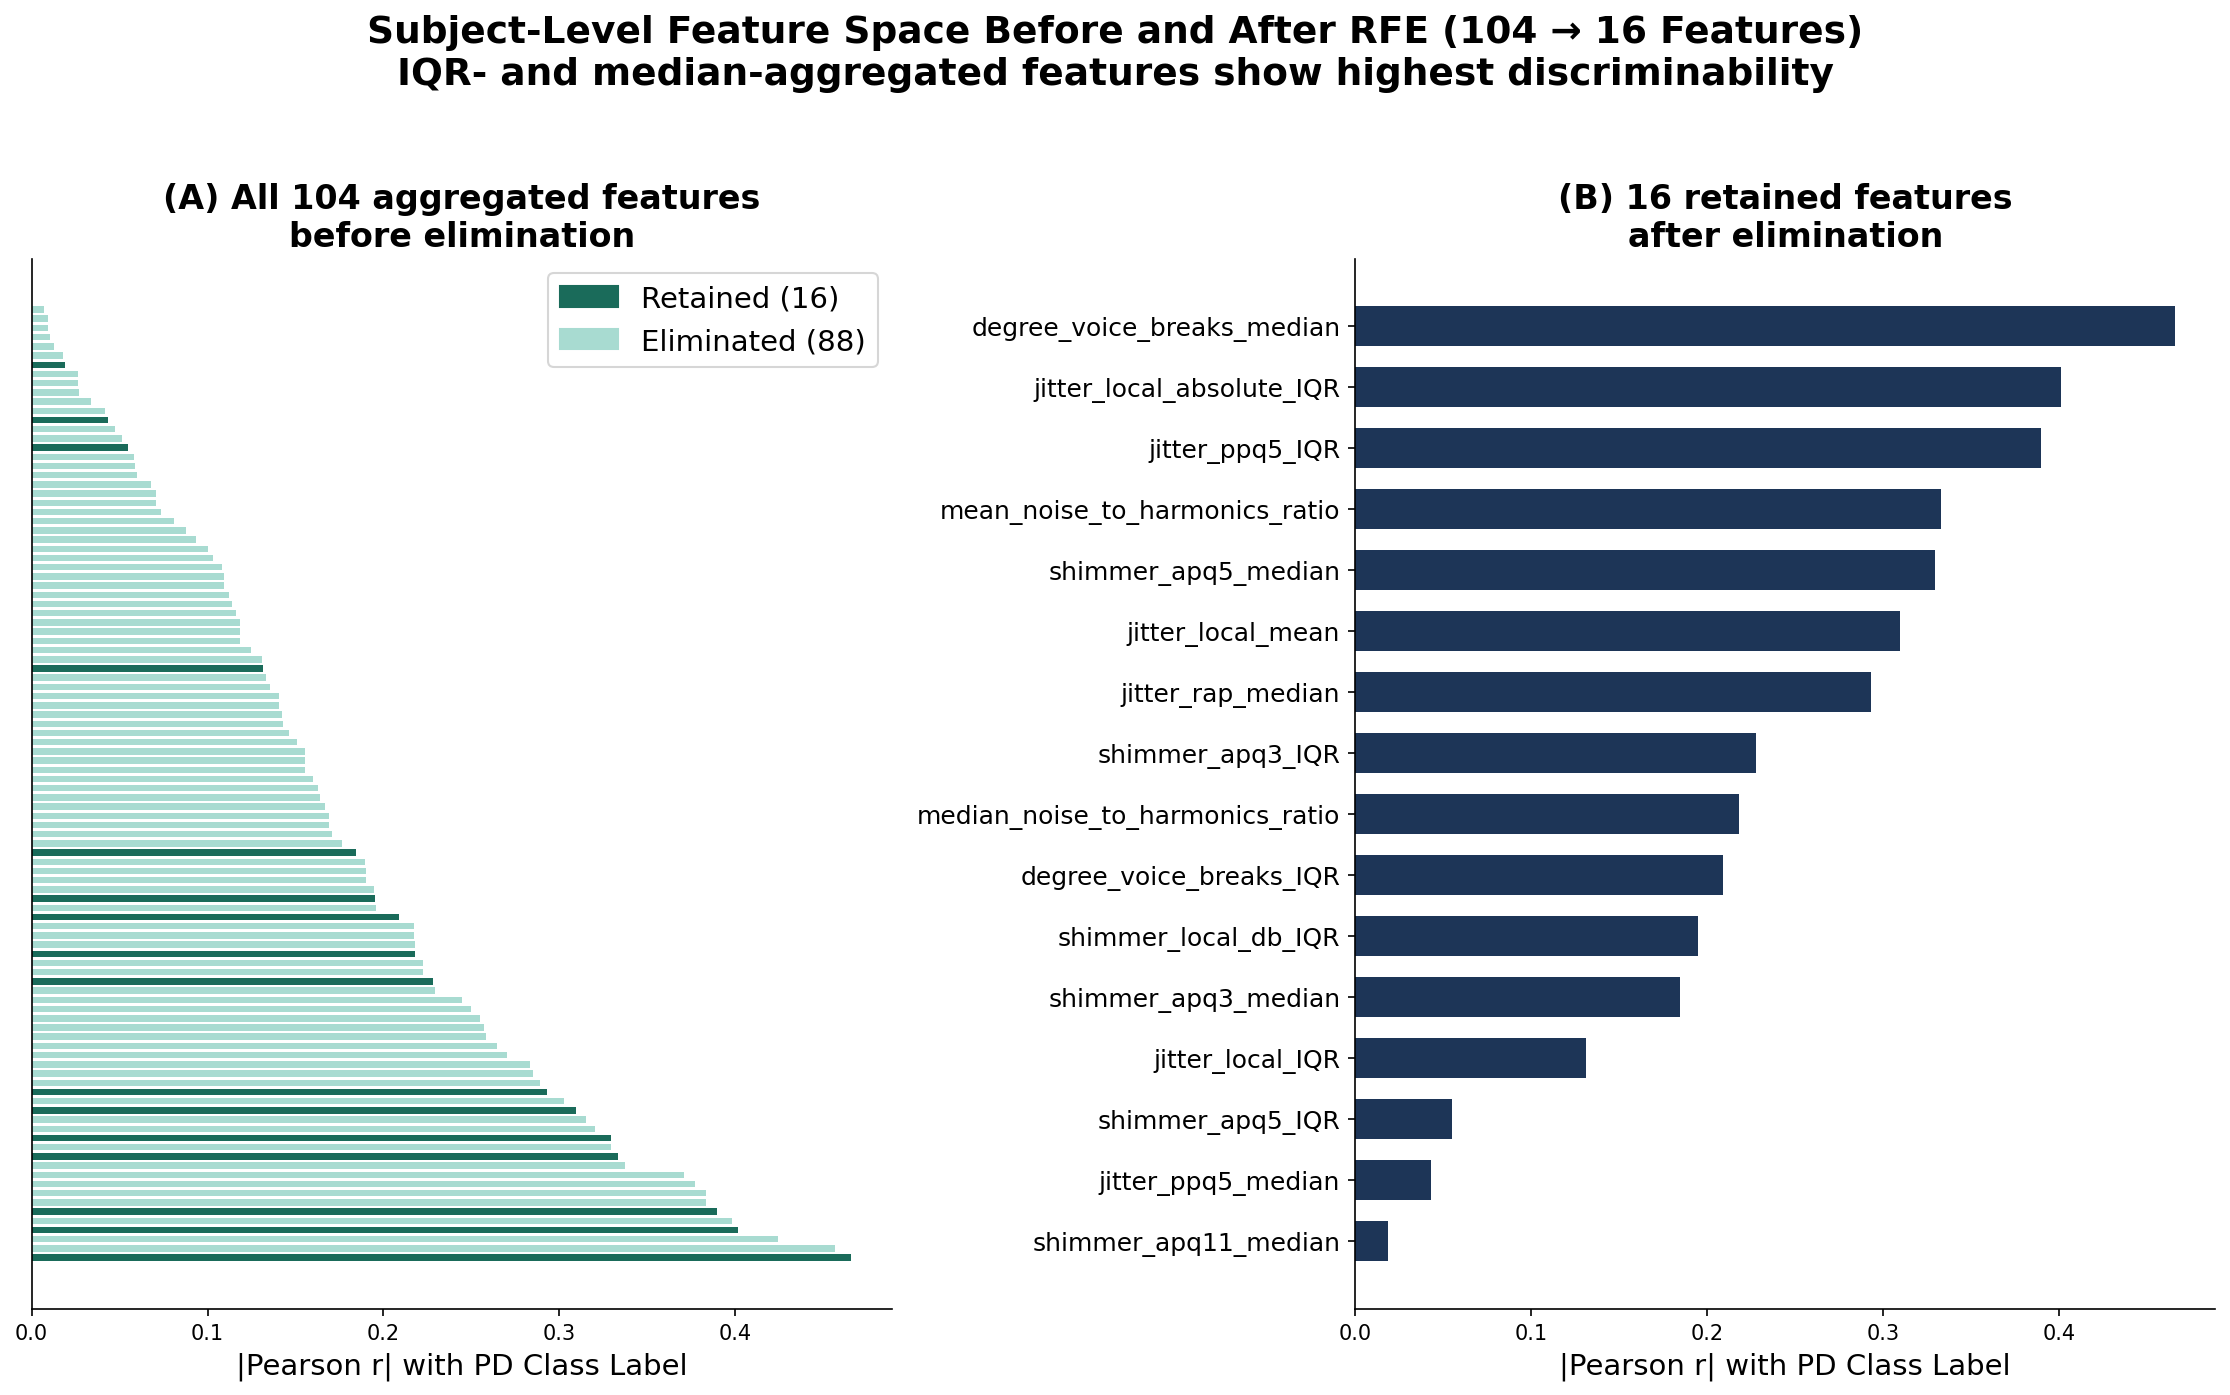

In [133]:
# --- Fig: Feature Elimination (104 -> 16 retained features) ---
with plt.rc_context(PUB):
    feat_names = list(X_gkf.columns)
    y_bin = y_gkf.values
    corrs_all = np.array([
        abs(np.corrcoef(X_gkf[col].values, y_bin)[0, 1]) for col in feat_names
    ])
    sel_mask = selector.support_

    # Map RFE x-indices to discriminability scores
    x_names_rfe  = selector.get_feature_names_out()
    rfe_indices  = [int(n[1:]) for n in x_names_rfe]
    corrs_sel    = corrs_all[rfe_indices]

    # Sort selected features for Panel B
    order_b  = np.argsort(corrs_sel)
    names_b  = [clinical_names[i] for i in order_b]
    scores_b = corrs_sel[order_b]

    # Sort ALL features for Panel A
    order_a   = np.argsort(corrs_all)[::-1]
    is_sel_a  = sel_mask[order_a]
    scores_a  = corrs_all[order_a]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9))

    # Panel A
    colors_a = ['#1a6b5a' if s else '#a8dbd1' for s in is_sel_a]
    ax1.barh(range(len(scores_a)), scores_a, color=colors_a, height=0.7)
    ax1.set_yticks([])
    ax1.set_xlabel('|Pearson r| with PD Class Label', fontsize=14)
    ax1.set_title(
        f'(A) All {len(scores_a)} aggregated features\nbefore elimination',
        fontsize=16, fontweight='bold'
    )

    # Legend moved UP and RIGHT
    p_ret  = mpatches.Patch(color='#1a6b5a', label=f'Retained ({sel_mask.sum()})')
    p_elim = mpatches.Patch(color='#a8dbd1', label=f'Eliminated ({(~sel_mask).sum()})')

    ax1.legend(
        handles=[p_ret, p_elim],
        fontsize=14,
        loc='upper right',
        bbox_to_anchor=(1.0, 1.0),   # move legend upward
        frameon=True
    )

    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Panel B
    ax2.barh(range(len(scores_b)), scores_b, color='#1D3557', height=0.65)
    ax2.set_yticks(range(len(names_b)))
    ax2.set_yticklabels(names_b, fontsize=12)
    ax2.set_xlabel('|Pearson r| with PD Class Label', fontsize=14)
    ax2.set_title(
        f'(B) {len(names_b)} retained features\nafter elimination',
        fontsize=16, fontweight='bold'
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Main title
    fig.suptitle(
        'Subject-Level Feature Space Before and After RFE (104 → 16 Features)\n'
        'IQR- and median-aggregated features show highest discriminability',
        fontsize=18, fontweight='bold', y=1.03
    )

    plt.tight_layout()
    # plt.savefig(f'{IMAGES_DIR}/fig_feature_elimination.png', dpi=300, bbox_inches='tight')
    plt.show()

    # print(f"Saved: fig_feature_elimination.png  |  {sel_mask.sum()} features retained")


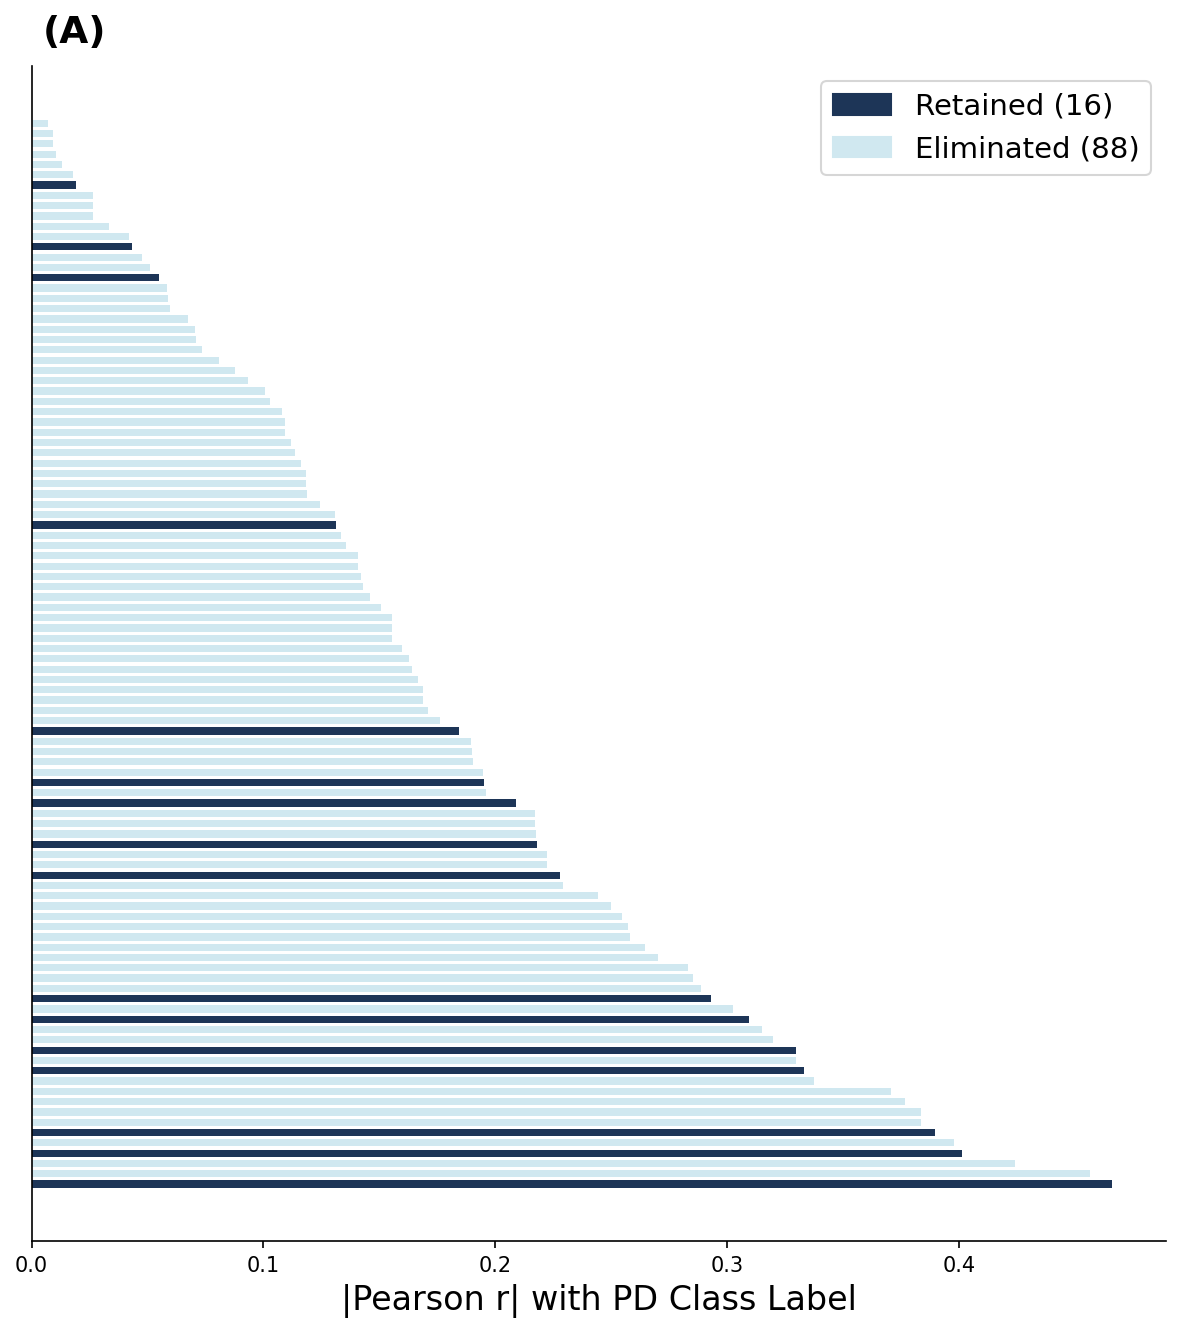

In [134]:
with plt.rc_context(PUB):
    feat_names = list(X_gkf.columns)
    y_bin = y_gkf.values

    corrs_all = np.array([
        abs(np.corrcoef(X_gkf[col].values, y_bin)[0, 1]) for col in feat_names
    ])

    sel_mask = selector.support_

    order_a  = np.argsort(corrs_all)[::-1]
    is_sel_a = sel_mask[order_a]
    scores_a = corrs_all[order_a]

    fig, ax1 = plt.subplots(figsize=(8, 9))

    colors_a = ['#1D3557' if s else '#d0e8f0' for s in is_sel_a]
    ax1.barh(range(len(scores_a)), scores_a, color=colors_a, height=0.7)

    ax1.set_yticks([])
    ax1.set_xlabel('|Pearson r| with PD Class Label', fontsize=16)

    ax1.text(0.01, 1.02, '(A)', transform=ax1.transAxes,
             fontsize=18, fontweight='bold')

    p_ret  = mpatches.Patch(color='#1D3557', label=f'Retained ({sel_mask.sum()})')
    p_elim = mpatches.Patch(color='#d0e8f0', label=f'Eliminated ({(~sel_mask).sum()})')
    ax1.legend(handles=[p_ret, p_elim], fontsize=14,
               loc='upper right', frameon=True)

    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f'{IMAGES_DIR}/fig_feature_elimination_A.png', dpi=300,
    #            bbox_inches='tight')
    plt.show()


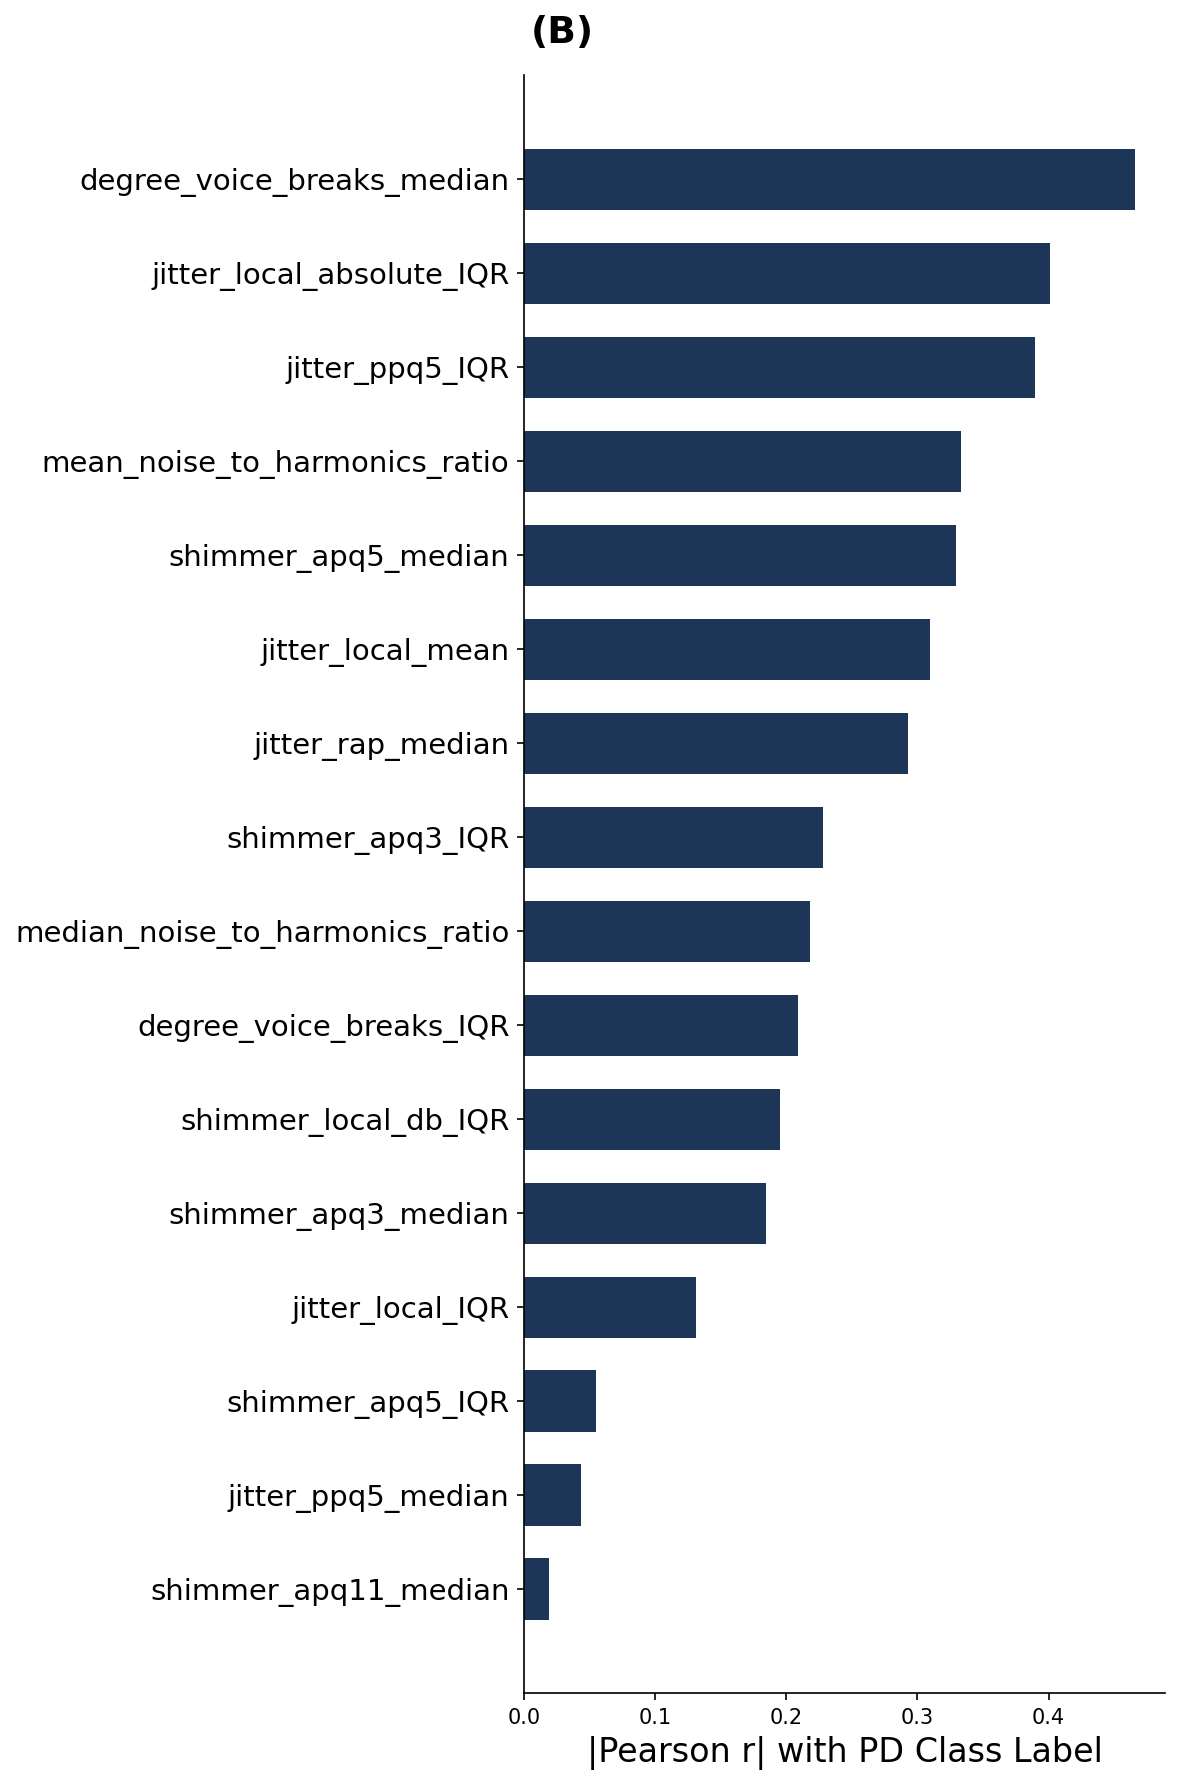

In [ ]:
with plt.rc_context(PUB):
    feat_names = list(X_gkf.columns)
    y_bin = y_gkf.values

    corrs_all = np.array([
        abs(np.corrcoef(X_gkf[col].values, y_bin)[0, 1]) for col in feat_names
    ])

    sel_mask = selector.support_

    x_names_rfe = selector.get_feature_names_out()
    rfe_indices = [int(n[1:]) for n in x_names_rfe]
    corrs_sel   = corrs_all[rfe_indices]

    order_b  = np.argsort(corrs_sel)
    names_b  = [clinical_names[i] for i in order_b]
    scores_b = corrs_sel[order_b]

    fig, ax2 = plt.subplots(figsize=(8, 12))

    ax2.barh(range(len(scores_b)), scores_b, color='#1D3557', height=0.65)

    ax2.set_yticks(range(len(names_b)))
    ax2.set_yticklabels(names_b, fontsize=14)
    ax2.set_xlabel('|Pearson r| with PD Class Label', fontsize=16)

    ax2.text(0.01, 1.02, '(B)', transform=ax2.transAxes,
             fontsize=18, fontweight='bold')

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # --- NEW: Move Figure B left to align with Figure A ---
    plt.subplots_adjust(left=0.05)

    plt.tight_layout()
    # plt.savefig(f'{IMAGES_DIR}/fig_feature_elimination_B.png', dpi=300,
    #           bbox_inches='tight')
    plt.show()


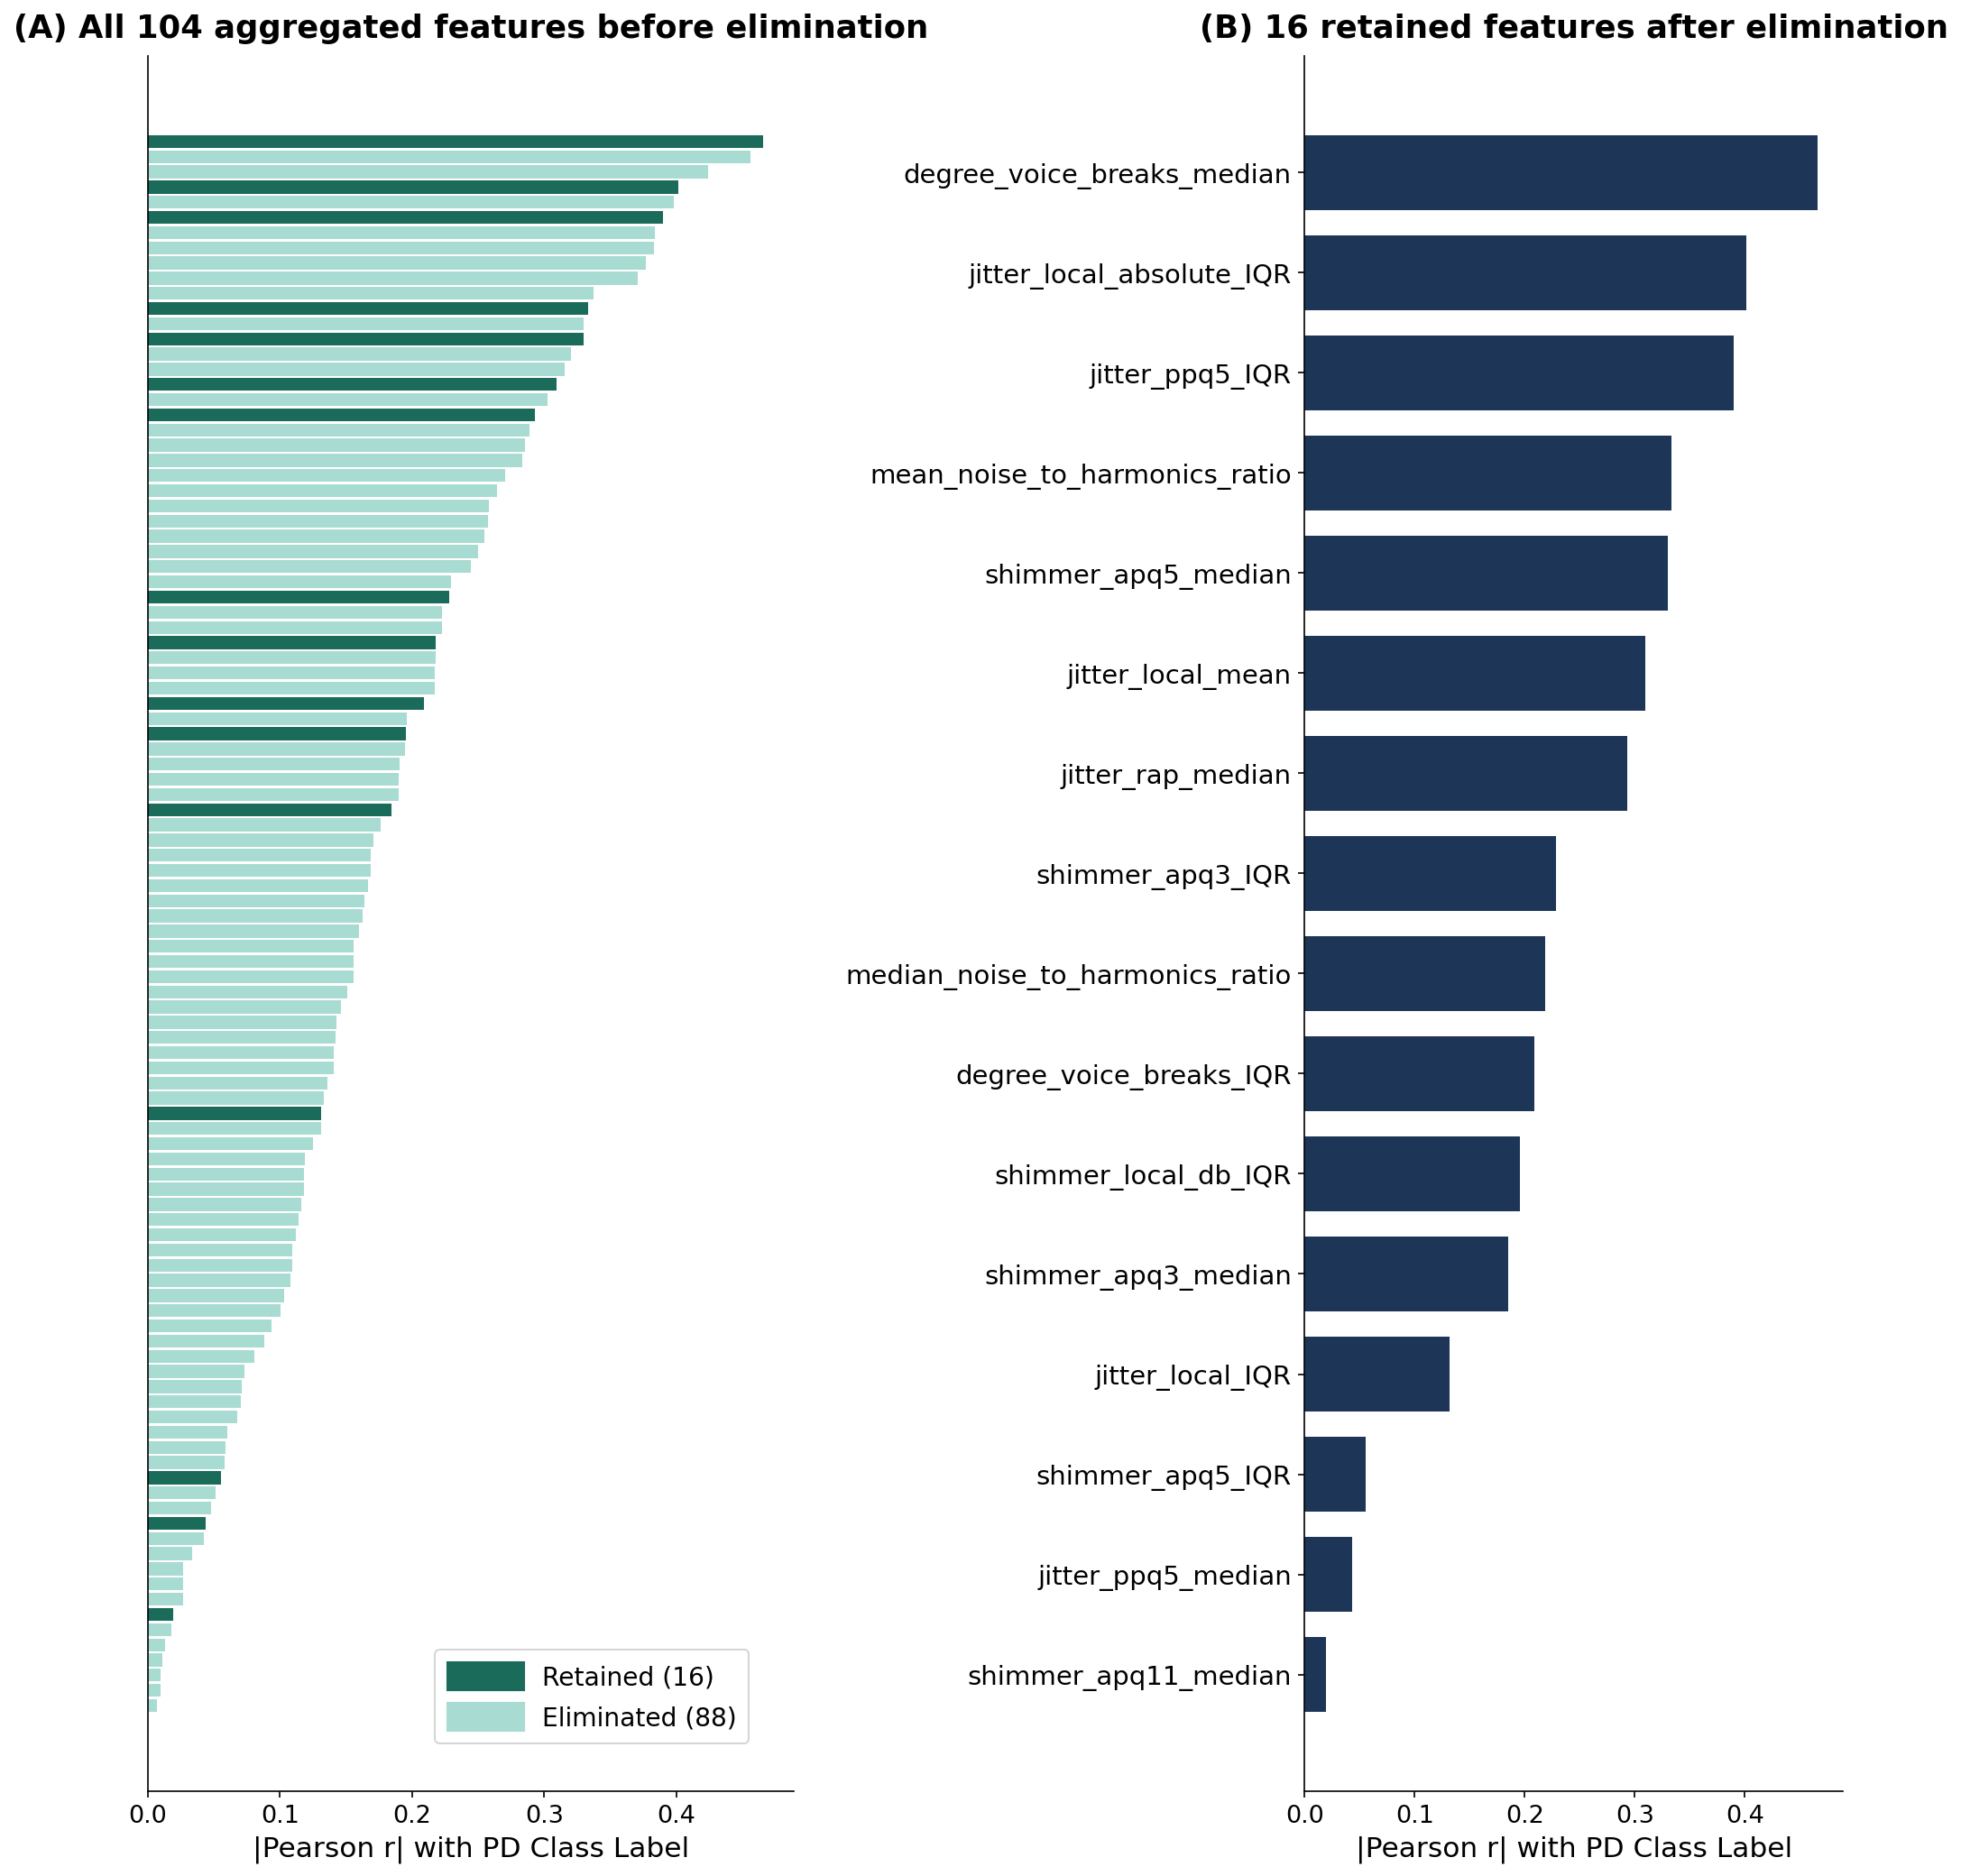

In [136]:
# --- Fig: Feature Elimination (104 → 16 retained features) ---
with plt.rc_context(PUB):
    feat_names = list(X_gkf.columns)
    y_bin = y_gkf.values
    corrs_all = np.array([
        abs(np.corrcoef(X_gkf[col].values, y_bin)[0, 1]) for col in feat_names
    ])
    sel_mask = selector.support_

    # Map RFE x-indices to discriminability scores
    x_names_rfe = selector.get_feature_names_out()
    rfe_indices = [int(n[1:]) for n in x_names_rfe]
    corrs_sel = corrs_all[rfe_indices]

    # Sort selected features (Panel B)
    order_b = np.argsort(corrs_sel)
    names_b = [clinical_names[i] for i in order_b]
    scores_b = corrs_sel[order_b]

    # Sort all features (Panel A)
    order_a = np.argsort(corrs_all)
    is_sel_a = sel_mask[order_a]
    scores_a = corrs_all[order_a]

    # Wider panels + long aspect ratio
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(13, 14),
        gridspec_kw={'width_ratios': [1.2, 1]}
    )

    # ─────────────────────────────────────────────
    # LEFT PANEL — All 104 features
    # ─────────────────────────────────────────────
    colors_a = ['#1a6b5a' if s else '#a8dbd1' for s in is_sel_a]
    ax_left.barh(range(len(scores_a)), scores_a, color=colors_a, height=0.85)
    ax_left.set_yticks([])
    ax_left.set_xlabel('|Pearson r| with PD Class Label', fontsize=15)
    ax_left.tick_params(axis='x', labelsize=13)
    ax_left.set_title(
        f'(A) All {len(scores_a)} aggregated features before elimination',
        fontsize=17, fontweight='bold', pad=10
    )

    # Legend — slightly left + slightly down
    p_ret = mpatches.Patch(color='#1a6b5a', label=f'Retained ({sel_mask.sum()})')
    p_elim = mpatches.Patch(color='#a8dbd1', label=f'Eliminated ({(~sel_mask).sum()})')

    ax_left.legend(
        handles=[p_ret, p_elim],
        fontsize=13.5,
        handlelength=3.0,
        handleheight=1.3,
        borderpad=0.5,
        handletextpad=0.7,
        loc='lower right',
        bbox_to_anchor=(0.95, 0.02),   # ← moved left + ↓ moved down
        frameon=True
    )

    ax_left.spines['top'].set_visible(False)
    ax_left.spines['right'].set_visible(False)

    # ─────────────────────────────────────────────
    # RIGHT PANEL — 16 retained features
    # ─────────────────────────────────────────────
    ax_right.barh(range(len(scores_b)), scores_b, color='#1D3557', height=0.75)
    ax_right.set_yticks(range(len(names_b)))
    ax_right.set_yticklabels(names_b, fontsize=14)
    ax_right.set_xlabel('|Pearson r| with PD Class Label', fontsize=15)
    ax_right.tick_params(axis='x', labelsize=13)
    ax_right.set_title(
        '(B) 16 retained features after elimination',
        fontsize=17, fontweight='bold', pad=10
    )

    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)

    plt.tight_layout(w_pad=2.5)
   # plt.savefig(f'{IMAGES_DIR}/fig_feature_elimination_side_long.png',
   #             dpi=300, bbox_inches='tight')
    plt.show()

  #  print(f"Saved: fig_feature_elimination_side_long.png  |  {sel_mask.sum()} features retained")


In [137]:
# --- CV AUC-ROC (cross-validated, for Table 1) ---
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict

probs_cv = cross_val_predict(
    safe_svm, X_filtered, y_gkf, cv=gkf, groups=groups, method='predict_proba'
)[:, 1]

cv_auc = roc_auc_score(y_gkf, probs_cv)
print(f"--- CV AUC-ROC (GroupKFold, N=40) ---")
print(f"CV AUC-ROC: {cv_auc:.4f}")
print(f"This is the value for Table 1 in the manuscript.")


--- CV AUC-ROC (GroupKFold, N=40) ---
CV AUC-ROC: 0.9200
This is the value for Table 1 in the manuscript.
